# Predicting Final State with Long Short‐Term Memory Neural Networks


Other papers: 

- Compares performance of traditional time series model to Neural Networks:
     Lou, H.-R., Wang, X., Gao, Y., & Zeng, Q. (2022). Comparison of ARIMA model, DNN model and LSTM model in predicting disease burden of occupational pneumoconiosis in Tianjin, China. BMC Public Health, 22(1), Article 2167. https://doi.org/10.1186/s12889-022-14642-3

- Predicting Parkisons Diagnosis: dd

  Tekindor, A. N., & Akman Aydın, E. (2025). Speech signals-based Parkinson’s disease diagnosis using hybrid autoencoder-LSTM models. Computers in Biology and Medicine, 193, Article 110334. https://doi.org/10.1016/j.compbiomed.2025.110334


In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import cross_val_predict
import random

## On Labor Force Exit

In [57]:

# Load the data
data = pd.read_csv('sledata_processed.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_94097/3471207257.py:2: DtypeWarning: Columns (125,127,134,136,143,145,150,180) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledata_processed.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_94097/3471207257.py:3: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Train Test Split

In [17]:
random.seed(365)
# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
random.seed(365)
# Corrected model training section
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model with corrected class_weight
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # Use the computed weights
)

# Rest of your code remains the same...

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.1723 - loss: 1.7899 - val_accuracy: 0.1333 - val_loss: 1.8252
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.2467 - loss: 1.8060 - val_accuracy: 0.6278 - val_loss: 1.6870
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.6493 - loss: 1.4635 - val_accuracy: 0.6833 - val_loss: 1.5710
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.6592 - loss: 1.3657 - val_accuracy: 0.7333 - val_loss: 1.4237
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.6448 - loss: 1.4105 - val_accuracy: 0.5333 - val_loss: 1.5167
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.4547 - loss: 1.2402 - val_accuracy: 0.4222 - val_loss: 1.5815
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4259 - loss: 1.4043 - val_accuracy: 0.6167 - val_loss: 1.2814
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.5866 - loss: 1.1229 - val_accuracy: 0

## Cross Validation

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
import random

random.seed(365)
np.random.seed(365)

# Create sequences for each patient (your existing function)
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        X[i, :seq_len, :] = patient_data[features].values
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, y, seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert to categorical (if not already done)
y_categorical = to_categorical(y)

# Initialize Stratified K-Fold cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=365)

# Store results
results = []
fold_no = 1

for train_idx, test_idx in skf.split(X, y):
    print(f'\nTraining fold {fold_no}...')
    
    # Get train/test splits maintaining sequence structure
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_categorical[train_idx], y_categorical[test_idx]
    
    # Calculate class weights for this fold
    y_integers = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y_integers)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Build LSTM model
    num_classes = y_categorical.shape[1]
    model = Sequential([
        Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    
    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=50,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Evaluate the model
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    
    # Store results
    results.append({
        'fold': fold_no,
        'accuracy': test_acc,
        'loss': test_loss,
        'report': classification_report(
            y_true_classes, 
            y_pred_classes, 
            target_names=label_encoder.classes_,
            output_dict=True
        ),
        'confusion_matrix': confusion_matrix(y_true_classes, y_pred_classes)
    })
    
    fold_no += 1

# Print cross-validation results
print("\n\n=== Cross-Validation Results ===")
for res in results:
    print(f"\nFold {res['fold']}:")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(f"Loss: {res['loss']:.4f}")
    print("Classification Report:")
    print(classification_report(
        y_true_classes, 
        y_pred_classes, 
        target_names=label_encoder.classes_
    ))

# Calculate average metrics
avg_accuracy = np.mean([res['accuracy'] for res in results])
print(f"\nAverage Accuracy across folds: {avg_accuracy:.4f}")


Training fold 1...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - accuracy: 0.2814 - loss: 1.6685 - val_accuracy: 0.4341 - val_loss: 1.7711
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.3753 - loss: 1.7455 - val_accuracy: 0.4683 - val_loss: 1.7428
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.5048 - loss: 1.6830 - val_accuracy: 0.7317 - val_loss: 1.4730
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.6475 - loss: 1.5606 - val_accuracy: 0.7073 - val_loss: 1.4575
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.7412 - loss: 1.3812 - val_accuracy: 0.6390 - val_loss: 1.5686
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step - accuracy: 0.6282 - loss: 1.3229 - val_accuracy: 0.7024 - val_loss: 1.4178
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.5708 - loss: 1.5743 - val_accuracy: 0.6146 - val_loss: 1.3466
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.5627 - loss: 1.2953 - val_accuracy: 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 282ms/step - accuracy: 0.0706 - loss: 1.8891 - val_accuracy: 0.3366 - val_loss: 1.7780
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.3141 - loss: 1.6352 - val_accuracy: 0.5854 - val_loss: 1.7517
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.5026 - loss: 1.7768 - val_accuracy: 0.6293 - val_loss: 1.7908
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.5415 - loss: 1.8173 - val_accuracy: 0.4732 - val_loss: 1.6852
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.4107 - loss: 1.5257 - val_accuracy: 0.4976 - val_loss: 1.6246
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.4575 - loss: 1.4605 - val_accuracy: 0.5463 - val_loss: 1.5396
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.3854 - loss: 1.4659 - val_accuracy: 0.4780 - val_loss: 1.5272
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3487 - loss: 1.4851

=== Actionable Clinical Insights ===
Early Warning: Model flagged 57 patients at high risk
Median lead time: 91.0 months before exit

Common Warning Signs:
- 0% had SLEDAI ≥4
- 0% on ≥7.5mg prednisone
- 100% showed work status decline


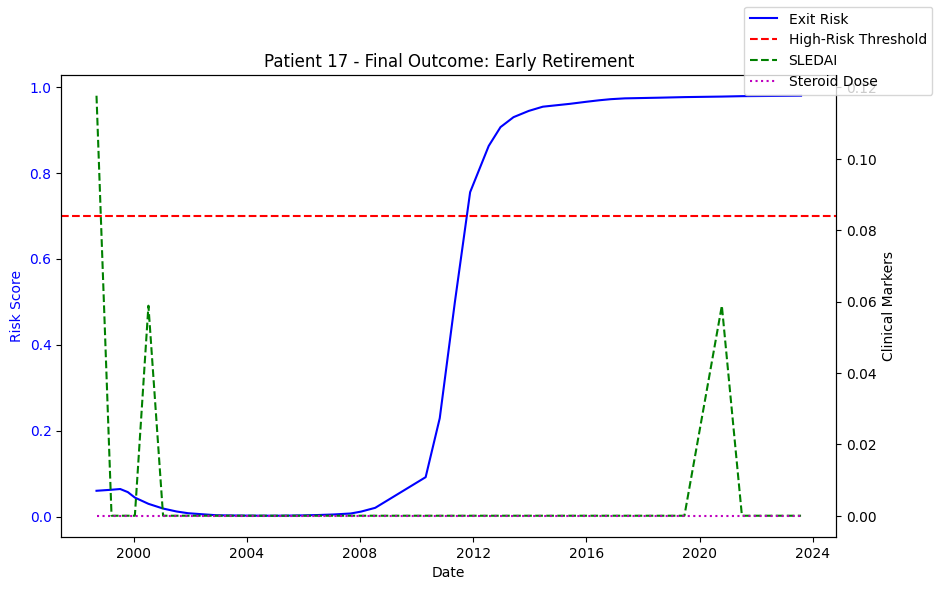

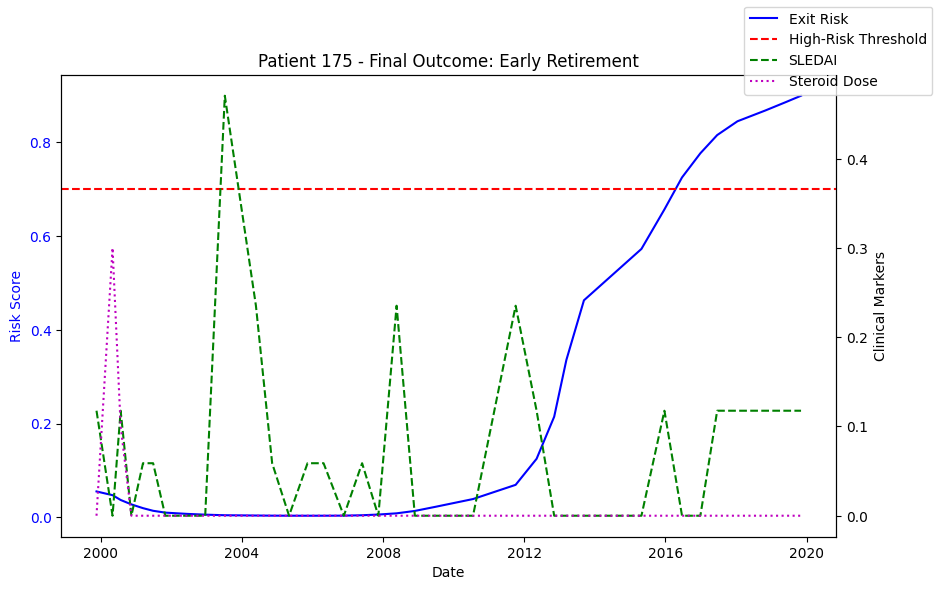

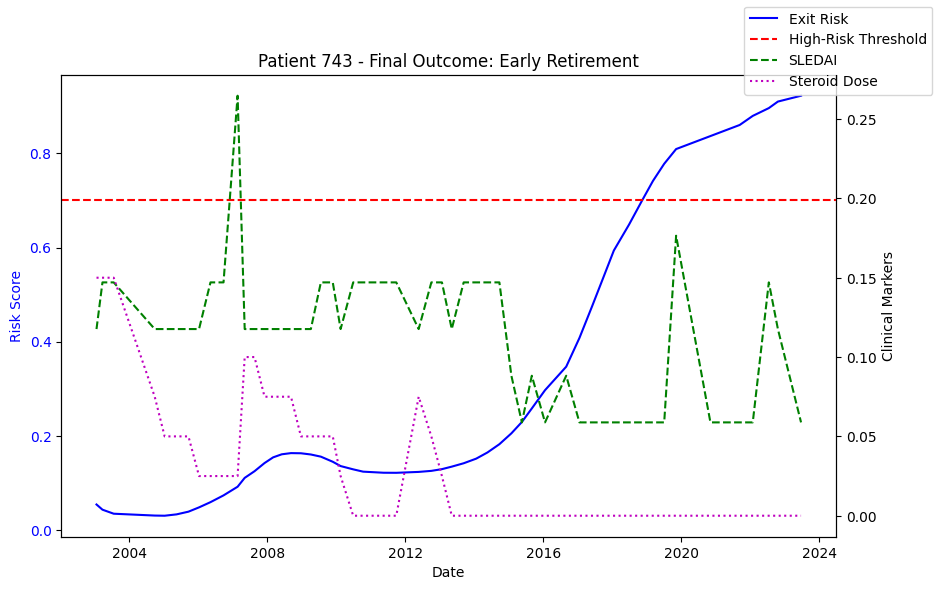

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Generate Time-to-Event Predictions (Risk Scores)
# -------------------------------------------------
def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Generate dynamic risk predictions for a patient across visits"""
    X_patient = np.zeros((1, max_seq_length, len(features)))
    seq_len = len(patient_data)
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    # Get cumulative predictions at each time point
    risks = []
    for t in range(1, seq_len + 1):
        pred = model.predict(X_patient[:, :t, :], verbose=0)
        exit_risk = pred[0][1]  # Assuming class 1 is labor force exit
        risks.append(exit_risk)
    
    return pd.DataFrame({
        'ASSDT': patient_data['ASSDT'].values,
        'Risk_Score': risks,
        'SLEDAI': patient_data['SLEDAI2_I'].values,
        'Steroid_Dose': patient_data['STERDOSE'].values,
        'Employment_Status': patient_data['EMPf'].values
    })

# 2. Identify High-Risk Patients with Actionable Thresholds
# --------------------------------------------------------
def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

# 3. Generate Actionable Insights Report
# -------------------------------------
def generate_clinical_report(high_risk_df):
    """Create a clinician-friendly summary of warning signs"""
    report = {
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_at_Warning'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_at_Warning'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed')])/len(high_risk_df):.0%} showed work status decline"
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy for each outcome type
    for outcome in high_risk_df['Final_Outcome'].unique():
        n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
        n_total = len(data[data['end_state'] == outcome])
        report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report

# 4. Visualization of Key Cases
# -----------------------------
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Plot clinical markers (right axis)
    ax2 = ax1.twinx()
    ax2.plot(risk_df['Age'], risk_df['SLEDAI_unscaled'], 'g--', label='SLEDAI')
    ax2.plot(risk_df['Age'], risk_df['Steroid_unscaled'], 'm:', label='Steroid (mg)')
    ax2.plot(risk_df['Age'], risk_df['SDI_unscaled'], 'c-', label='SDI')
    ax2.plot(risk_df['Age'], risk_df['Immunosuppressant_unscaled'], 'y-.', label='Immunosuppressant (mg)')
    ax2.set_ylabel('Clinical Markers (Unscaled)', color='k', fontsize=12)
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()


# Execute the analysis
# -------------------
# Get high-risk patients
high_risk_df = get_high_risk_patients(model, data, features)

# Generate clinical report
clinical_report = generate_clinical_report(high_risk_df)
print("=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nCommon Warning Signs:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")

# Visualize example cases
for pid in high_risk_df['PTNO'].sample(3, random_state=42):
    plot_high_risk_trajectory(pid, data, model, features)

In [21]:
# Check actual value distributions in high-risk patients
print("\n=== Value Distributions in High-Risk Patients ===")
print("SLEDAI values:", high_risk_df['SLEDAI_at_Warning'].describe())
print("\nSteroid doses:", high_risk_df['Steroid_at_Warning'].describe())
print("\nEmployment status counts:\n", high_risk_df['Employment_at_Warning'].value_counts())


=== Value Distributions in High-Risk Patients ===
SLEDAI values: count    57.000000
mean      0.051084
std       0.068871
min       0.000000
25%       0.000000
50%       0.000000
75%       0.058824
max       0.294118
Name: SLEDAI_at_Warning, dtype: float64

Steroid doses: count    57.000000
mean      0.029386
std       0.051270
min       0.000000
25%       0.000000
50%       0.000000
75%       0.050000
max       0.250000
Name: Steroid_at_Warning, dtype: float64

Employment status counts:
 Employment_at_Warning
retired             33
employed            14
sick leave           7
disabled             2
looking for work     1
Name: count, dtype: int64


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Generate Time-to-Event Predictions (Risk Scores)
# -------------------------------------------------
def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Generate dynamic risk predictions for a patient across visits"""
    X_patient = np.zeros((1, max_seq_length, len(features)))
    seq_len = len(patient_data)
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    # Get cumulative predictions at each time point
    risks = []
    for t in range(1, seq_len + 1):
        pred = model.predict(X_patient[:, :t, :], verbose=0)
        exit_risk = pred[0][1]  # Assuming class 1 is labor force exit
        risks.append(exit_risk)
    
    return pd.DataFrame({
        'ASSDT': patient_data['ASSDT'].values,
        'Risk_Score': risks,
        'SLEDAI': patient_data['SLEDAI2_I'].values,
        'Steroid_Dose': patient_data['STERDOSE'].values,
        'SDI': patient_data['score_n'].values,  # Added SDI
        'Immunosuppressant': patient_data['ISDOSE'].values,  # Added IMDOSE
        'Employment_Status': patient_data['EMPf'].values
    })

# 2. Identify High-Risk Patients with Actionable Thresholds
# --------------------------------------------------------
def get_high_risk_patients(model, data, features, risk_threshold=0.7, min_visits=3):
    """Find patients who crossed risk threshold with clinical context"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        if any(risk_df['Risk_Score'] >= risk_threshold):
            # Get the first date when risk crossed threshold
            first_high_risk_date = risk_df.loc[risk_df['Risk_Score'] >= risk_threshold, 'ASSDT'].min()
            
            # Get clinical context at that time
            context = patient_data[patient_data['ASSDT'] <= first_high_risk_date].iloc[-1]
            
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': first_high_risk_date,
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'SLEDAI_at_Warning': context['SLEDAI2_I'],
                'Steroid_at_Warning': context['STERDOSE'],
                'SDI_at_Warning': context['score_n'],  # Added SDI
                'Immunosuppressant_at_Warning': context['ISDOSE'],  # Added IMDOSE
                'Employment_at_Warning': context['EMPf'],
                'Months_Prior_to_Exit': (patient_data['ASSDT'].iloc[-1] - first_high_risk_date).days // 30
            })
    
    return pd.DataFrame(high_risk)

# 3. Generate Actionable Insights Report with Unscaled Values
# -------------------------------------
def generate_clinical_report(high_risk_df, scaler, features):
    """Create a clinician-friendly summary with properly unscaled values"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Print verification
    print("\n=== Unscaling Verification ===")
    print("Sample SLEDAI values:")
    print("Scaled:", high_risk_df['SLEDAI_at_Warning'].head(3).values)
    print("Unscaled:", high_risk_df['SLEDAI_unscaled'].head(3).values)
    
    # Initialize report
    report = {
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'High_Immunosuppressants': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 50])/len(high_risk_df):.0%} on high immunosuppressants (≥50mg)",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome
    for outcome in high_risk_df['Final_Outcome'].unique():
        n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
        n_total = len(data[data['end_state'] == outcome])
        report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

# 4. Enhanced Visualization with All Predictors
# -----------------------------
def plot_high_risk_trajectory(pid, data, model, features, scaler):
    """Plot a patient's risk score and all clinical markers"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    
    # Create feature index map
    feature_index_map = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot risk score (left axis)
    ax1.plot(risk_df['ASSDT'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Unscale and plot all clinical markers (right axis)
    ax2 = ax1.twinx()
    
    # SLEDAI (green)
    sledai_unscaled = risk_df['SLEDAI'] * scaler.scale_[feature_index_map['SLEDAI2_I']] + scaler.min_[feature_index_map['SLEDAI2_I']]
    ax2.plot(risk_df['ASSDT'], sledai_unscaled, 'g--', label='SLEDAI', linewidth=2)
    
    # Steroids (magenta)
    steroid_unscaled = risk_df['Steroid_Dose'] * scaler.scale_[feature_index_map['STERDOSE']] + scaler.min_[feature_index_map['STERDOSE']]
    ax2.plot(risk_df['ASSDT'], steroid_unscaled, 'm:', label='Steroid (mg)', linewidth=2)
    
    # SDI (orange)
    sdi_unscaled = risk_df['SDI'] * scaler.scale_[feature_index_map['score_n']] + scaler.min_[feature_index_map['score_n']]
    ax2.plot(risk_df['ASSDT'], sdi_unscaled, 'c-', label='SDI', linewidth=2)
    
    # Immunosuppressants (purple)
    imdose_unscaled = risk_df['Immunosuppressant'] * scaler.scale_[feature_index_map['ISDOSE']] + scaler.min_[feature_index_map['ISDOSE']]
    ax2.plot(risk_df['ASSDT'], imdose_unscaled, 'y-.', label='Immunosuppressant (mg)', linewidth=2)
    
    ax2.set_ylabel('Clinical Markers (Unscaled)', color='k', fontsize=12)
    
    # Annotate key events
    for i, row in risk_df.iterrows():
        if row['Risk_Score'] >= 0.7 or i == len(risk_df)-1:
            # Get unscaled values
            sledai = row['SLEDAI'] * scaler.scale_[feature_index_map['SLEDAI2_I']] + scaler.min_[feature_index_map['SLEDAI2_I']]
            steroid = row['Steroid_Dose'] * scaler.scale_[feature_index_map['STERDOSE']] + scaler.min_[feature_index_map['STERDOSE']]
            sdi = row['SDI'] * scaler.scale_[feature_index_map['score_n']] + scaler.min_[feature_index_map['score_n']]
            imdose = row['Immunosuppressant'] * scaler.scale_[feature_index_map['ISDOSE']] + scaler.min_[feature_index_map['ISDOSE']]
            
            label = (f"SLEDAI: {sledai:.1f}\n"
                    f"Steroids: {steroid:.1f}mg\n"
                    f"SDI: {sdi:.1f}\n"
                    f"IMDOSE: {imdose:.1f}mg\n"
                    f"Status: {row['Employment_Status']}")
            ax1.annotate(label, (row['ASSDT'], row['Risk_Score']),
                        textcoords="offset points", xytext=(0,15), ha='center',
                        bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}\n'
              f"Key Predictors: SLEDAI, Steroids, SDI, Immunosuppressants", 
              fontsize=14, pad=20)
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.85))
    plt.tight_layout()
    plt.show()

# Execute the analysis
# -------------------
# Get high-risk patients
high_risk_df = get_high_risk_patients(model, data, features)

# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with all predictors
print("\nVisualizing High-Risk Patient Trajectories...")
for pid in high_risk_df['PTNO'].sample(3, random_state=42):
    plot_high_risk_trajectory(pid, data, model, features, scaler)

KeyError: 'Accuracy_by_Outcome'

Available columns in high_risk_df: ['PTNO', 'First_High_Risk_Date', 'Final_Outcome', 'SLEDAI_at_Warning', 'Steroid_at_Warning', 'SDI_at_Warning', 'Immunosuppressant_at_Warning', 'Employment_at_Warning', 'Months_Prior_to_Exit', 'SLEDAI_unscaled', 'Steroid_unscaled', 'SDI_unscaled', 'Immunosuppressant_unscaled']

=== Unscaling Verification ===
Sample SLEDAI values:
Scaled: [0.         0.14705882 0.        ]
Unscaled: [0. 5. 0.]

=== Value Distributions in High-Risk Patients (Unscaled) ===
SLEDAI:
 count    57.000000
mean      1.736842
std       2.341598
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max      10.000000
Name: SLEDAI_unscaled, dtype: float64

Steroid Doses:
 count    57.000000
mean      2.938596
std       5.127021
min       0.000000
25%       0.000000
50%       0.000000
75%       5.000000
max      25.000000
Name: Steroid_unscaled, dtype: float64

SDI Scores:
 count    57.000000
mean      1.754386
std       1.765550
min       0.000000
25%       0

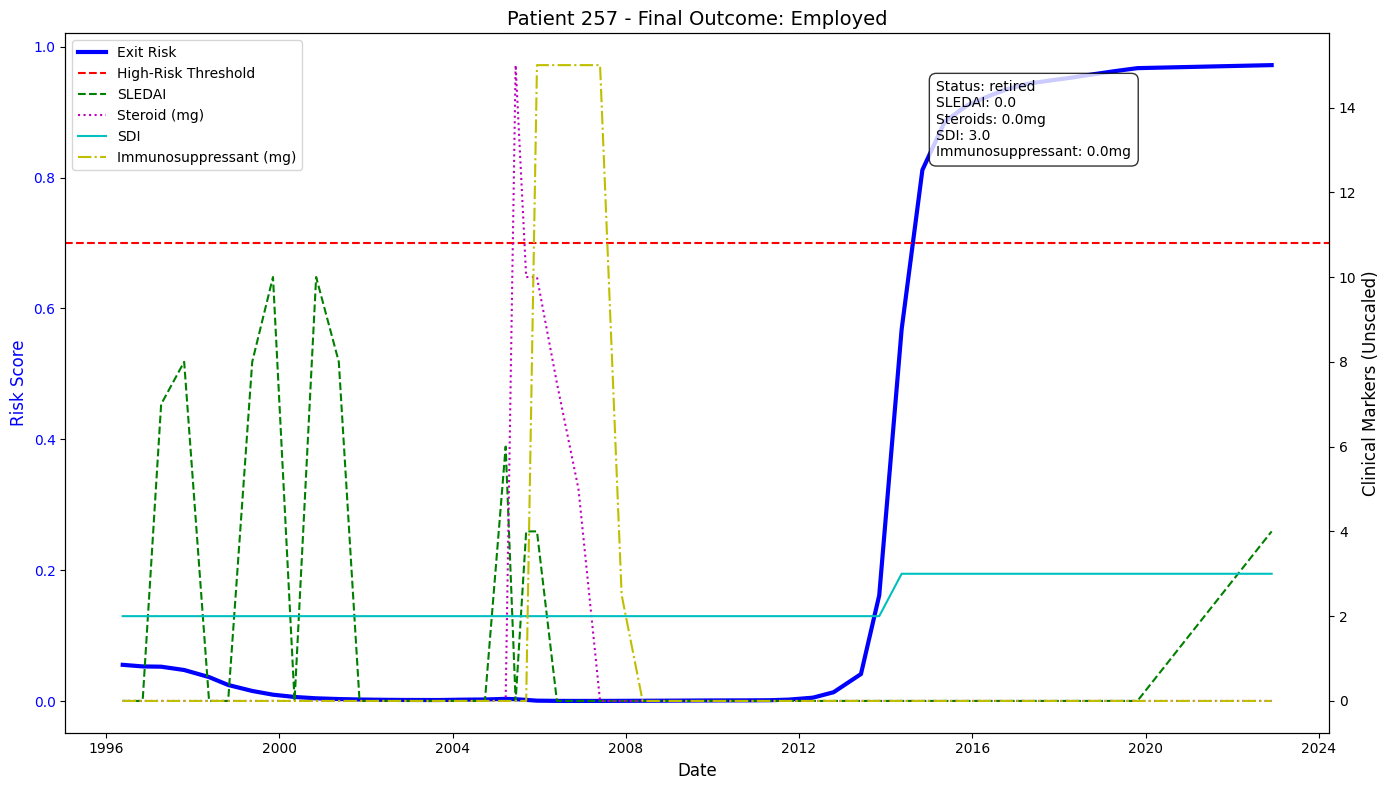

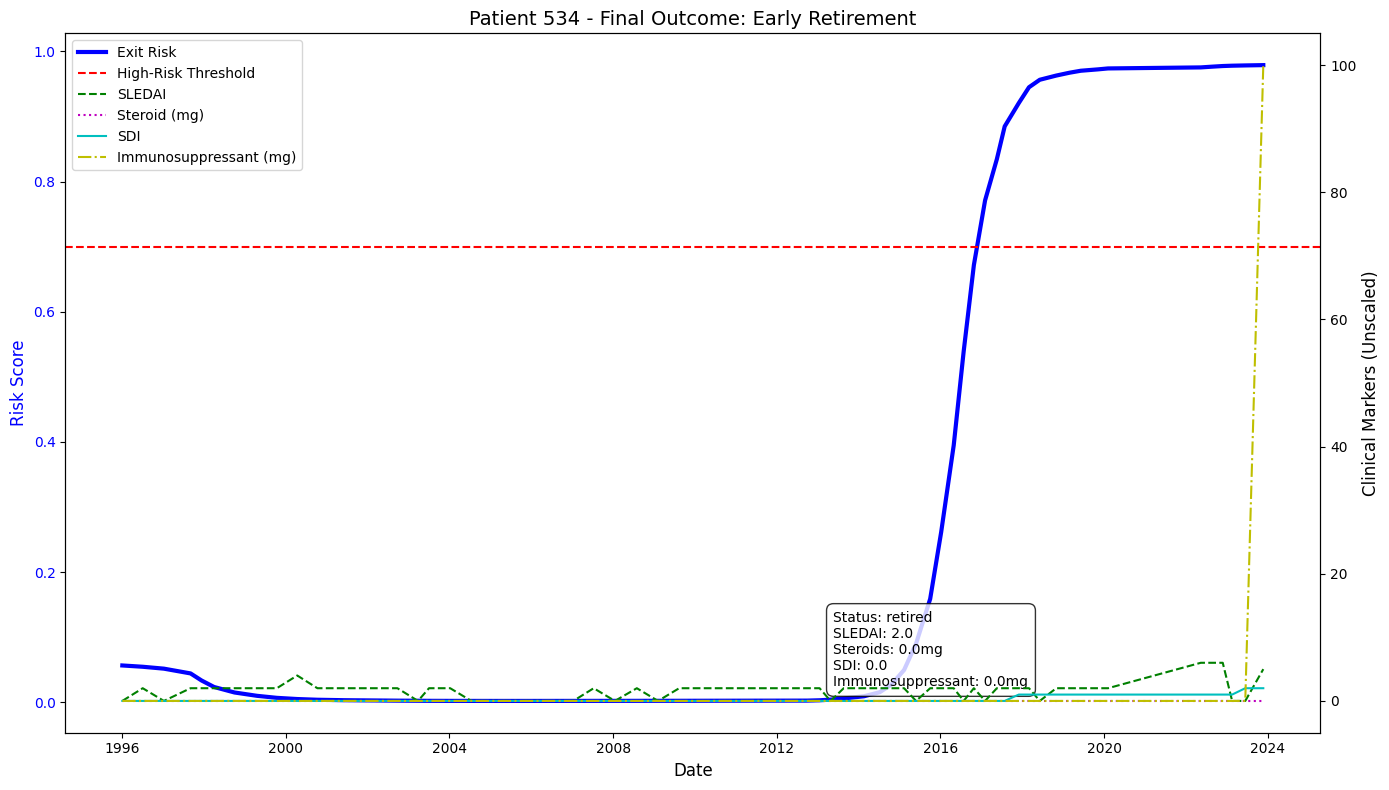

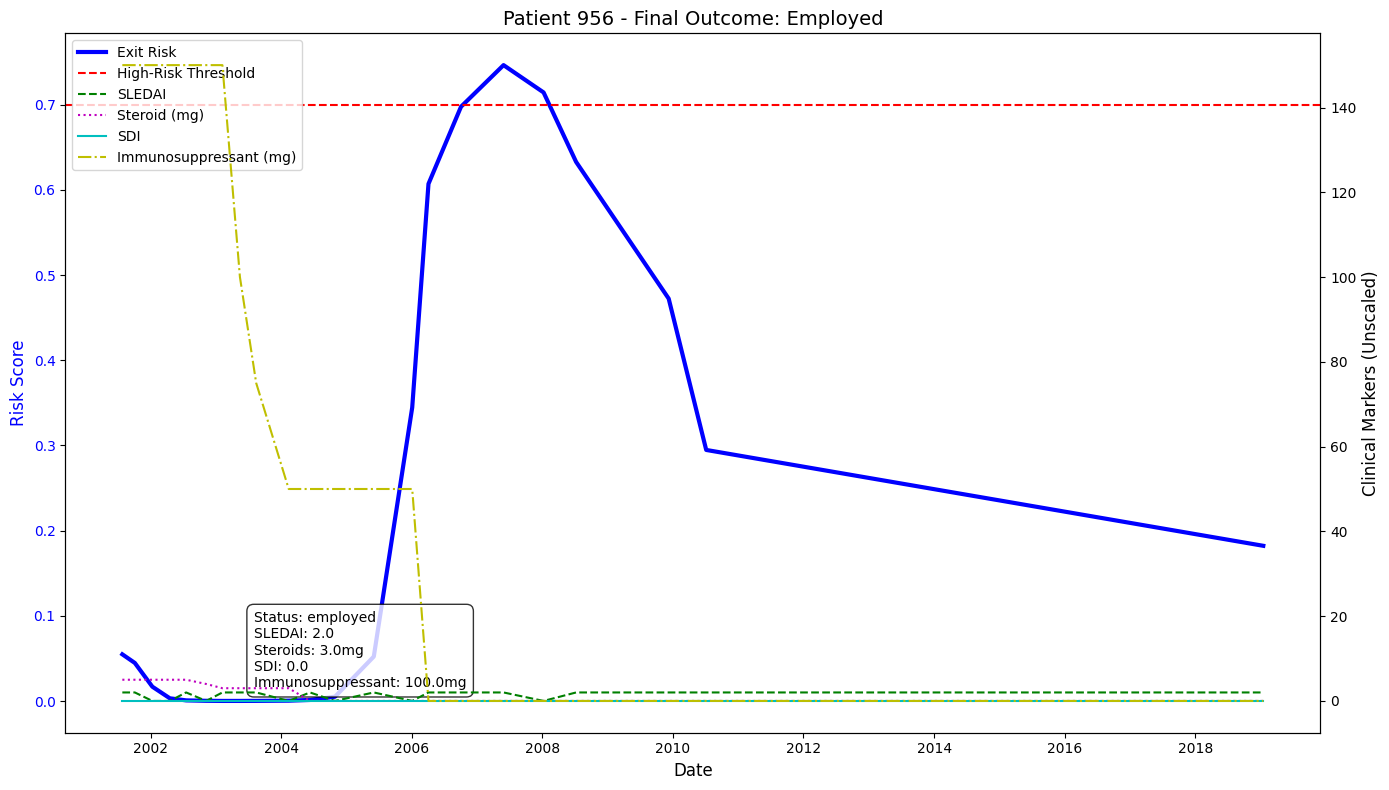

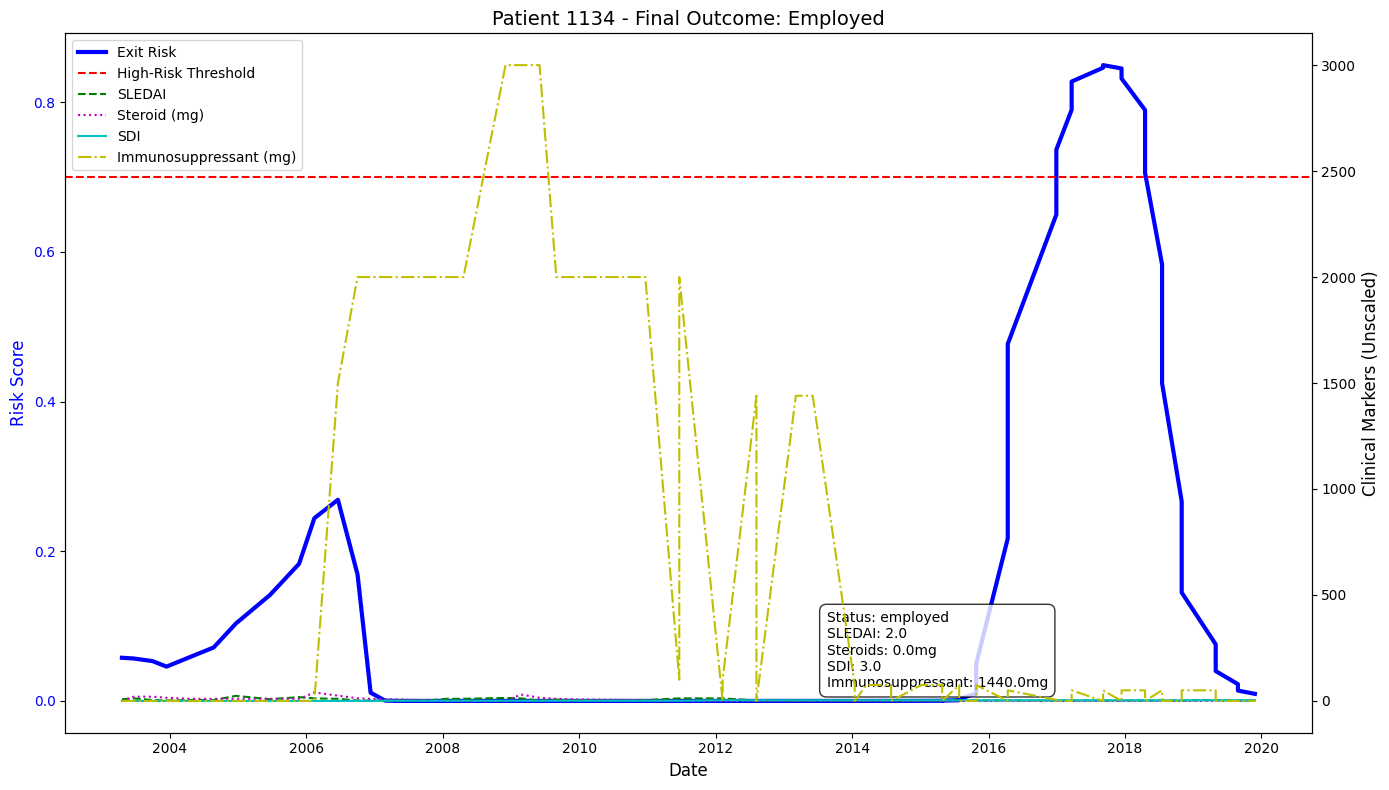

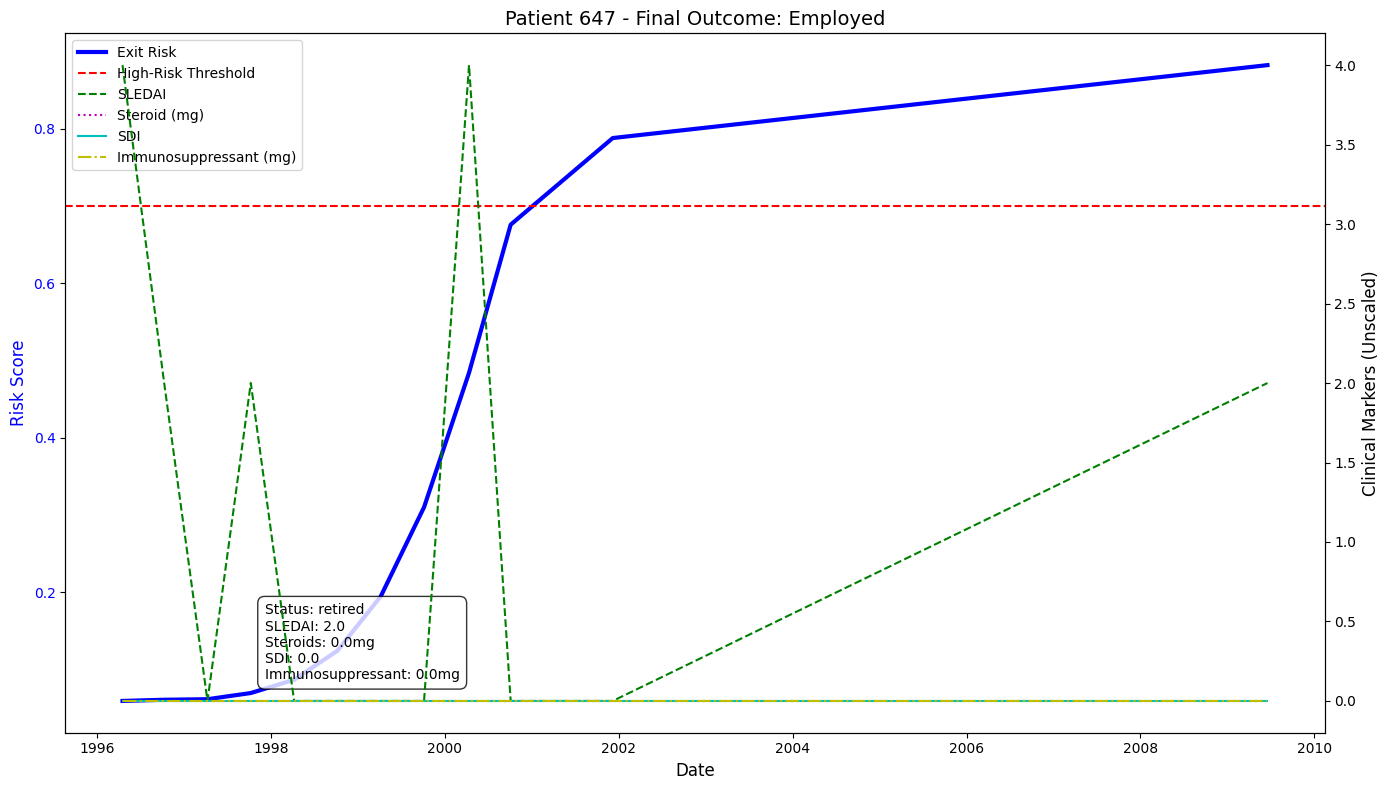

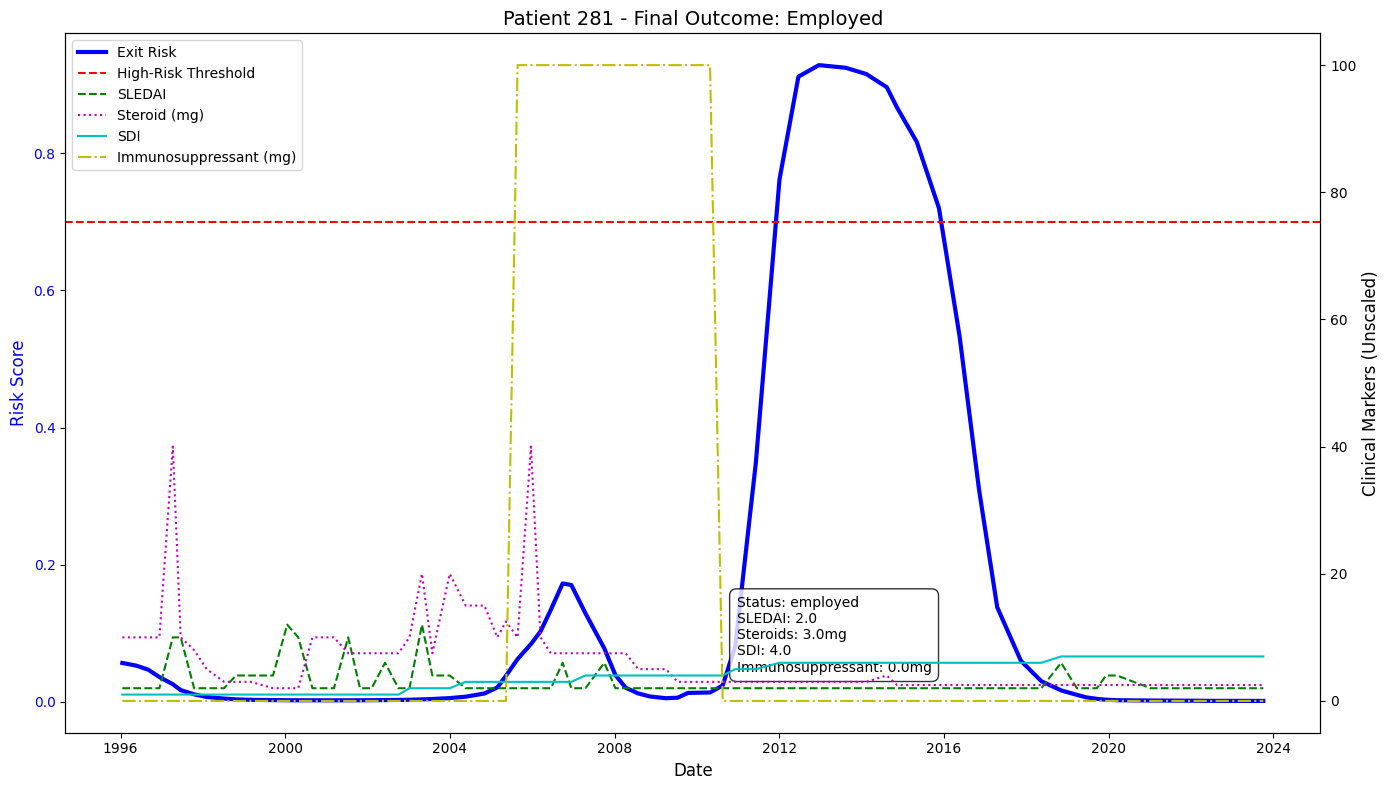

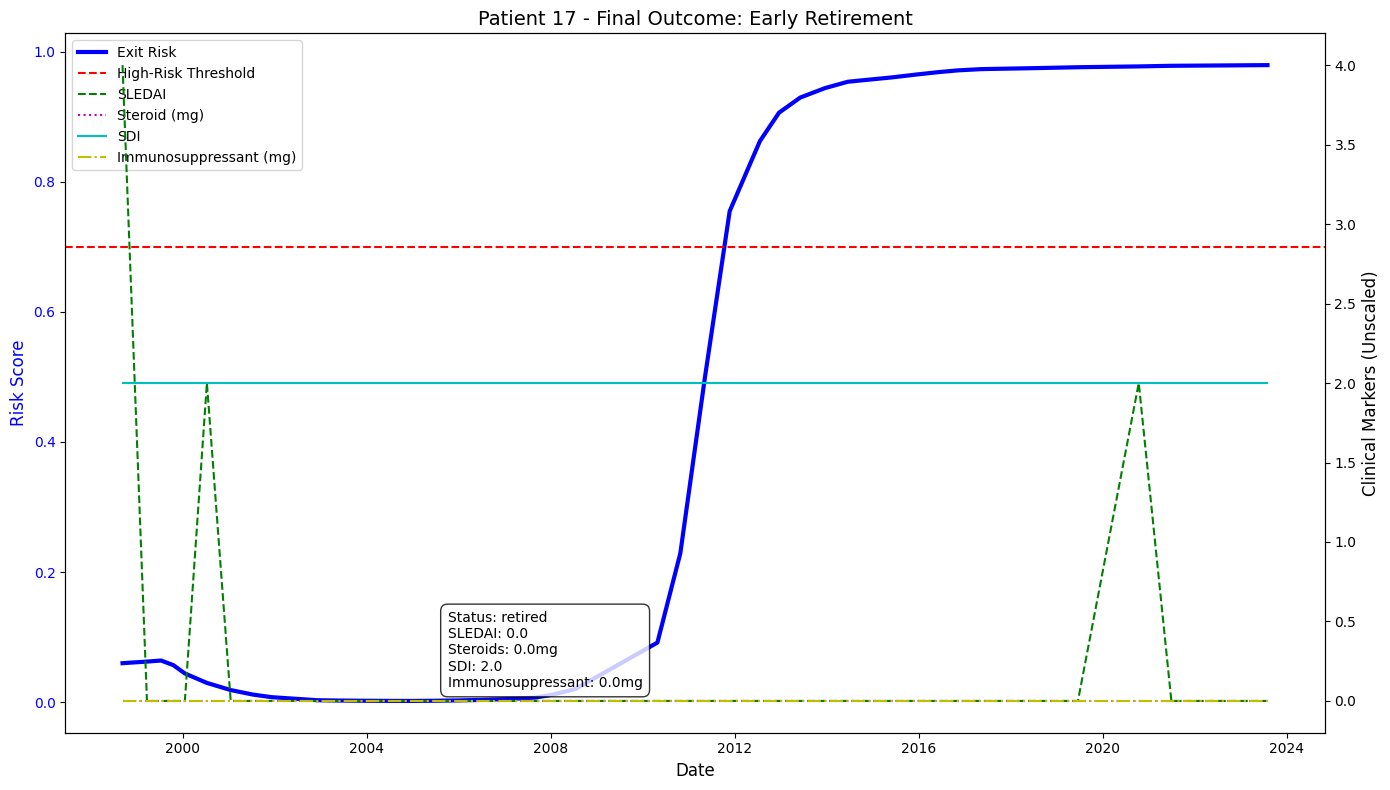

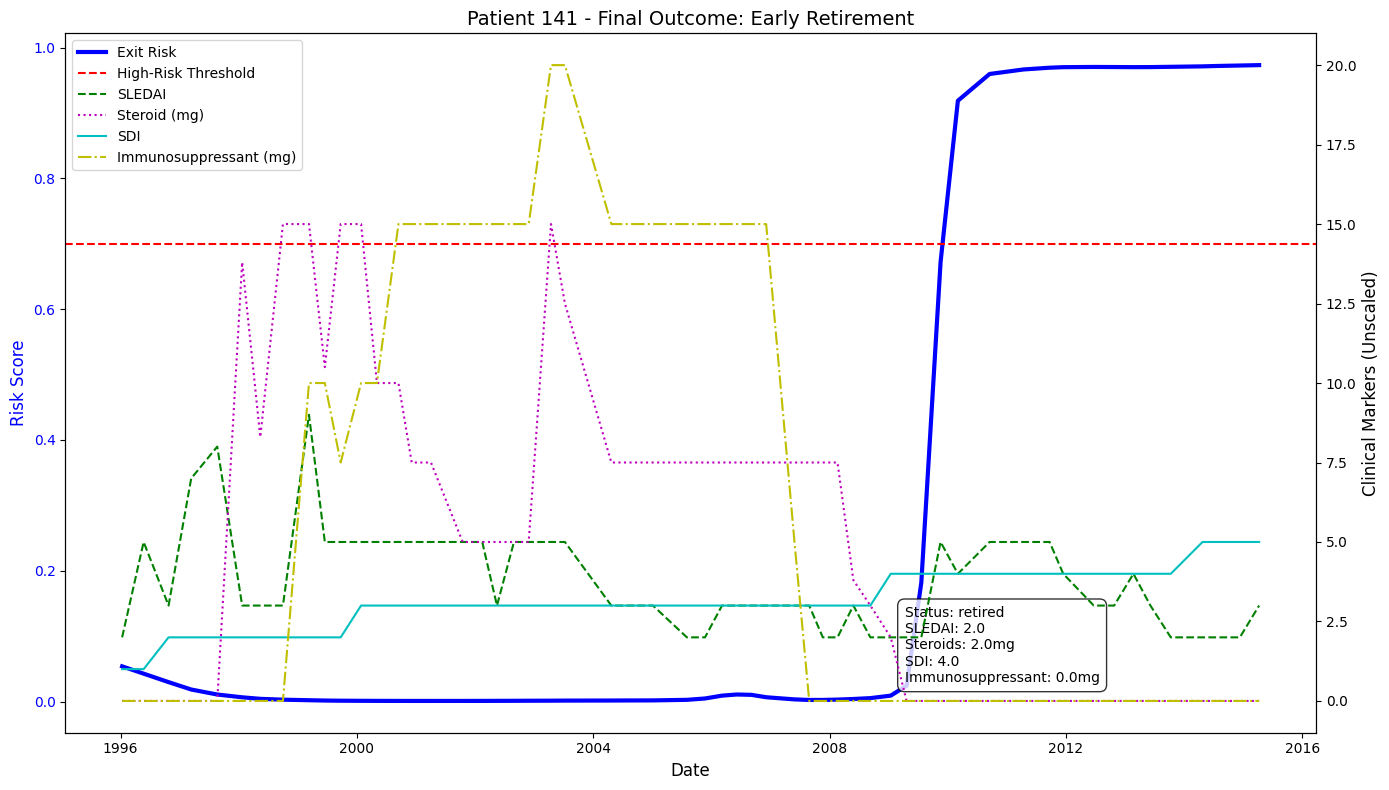

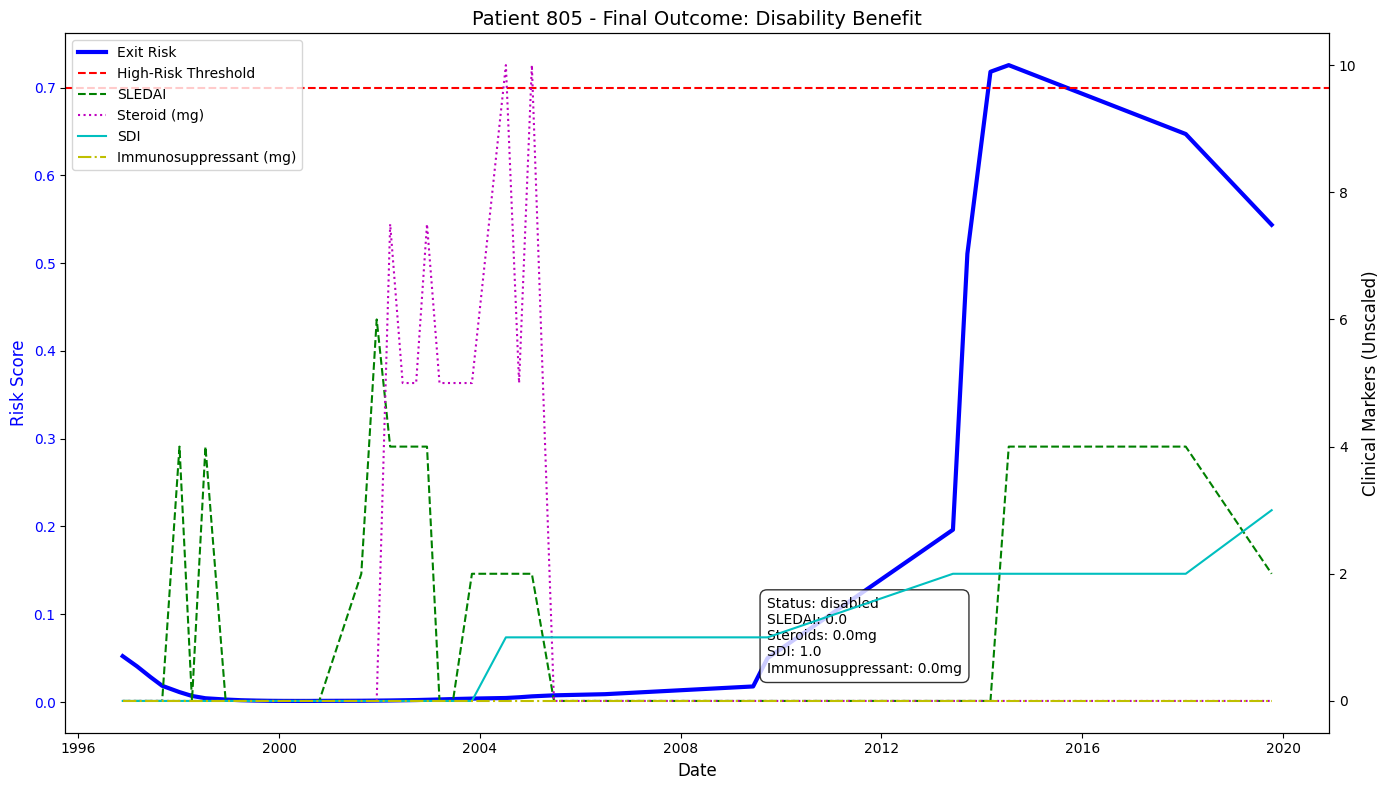

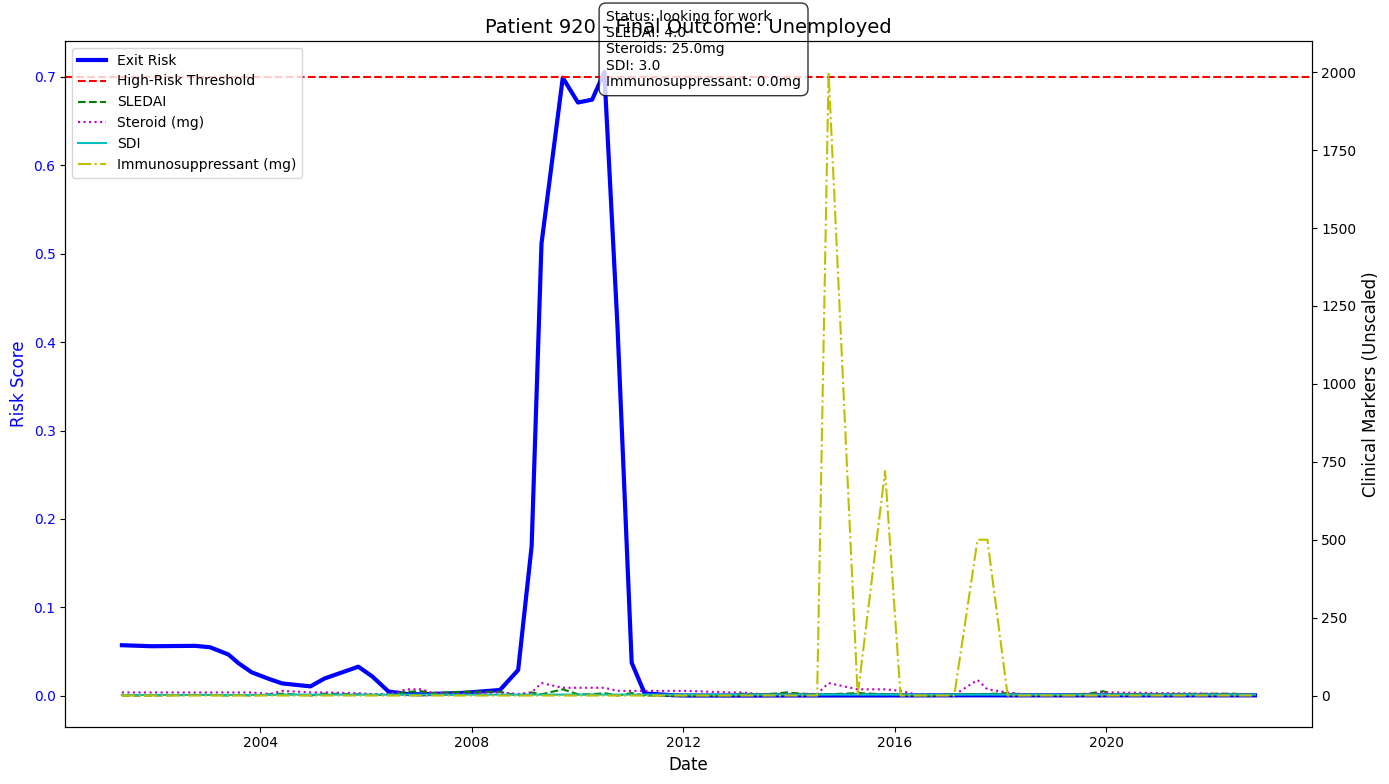

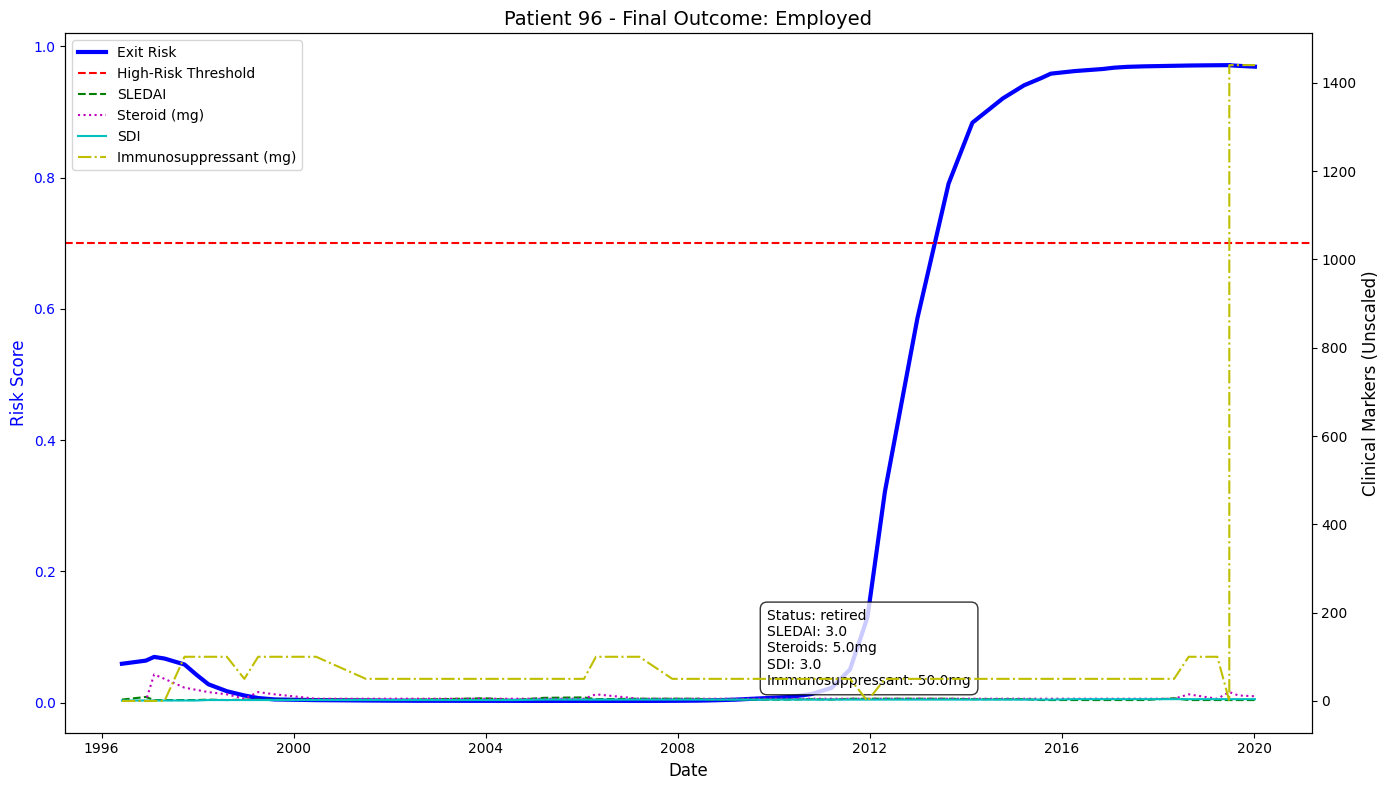

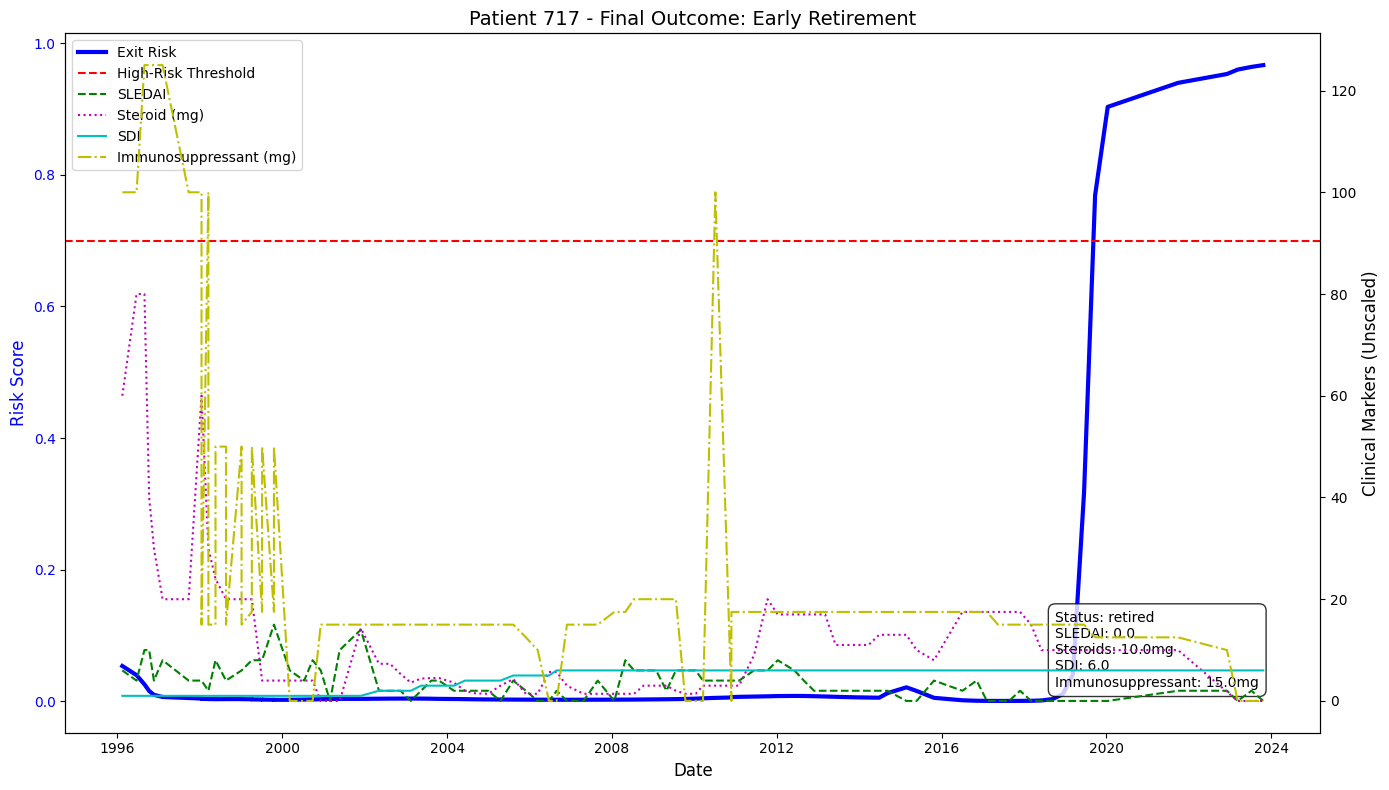

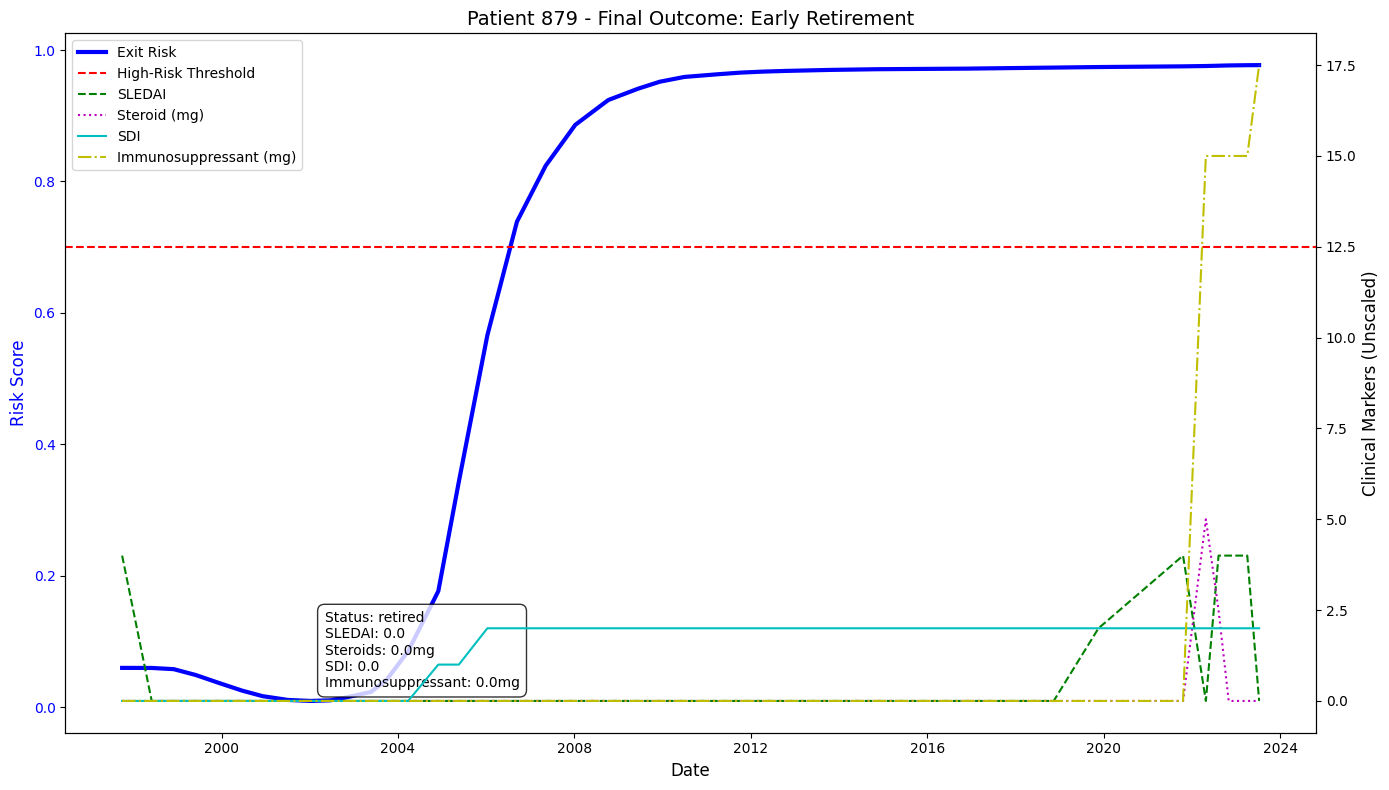

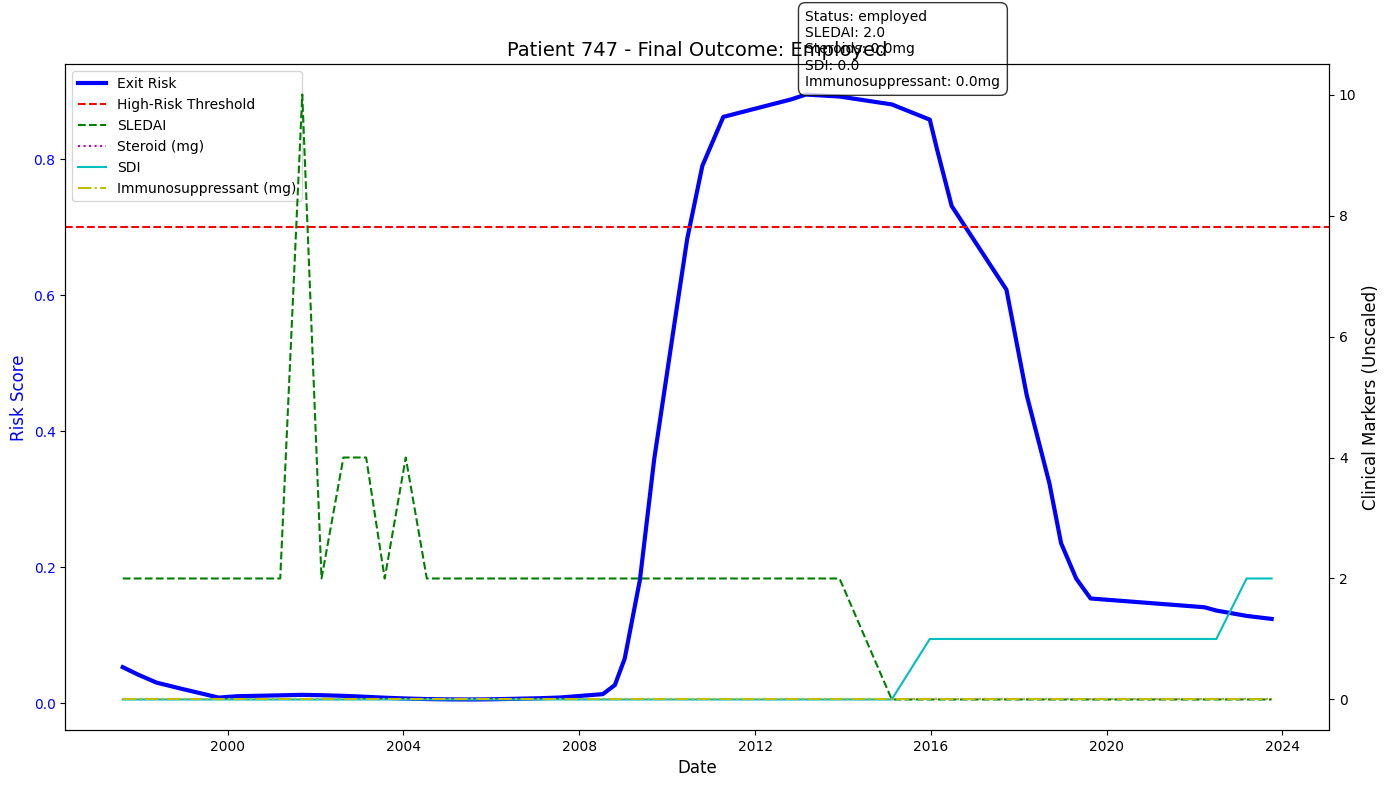

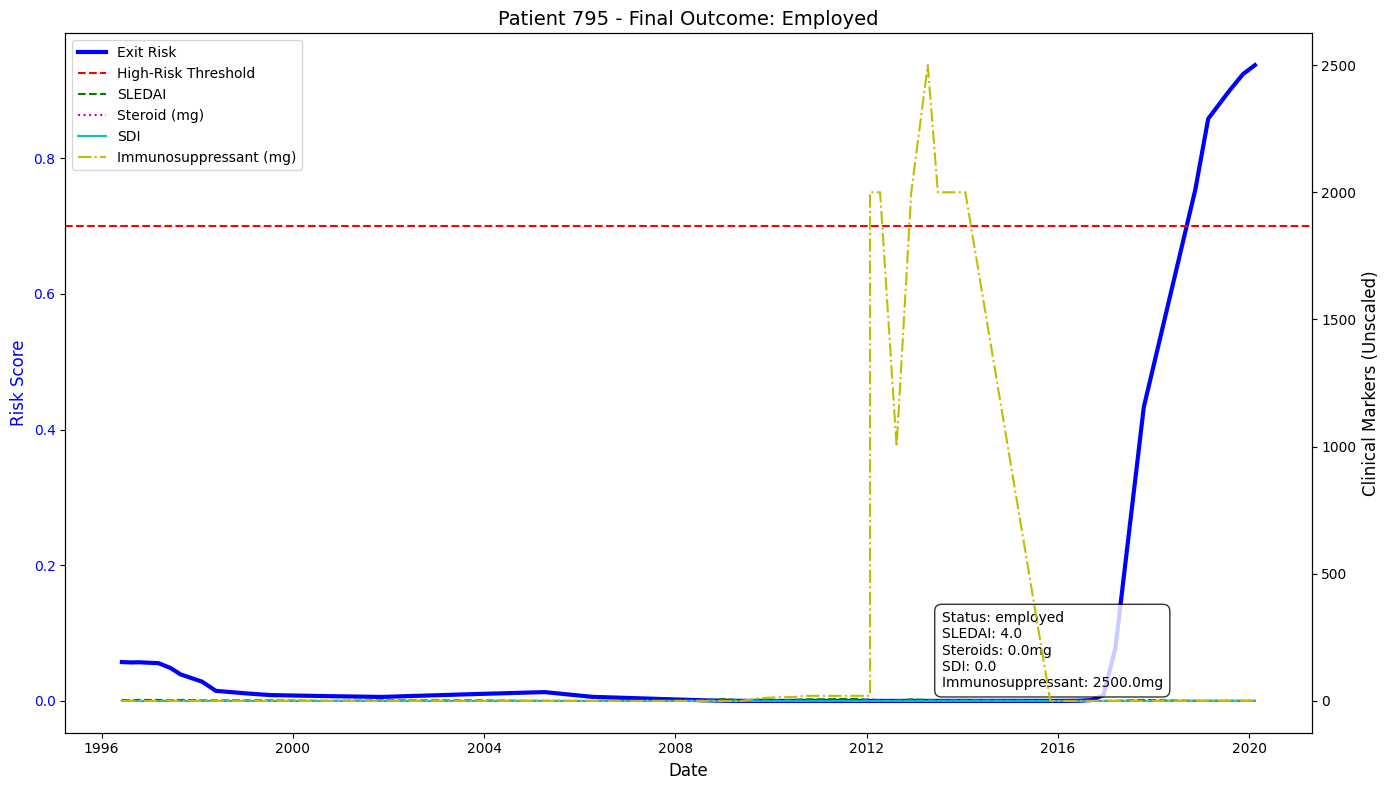

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Generate Time-to-Event Predictions (Risk Scores)
# -------------------------------------------------
def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Generate dynamic risk predictions for a patient across visits"""
    X_patient = np.zeros((1, max_seq_length, len(features)))
    seq_len = len(patient_data)
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    # Get cumulative predictions at each time point
    risks = []
    for t in range(1, seq_len + 1):
        pred = model.predict(X_patient[:, :t, :], verbose=0)
        exit_risk = pred[0][1]  # Assuming class 1 is labor force exit
        risks.append(exit_risk)
    
    return pd.DataFrame({
        'ASSDT': patient_data['ASSDT'].values,
        'Risk_Score': risks,
        'SLEDAI': patient_data['SLEDAI2_I'].values,
        'Steroid_Dose': patient_data['STERDOSE'].values,
        'SDI': patient_data['score_n'].values,  # Added SDI
        'Immunosuppressant': patient_data['ISDOSE'].values,  # Added IMDOSE
        'Employment_Status': patient_data['EMPf'].values
    })

# 2. Identify High-Risk Patients with Actionable Thresholds
# --------------------------------------------------------
def get_high_risk_patients(model, data, features, risk_threshold=0.7, min_visits=3):
    """Find patients who crossed risk threshold with clinical context"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        if any(risk_df['Risk_Score'] >= risk_threshold):
            # Get the first date when risk crossed threshold
            first_high_risk_date = risk_df.loc[risk_df['Risk_Score'] >= risk_threshold, 'ASSDT'].min()
            
            # Get clinical context at that time
            context = patient_data[patient_data['ASSDT'] <= first_high_risk_date].iloc[-1]
            
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': first_high_risk_date,
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'SLEDAI_at_Warning': context['SLEDAI2_I'],
                'Steroid_at_Warning': context['STERDOSE'],
                'SDI_at_Warning': context['score_n'],  # Added SDI
                'Immunosuppressant_at_Warning': context['ISDOSE'],  # Added IMDOSE
                'Employment_at_Warning': context['EMPf'],
                'Months_Prior_to_Exit': (patient_data['ASSDT'].iloc[-1] - first_high_risk_date).days // 30
            })
    
    return pd.DataFrame(high_risk)

# 3. Generate Actionable Insights Report with Unscaled Values
# -------------------------------------
def generate_clinical_report(high_risk_df, scaler, features):
    """Create a clinician-friendly summary with properly unscaled values"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Print verification
    print("\n=== Unscaling Verification ===")
    print("Sample SLEDAI values:")
    print("Scaled:", high_risk_df['SLEDAI_at_Warning'].head(3).values)
    print("Unscaled:", high_risk_df['SLEDAI_unscaled'].head(3).values)
    
    # Initialize report
    report = {
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'High_Immunosuppressants': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 50])/len(high_risk_df):.0%} on high immunosuppressants (≥50mg)",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome
    for outcome in high_risk_df['Final_Outcome'].unique():
        n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
        n_total = len(data[data['end_state'] == outcome])
        report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

# 4. Enhanced Visualization with All Predictors
# -----------------------------
def plot_high_risk_trajectory(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with single status change annotation"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot risk score (left axis)
    ax1.plot(risk_df['ASSDT'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Plot clinical markers (right axis)
    ax2 = ax1.twinx()
    ax2.plot(risk_df['ASSDT'], risk_df['SLEDAI_unscaled'], 'g--', label='SLEDAI')
    ax2.plot(risk_df['ASSDT'], risk_df['Steroid_unscaled'], 'm:', label='Steroid (mg)')
    ax2.plot(risk_df['ASSDT'], risk_df['SDI_unscaled'], 'c-', label='SDI')
    ax2.plot(risk_df['ASSDT'], risk_df['Immunosuppressant_unscaled'], 'y-.', label='Immunosuppressant (mg)')
    ax2.set_ylabel('Clinical Markers (Unscaled)', color='k', fontsize=12)
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['ASSDT'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Execute the analysis
# -------------------
# Get high-risk patients

# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with all predictors
print("\nVisualizing High-Risk Patient Trajectories...")
for pid in high_risk_df['PTNO'].sample(15, random_state=69):
    plot_high_risk_trajectory(pid, data, model, features, scaler)

Available columns in high_risk_df: ['PTNO', 'First_High_Risk_Date', 'Final_Outcome', 'SLEDAI_at_Warning', 'Steroid_at_Warning', 'SDI_at_Warning', 'Immunosuppressant_at_Warning', 'Employment_at_Warning', 'Months_Prior_to_Exit', 'SLEDAI_unscaled', 'Steroid_unscaled', 'SDI_unscaled', 'Immunosuppressant_unscaled']

=== Unscaling Verification ===
Sample SLEDAI values:
Scaled: [0.         0.14705882 0.        ]
Unscaled: [0. 5. 0.]

=== Value Distributions in High-Risk Patients (Unscaled) ===
SLEDAI:
 count    57.000000
mean      1.736842
std       2.341598
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max      10.000000
Name: SLEDAI_unscaled, dtype: float64

Steroid Doses:
 count    57.000000
mean      2.938596
std       5.127021
min       0.000000
25%       0.000000
50%       0.000000
75%       5.000000
max      25.000000
Name: Steroid_unscaled, dtype: float64

SDI Scores:
 count    57.000000
mean      1.754386
std       1.765550
min       0.000000
25%       0

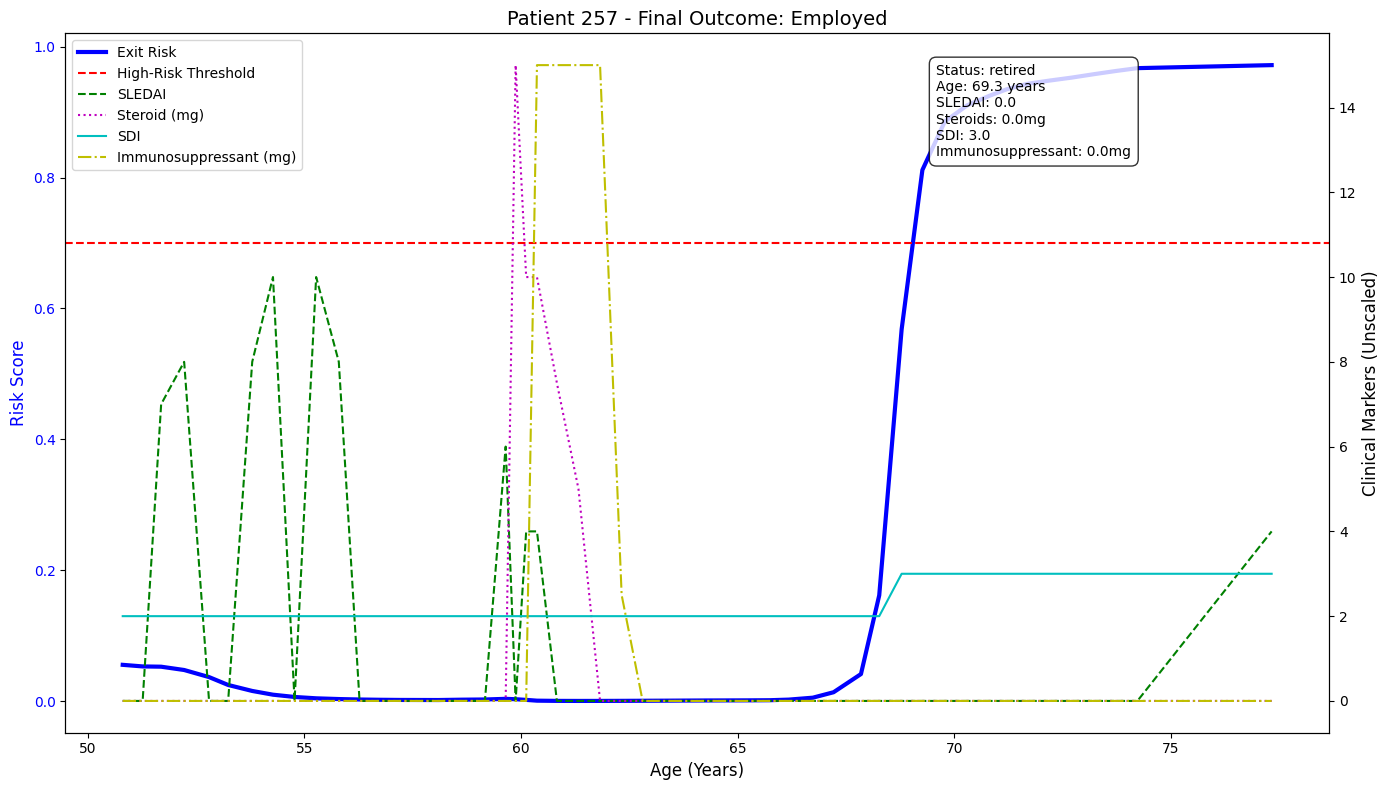

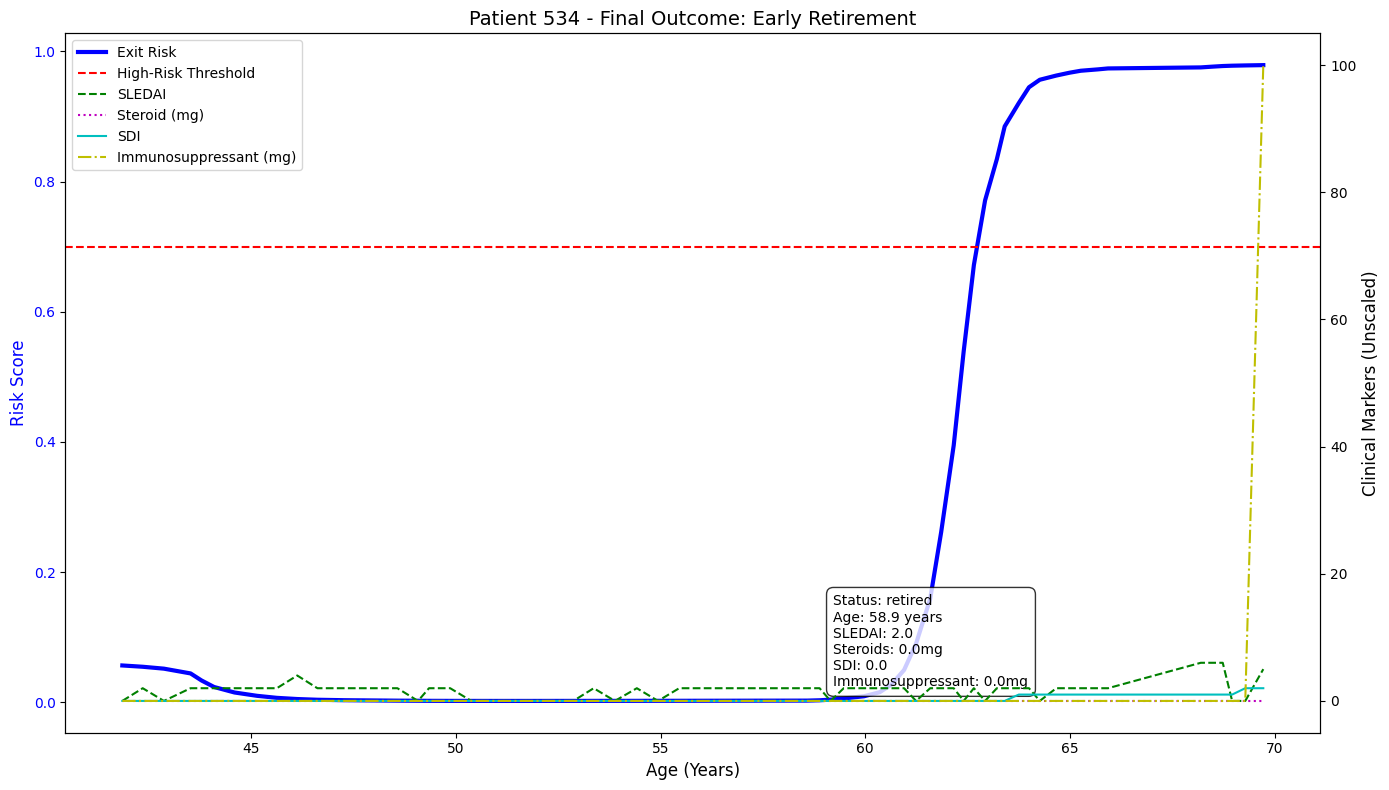

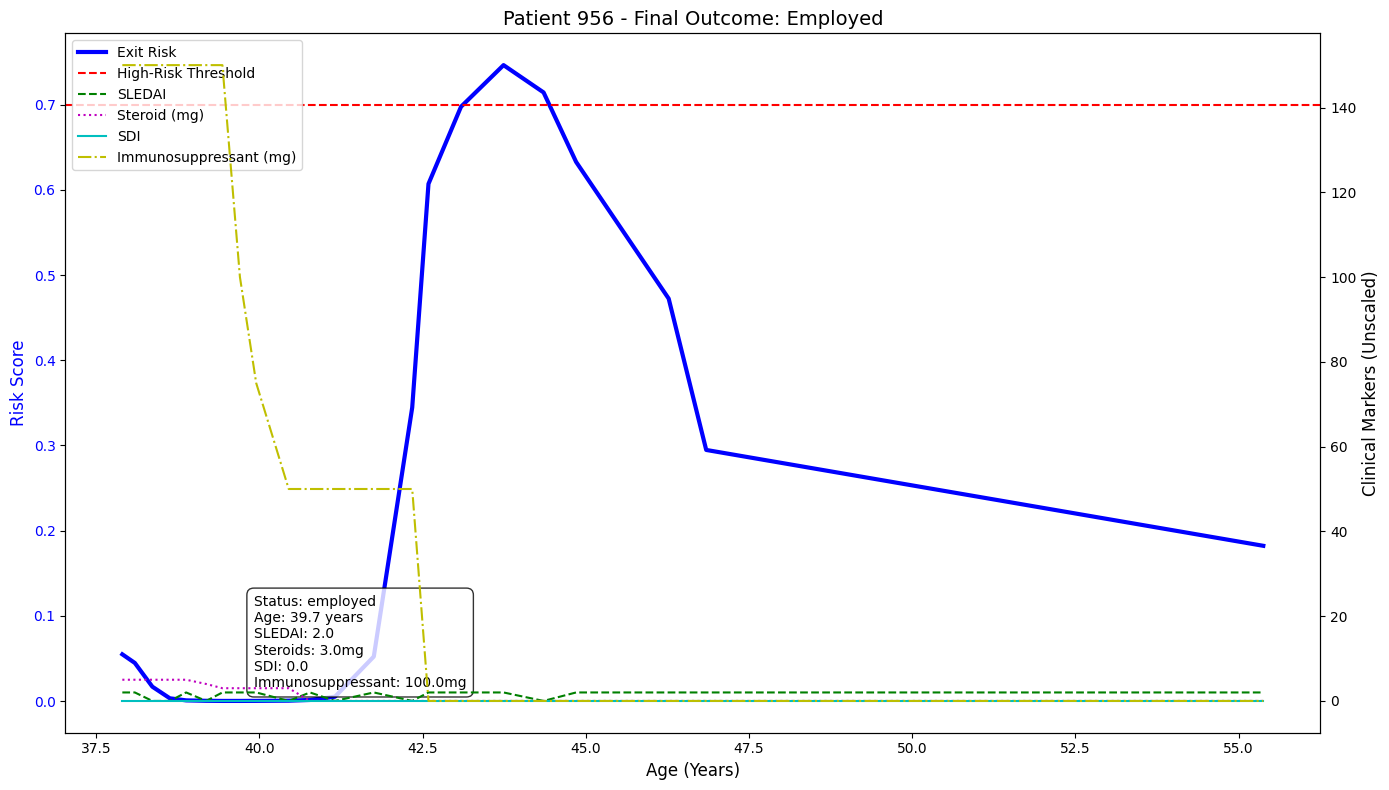

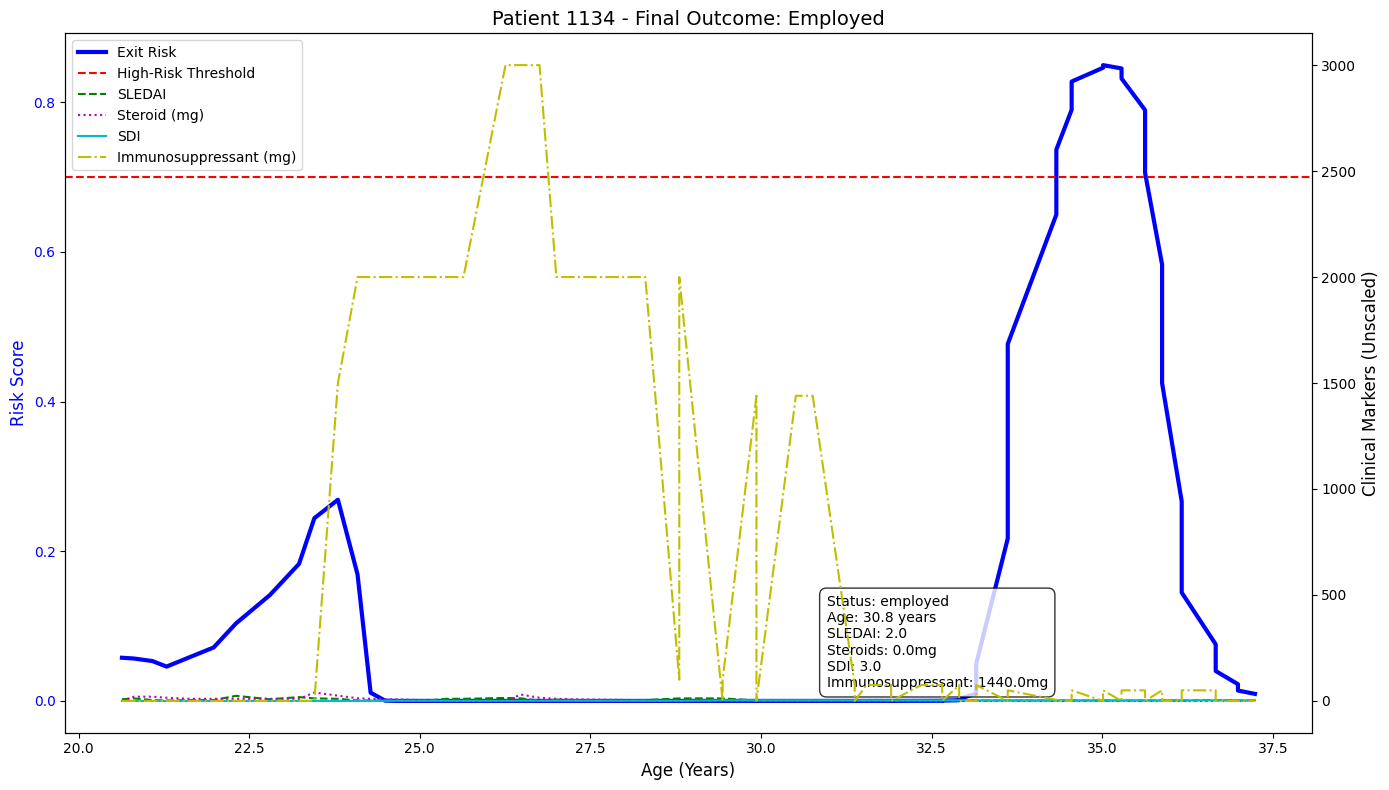

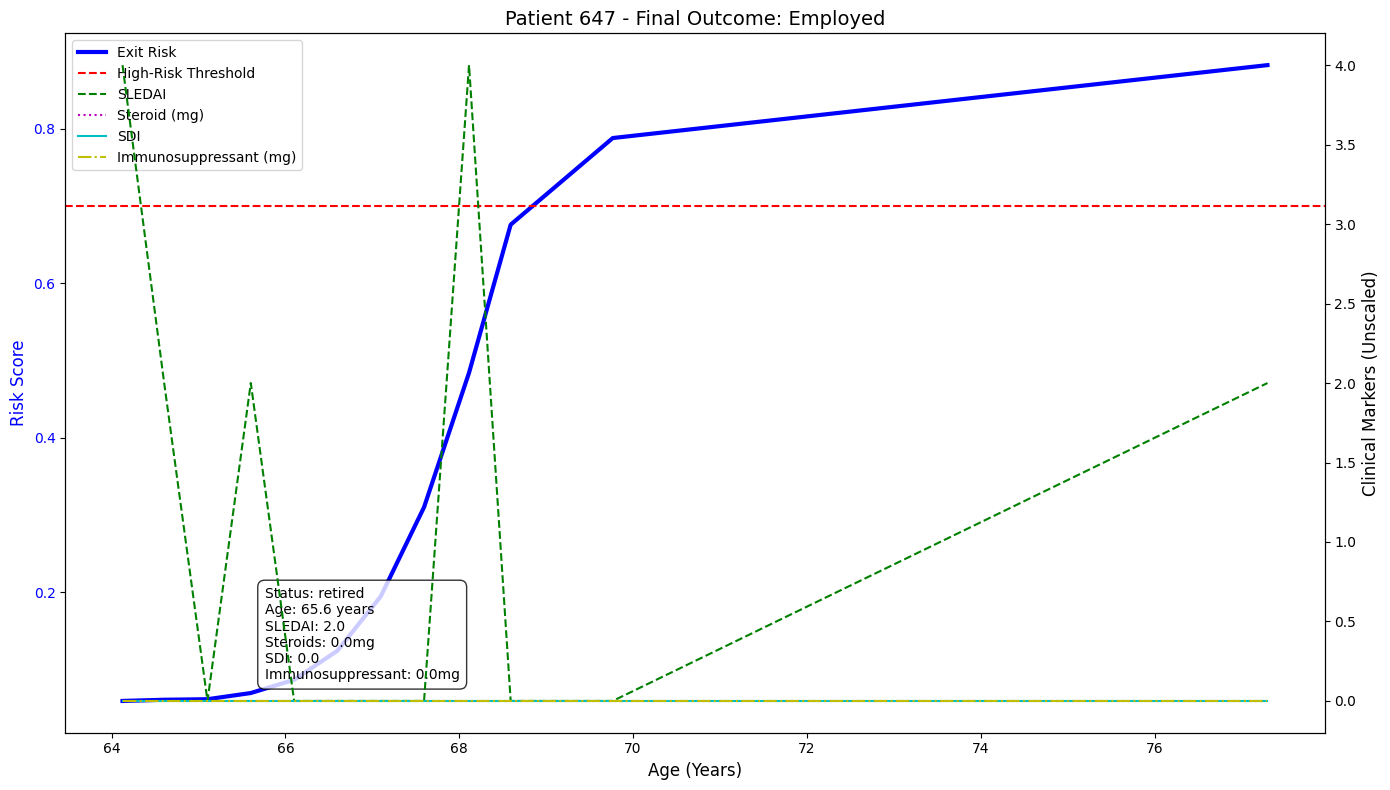

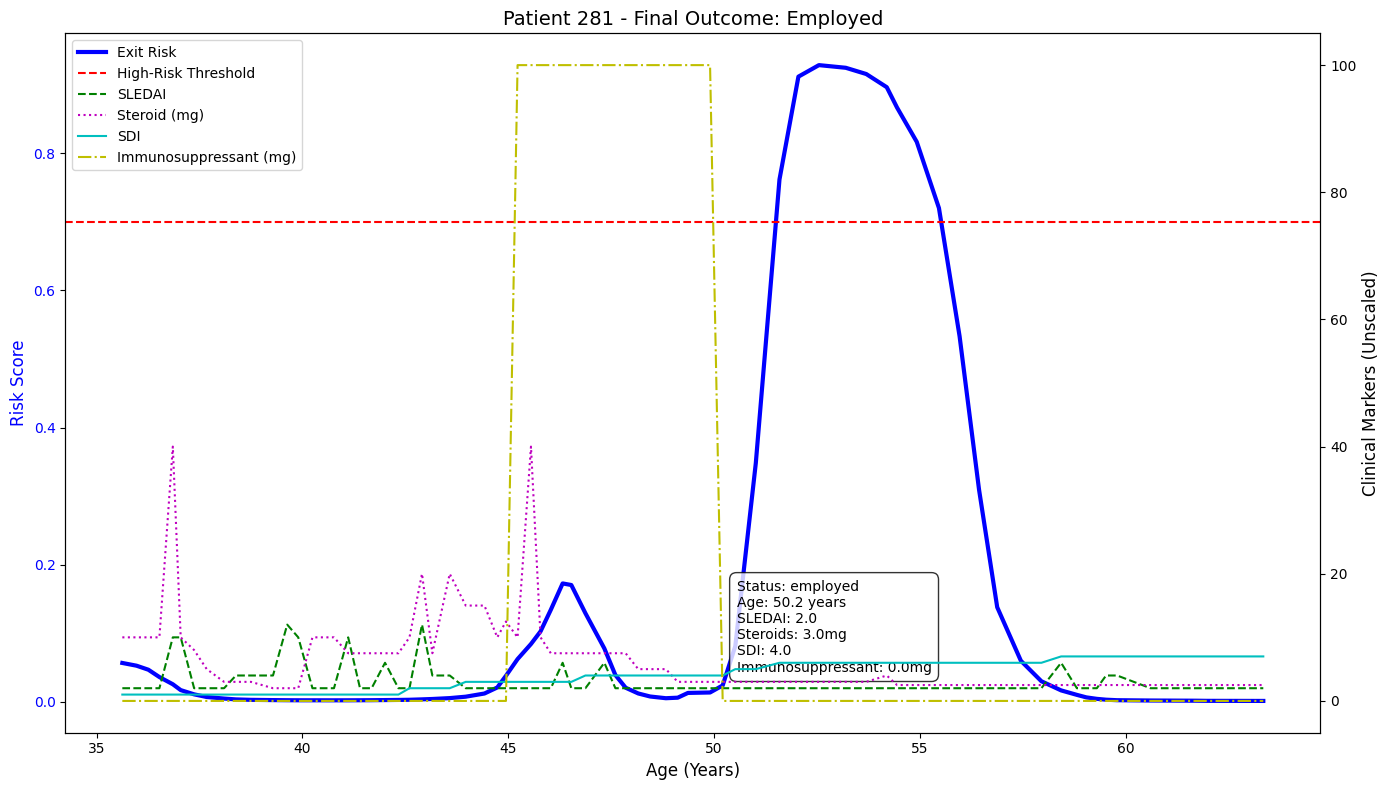

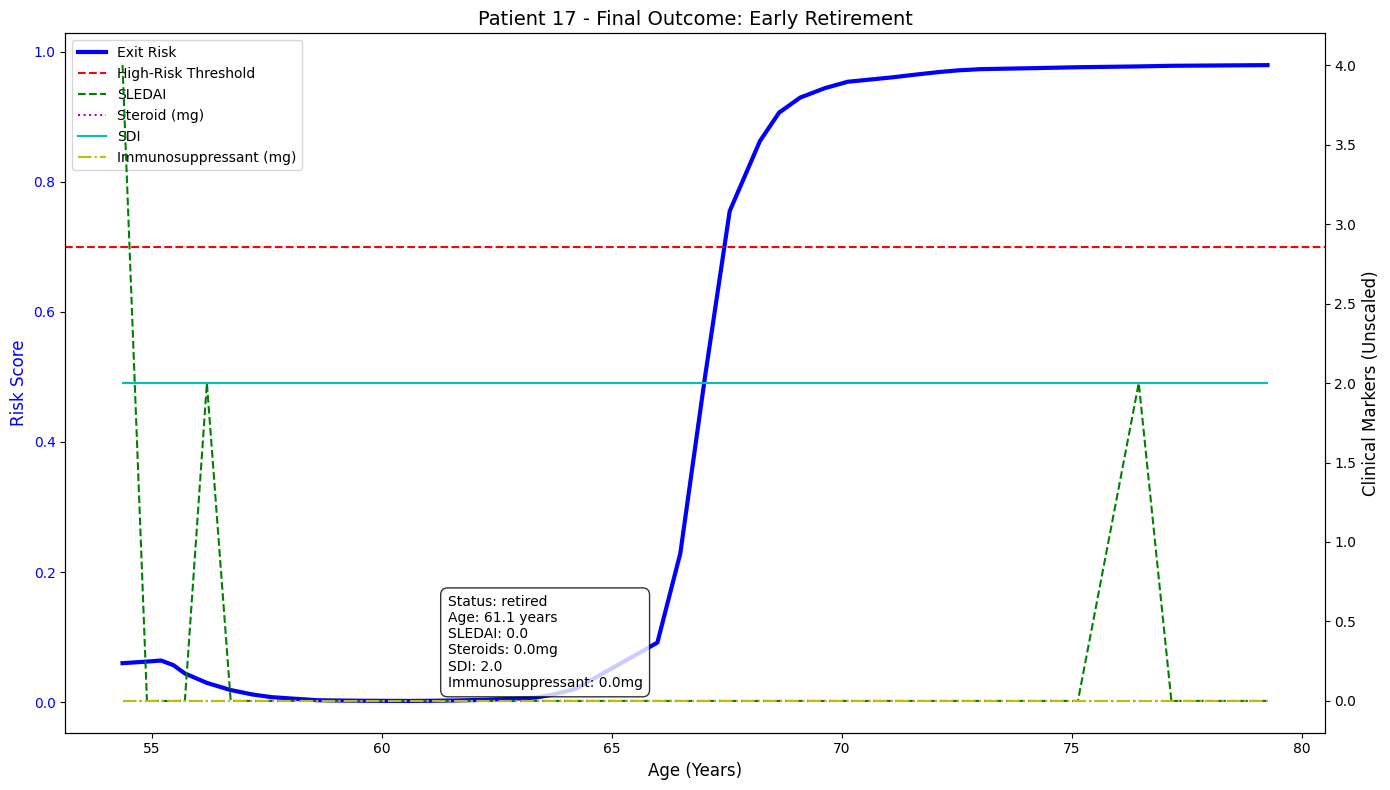

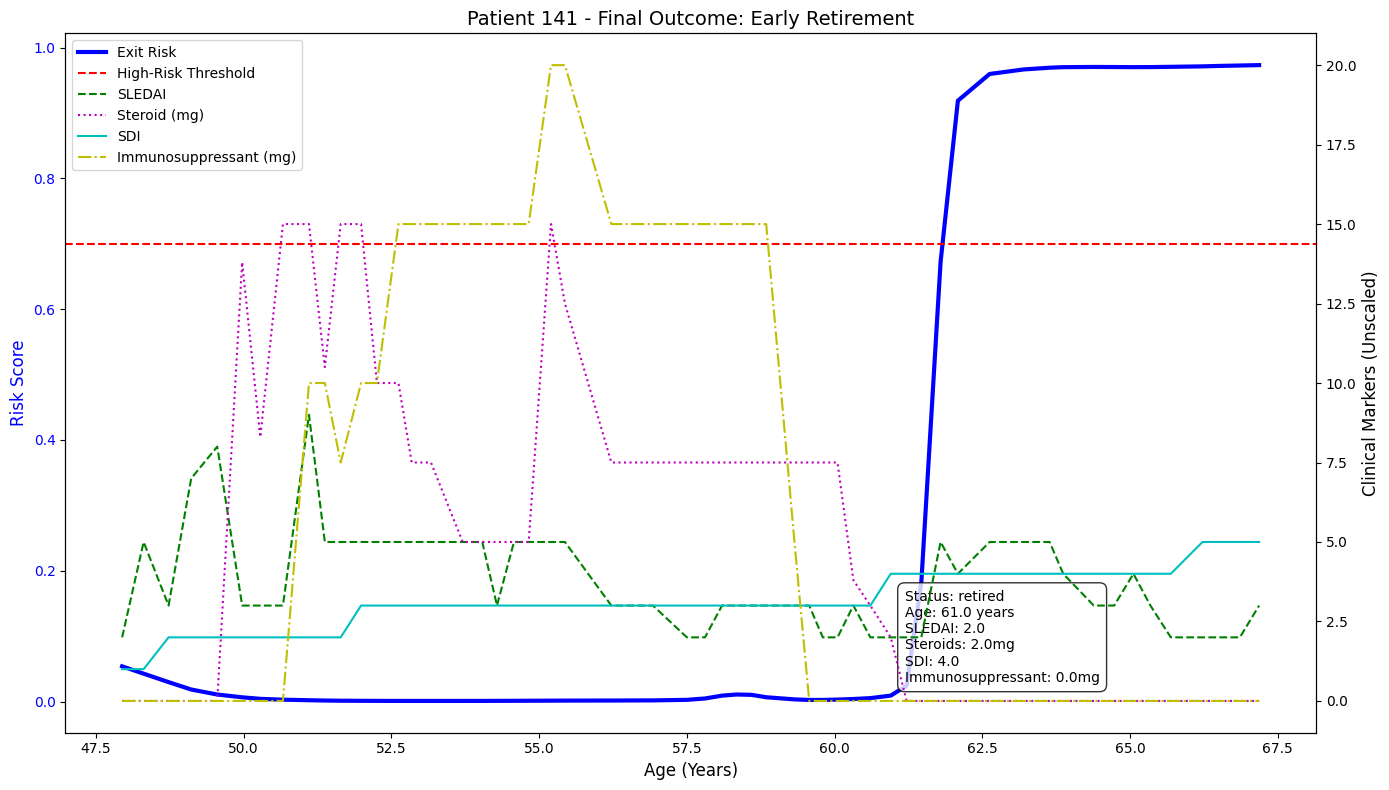

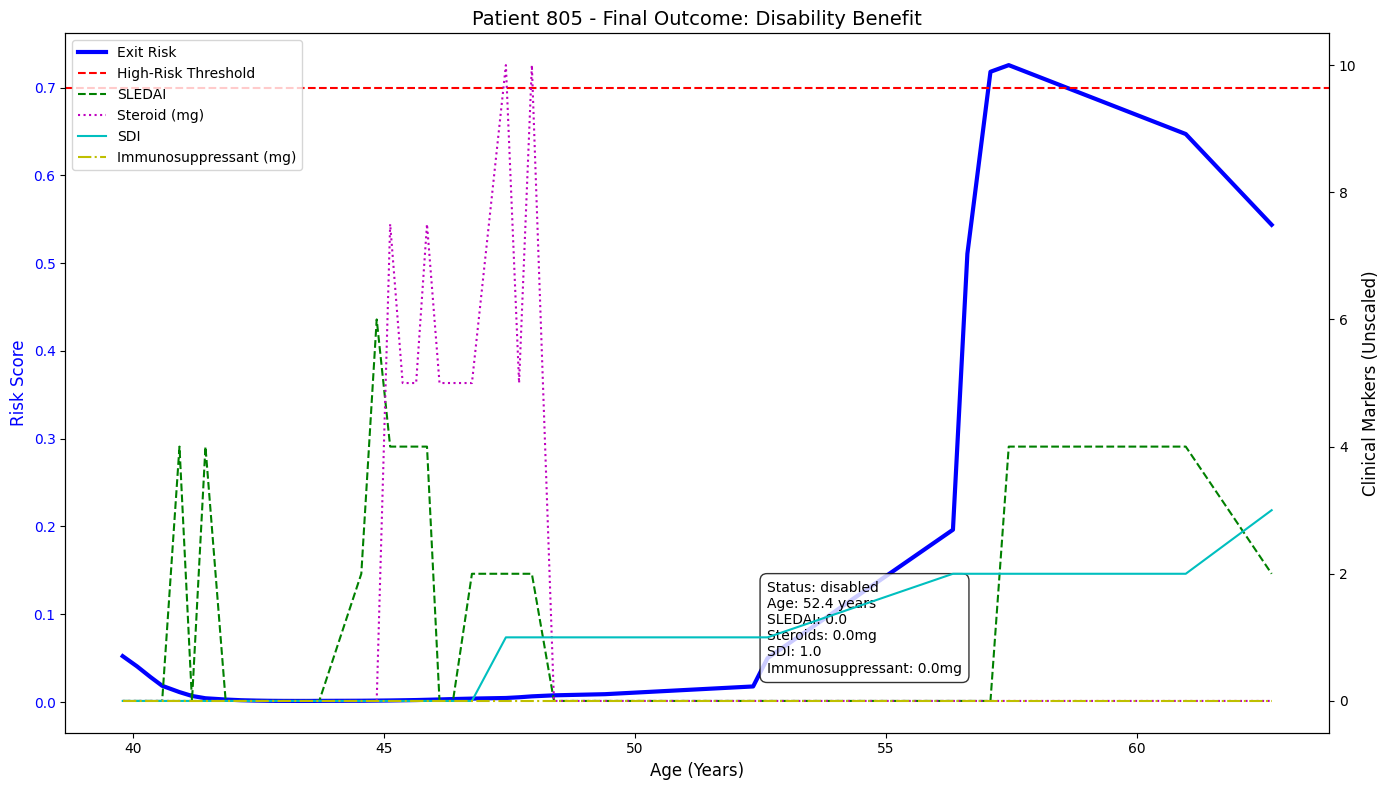

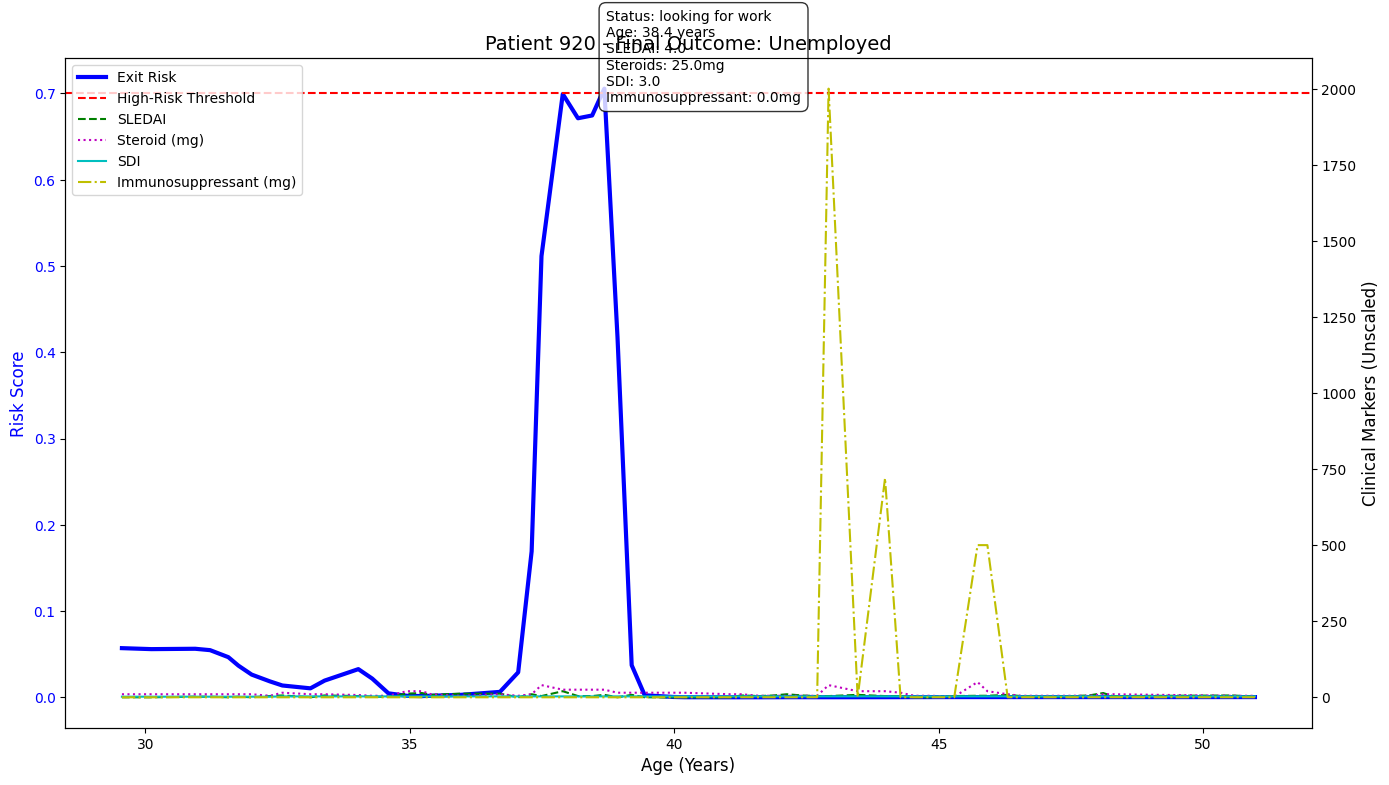

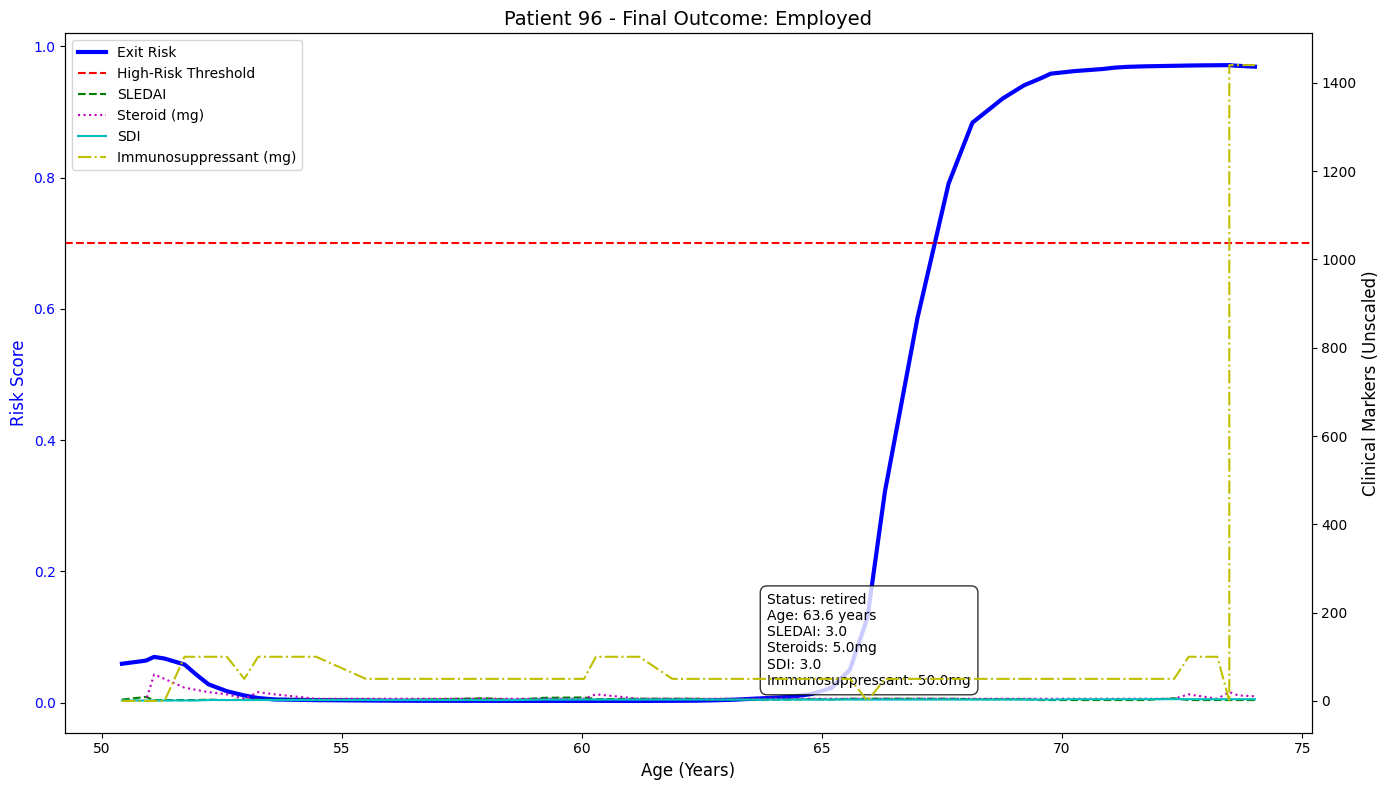

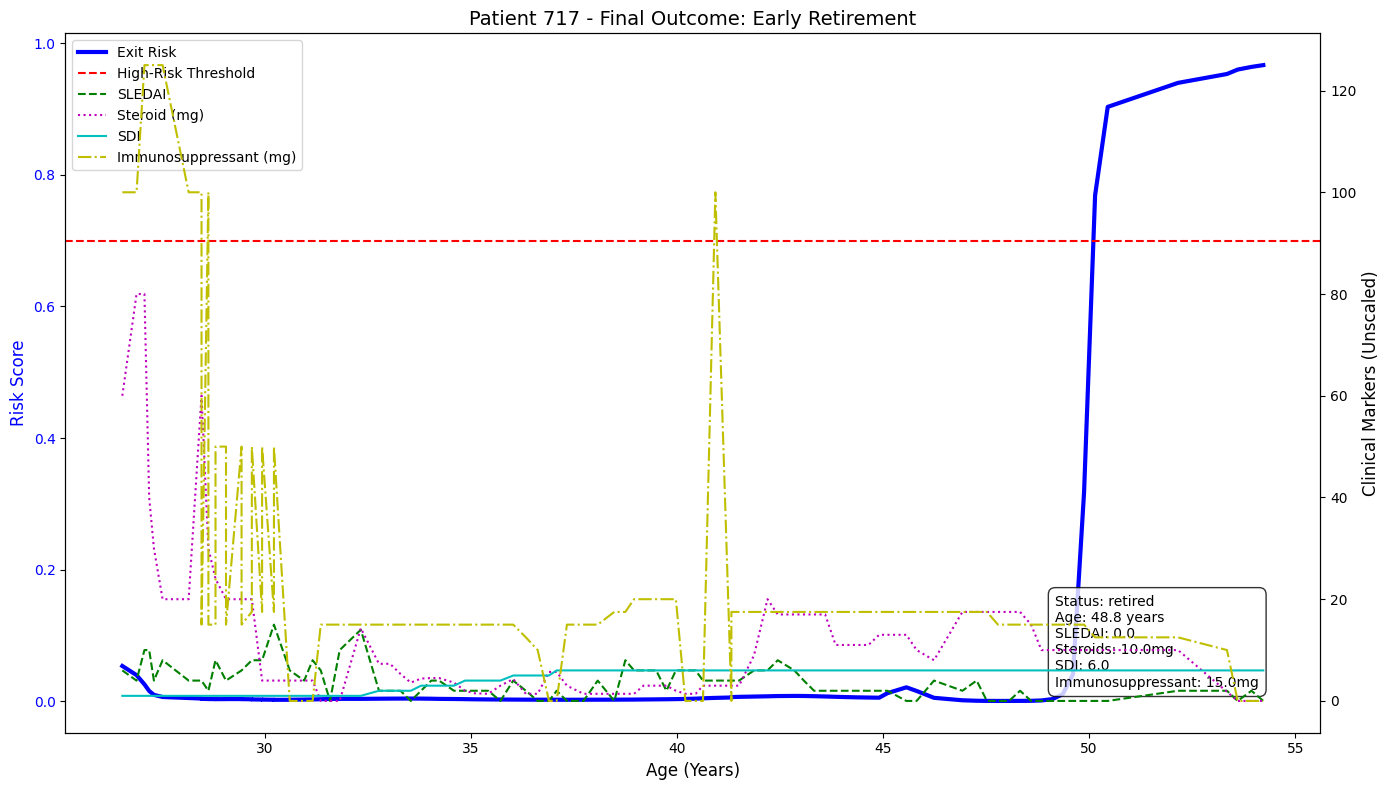

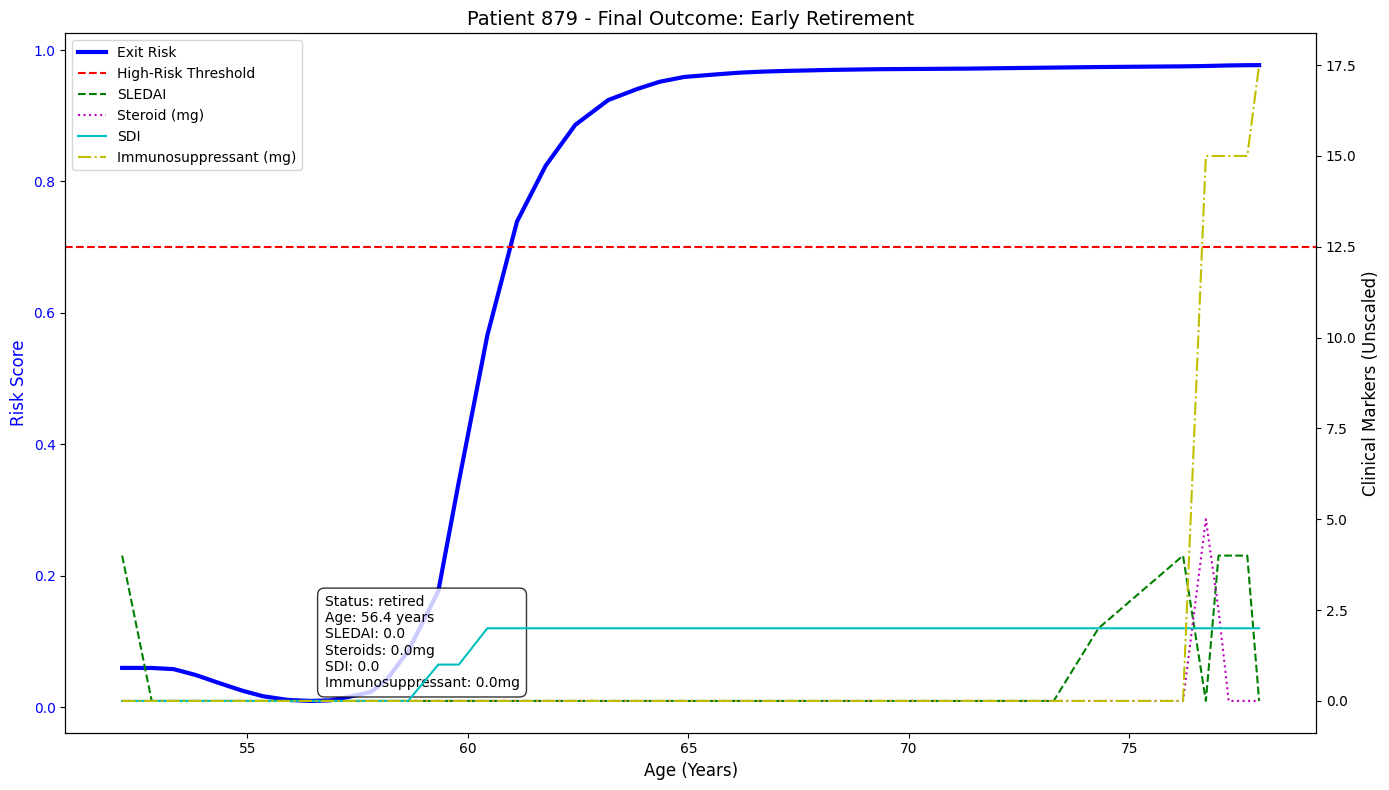

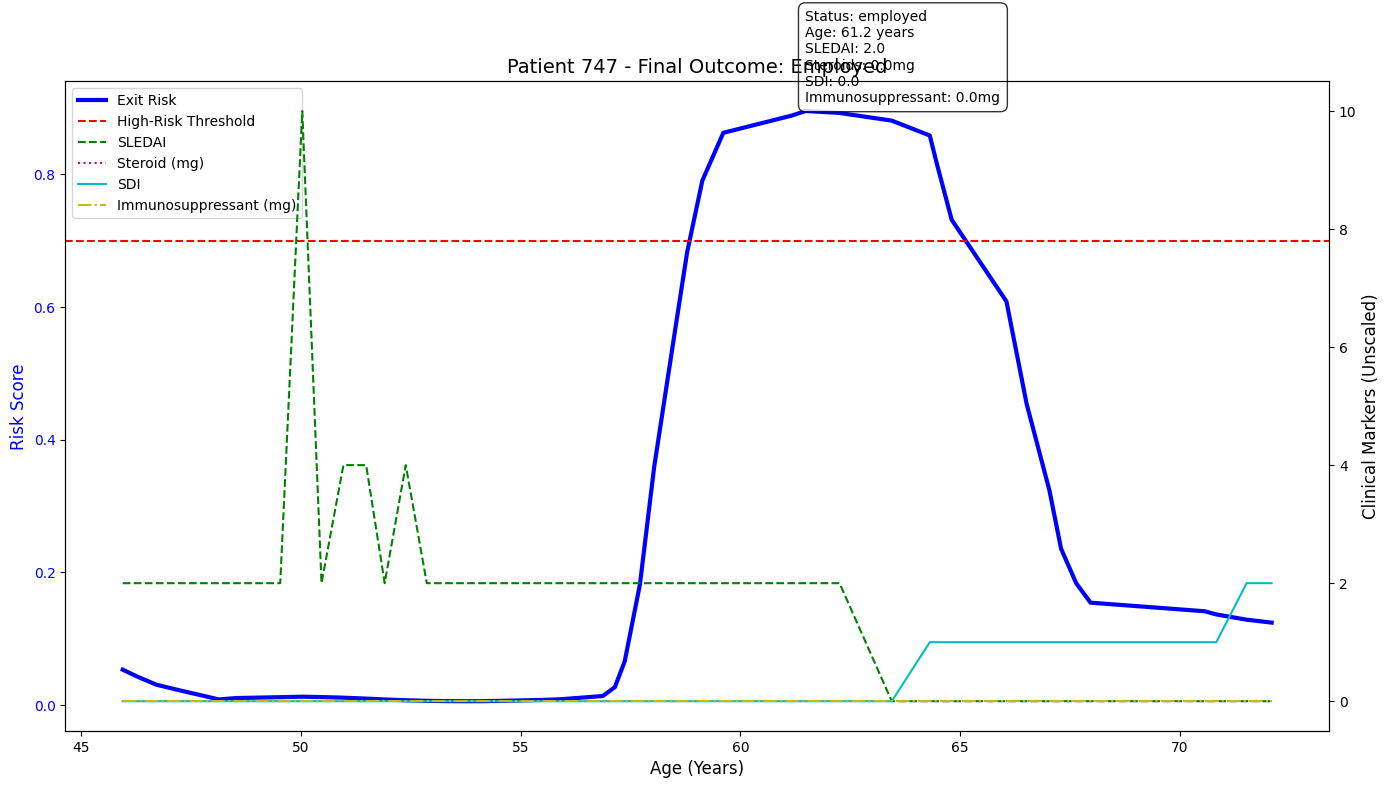

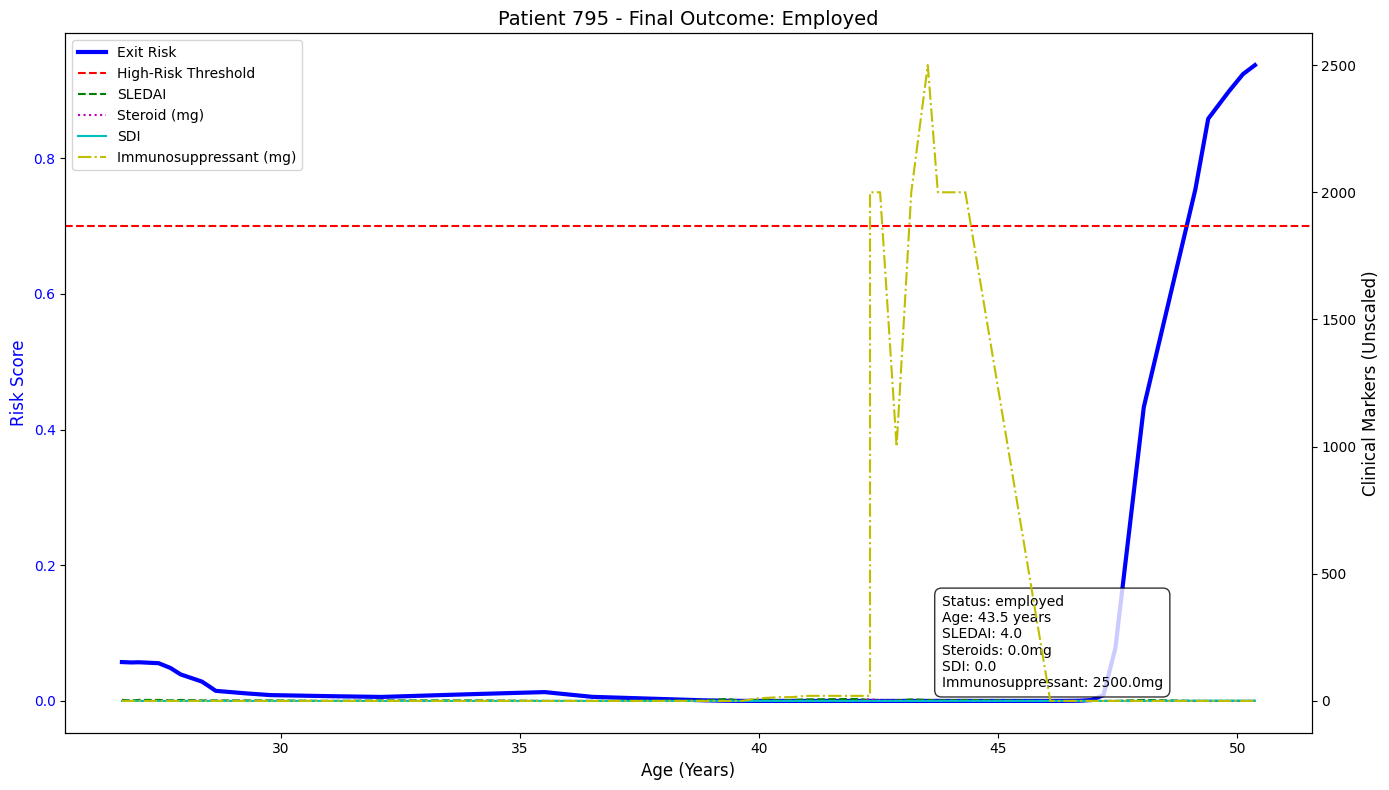

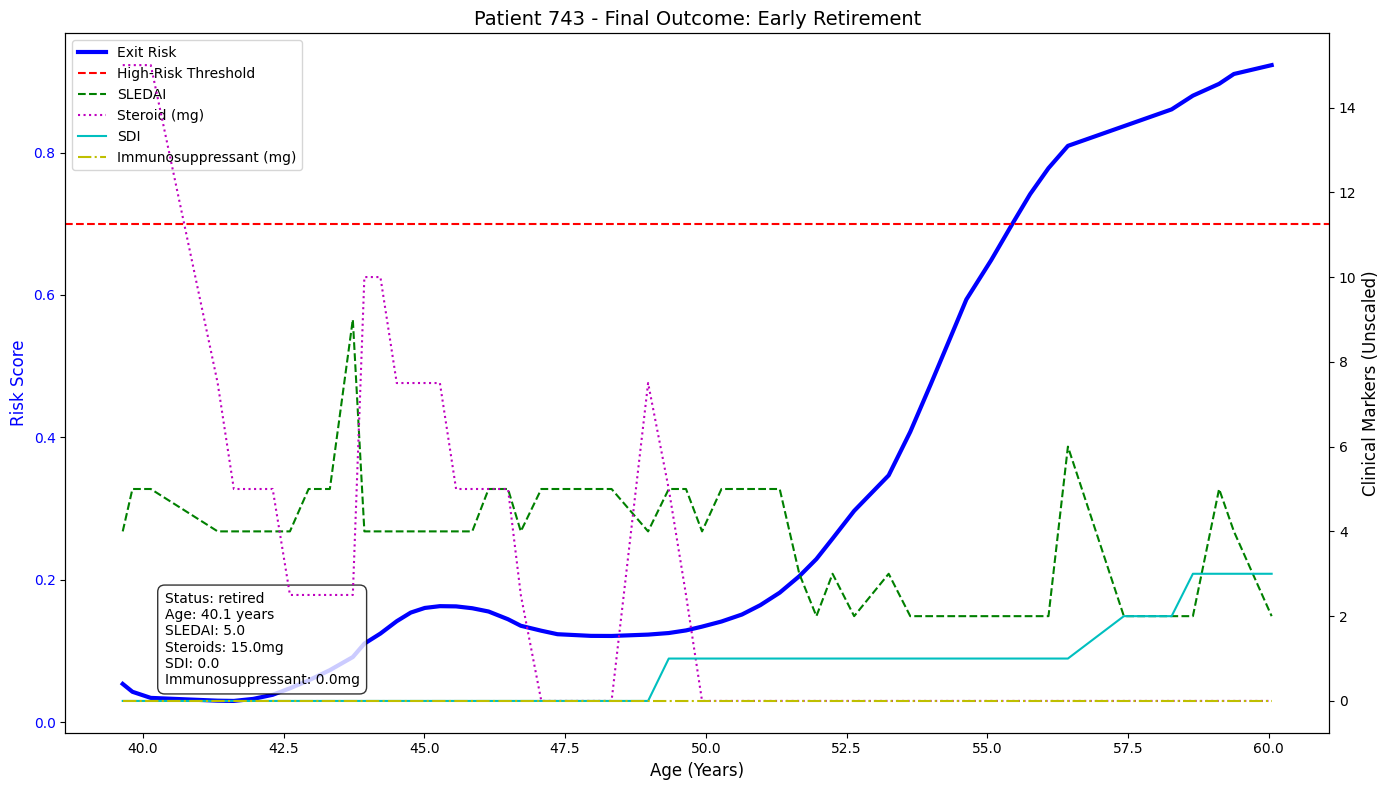

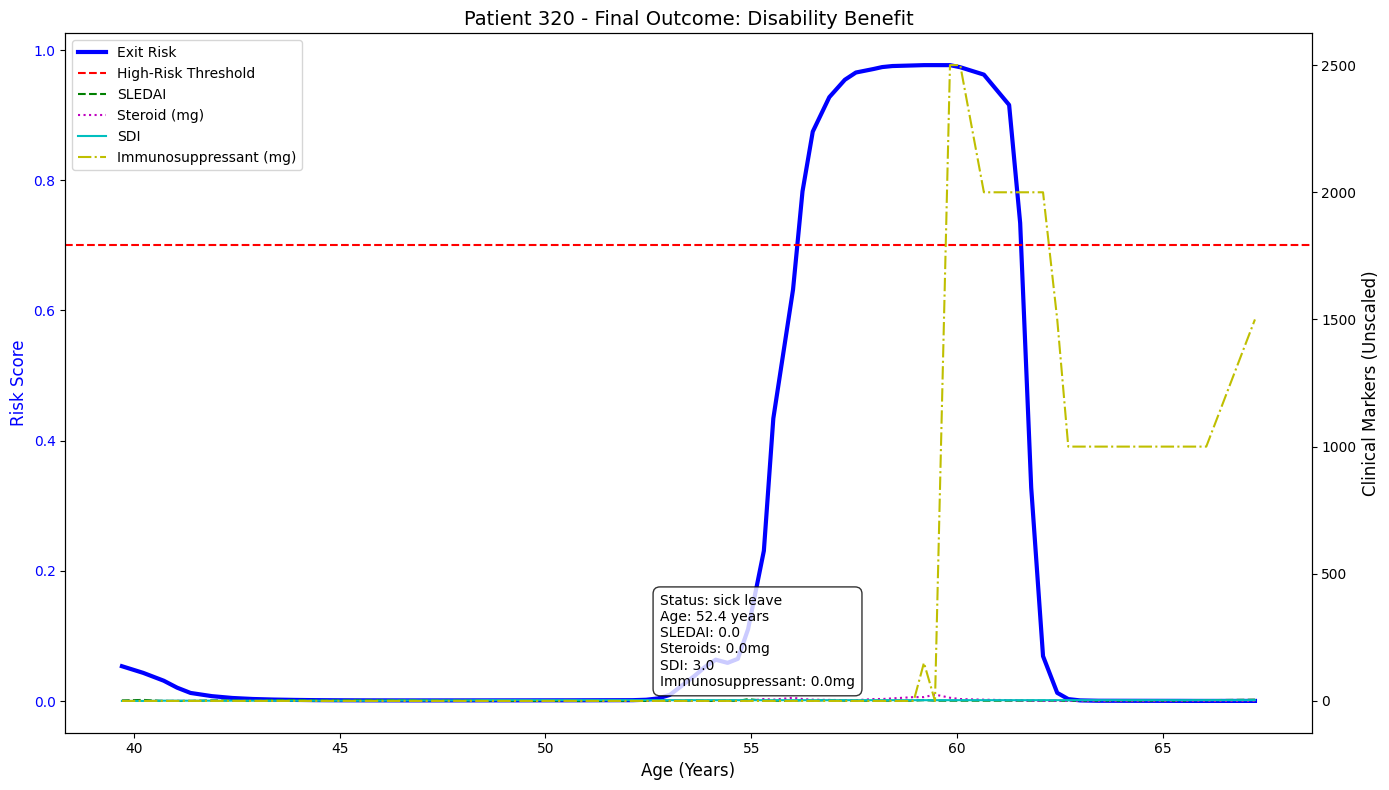

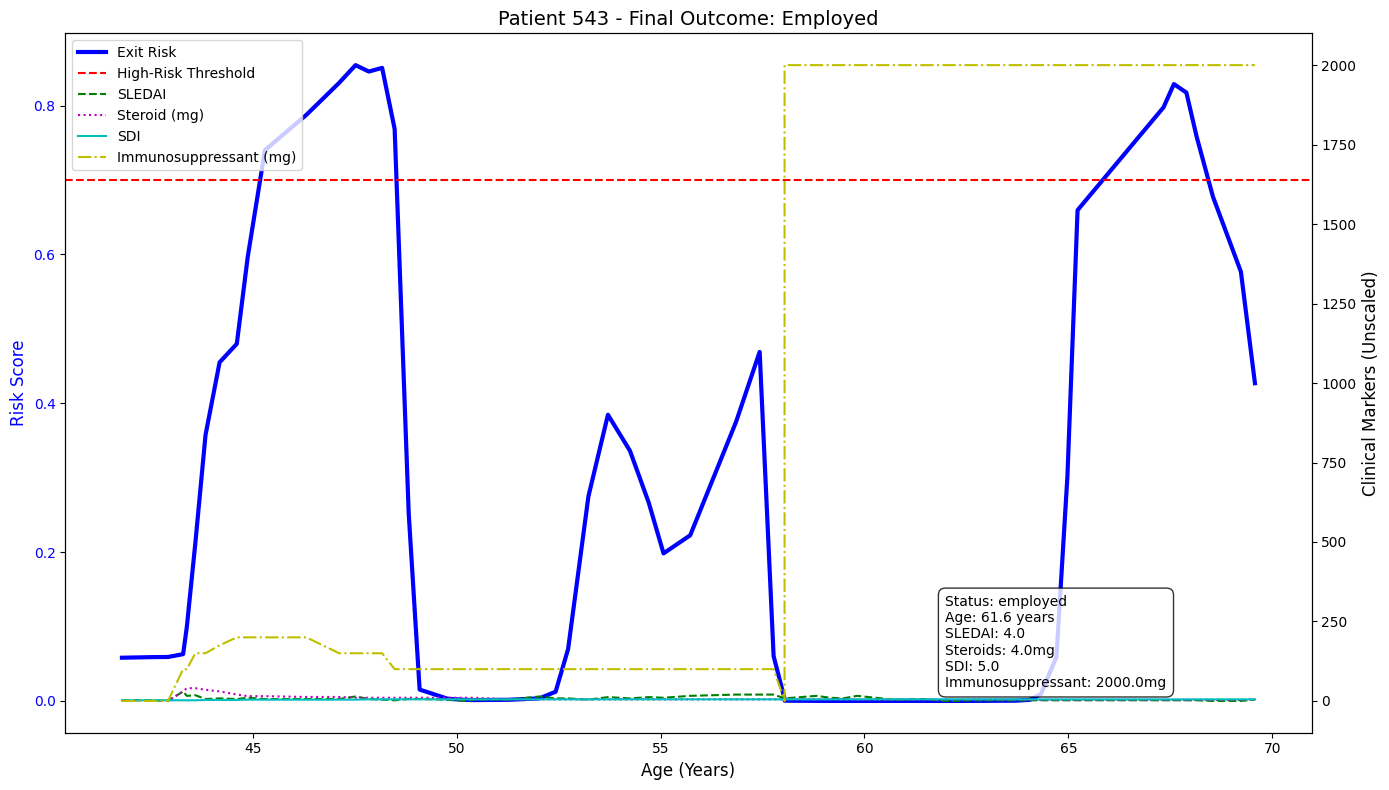

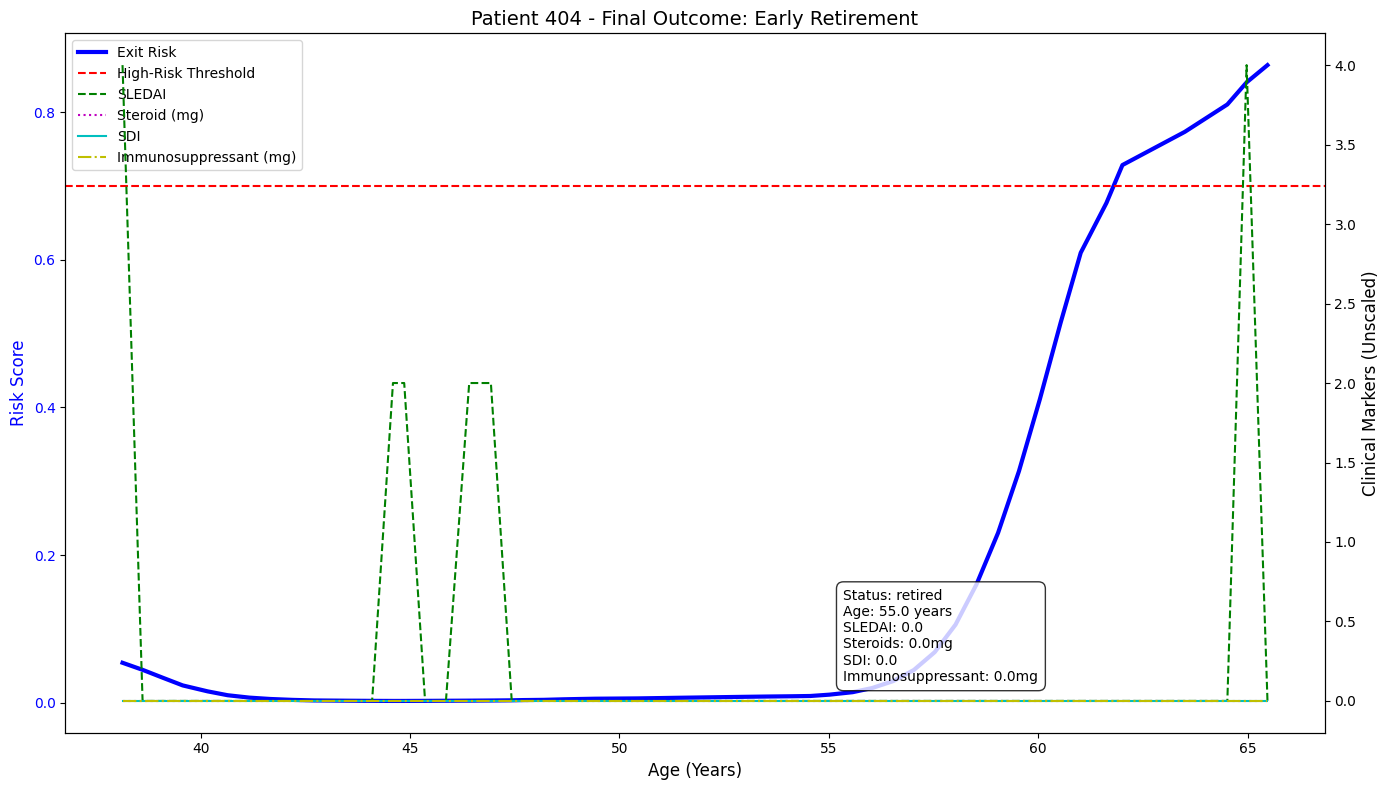

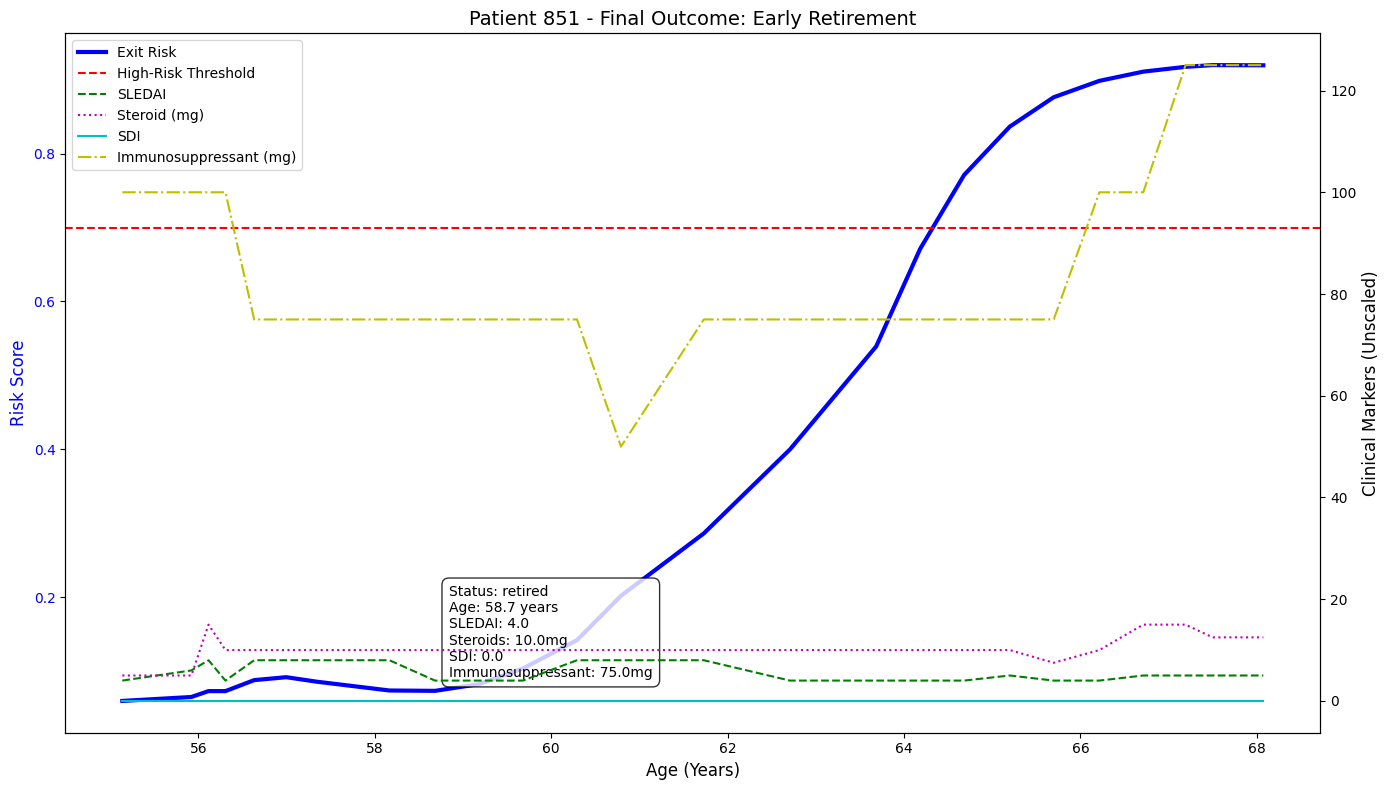

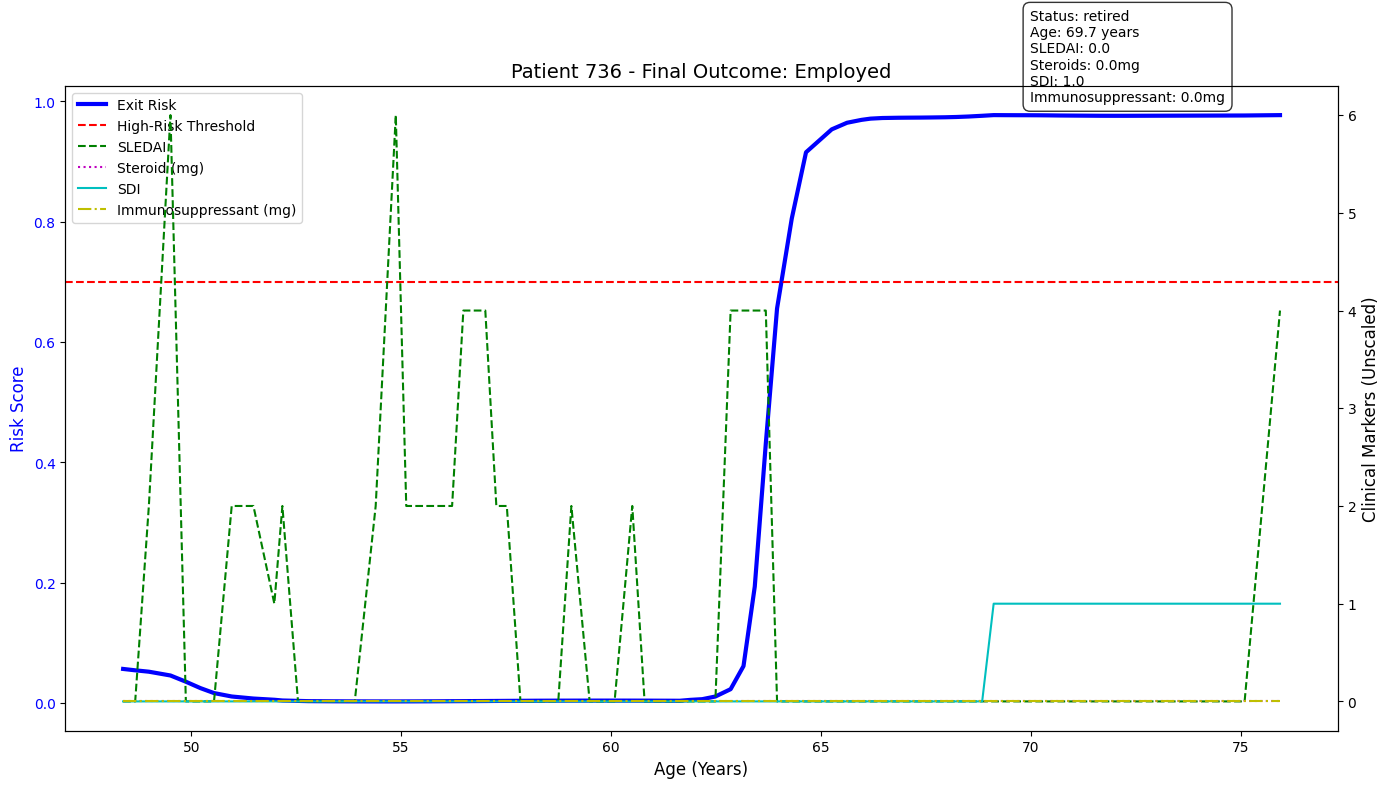

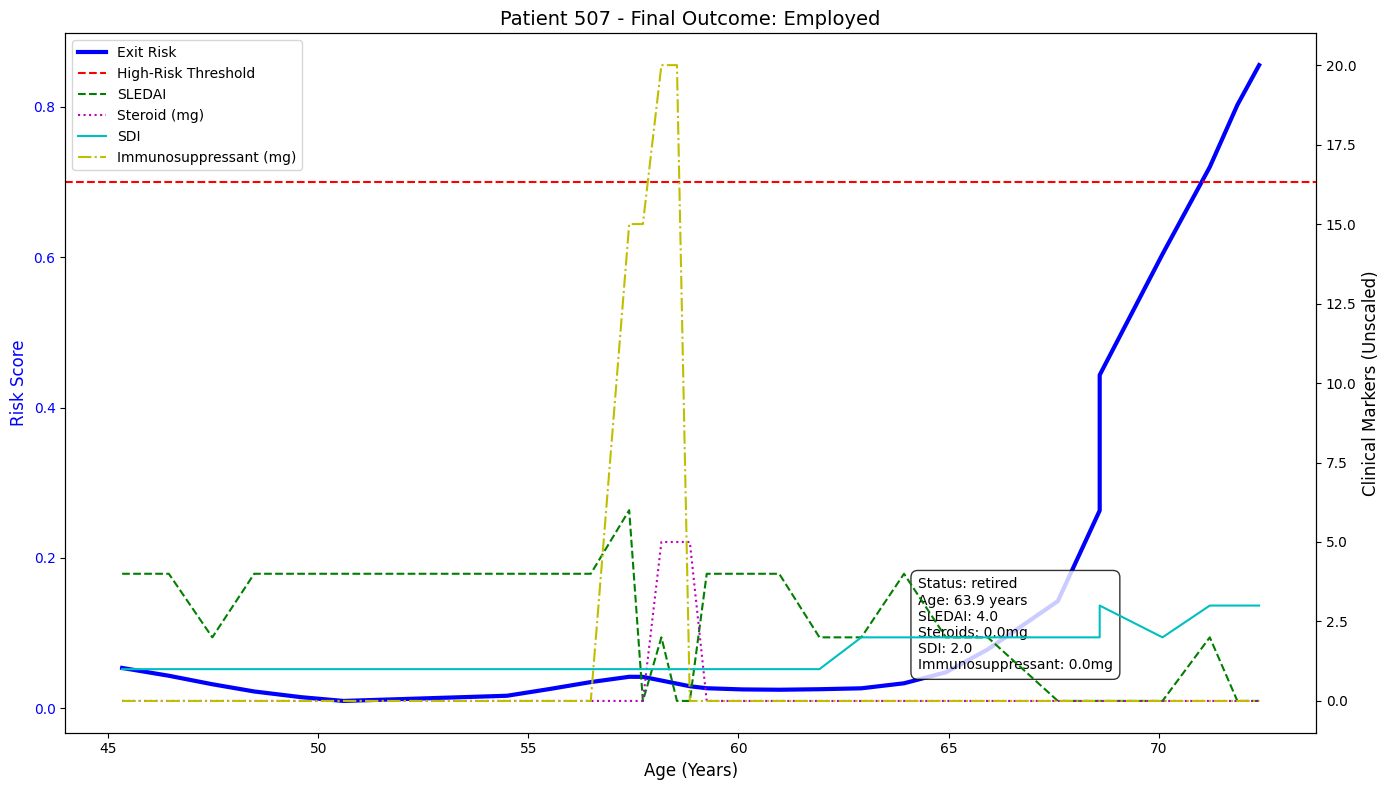

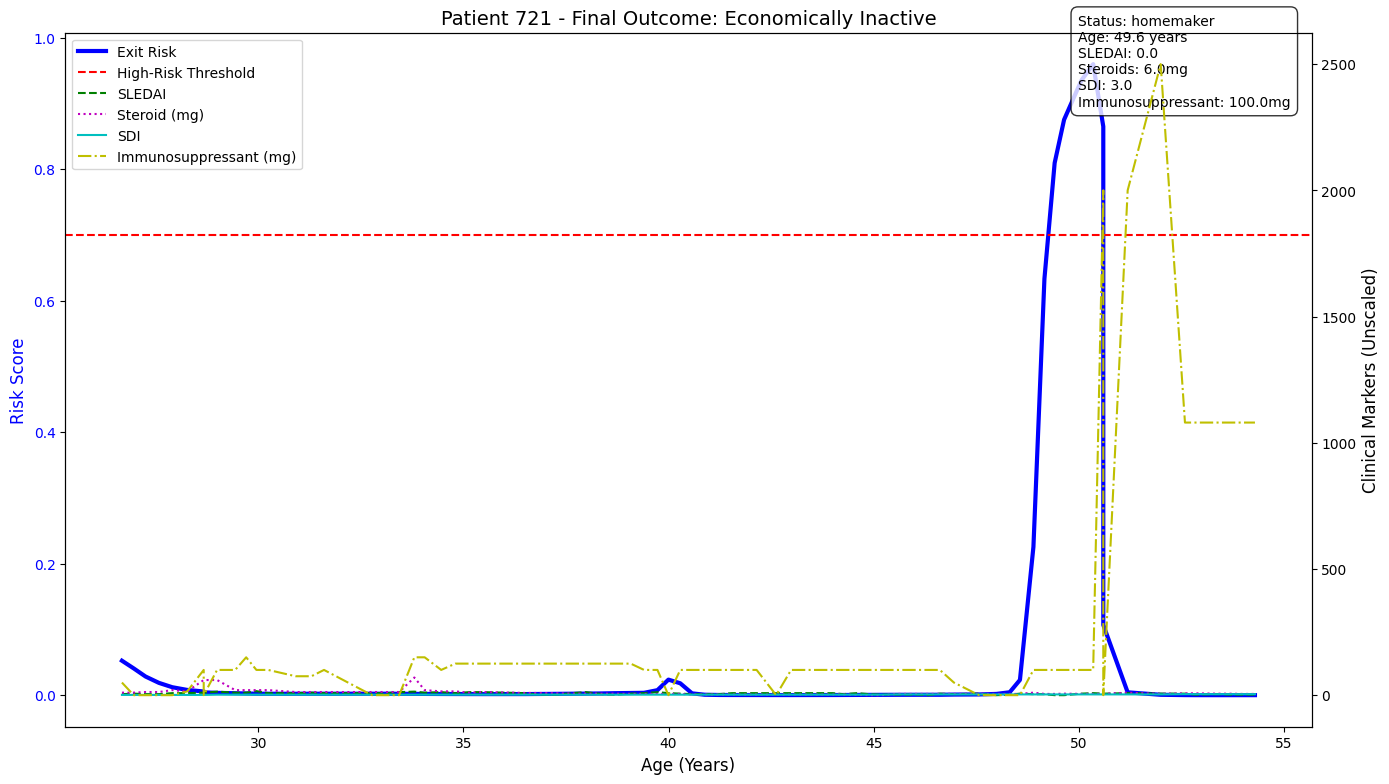

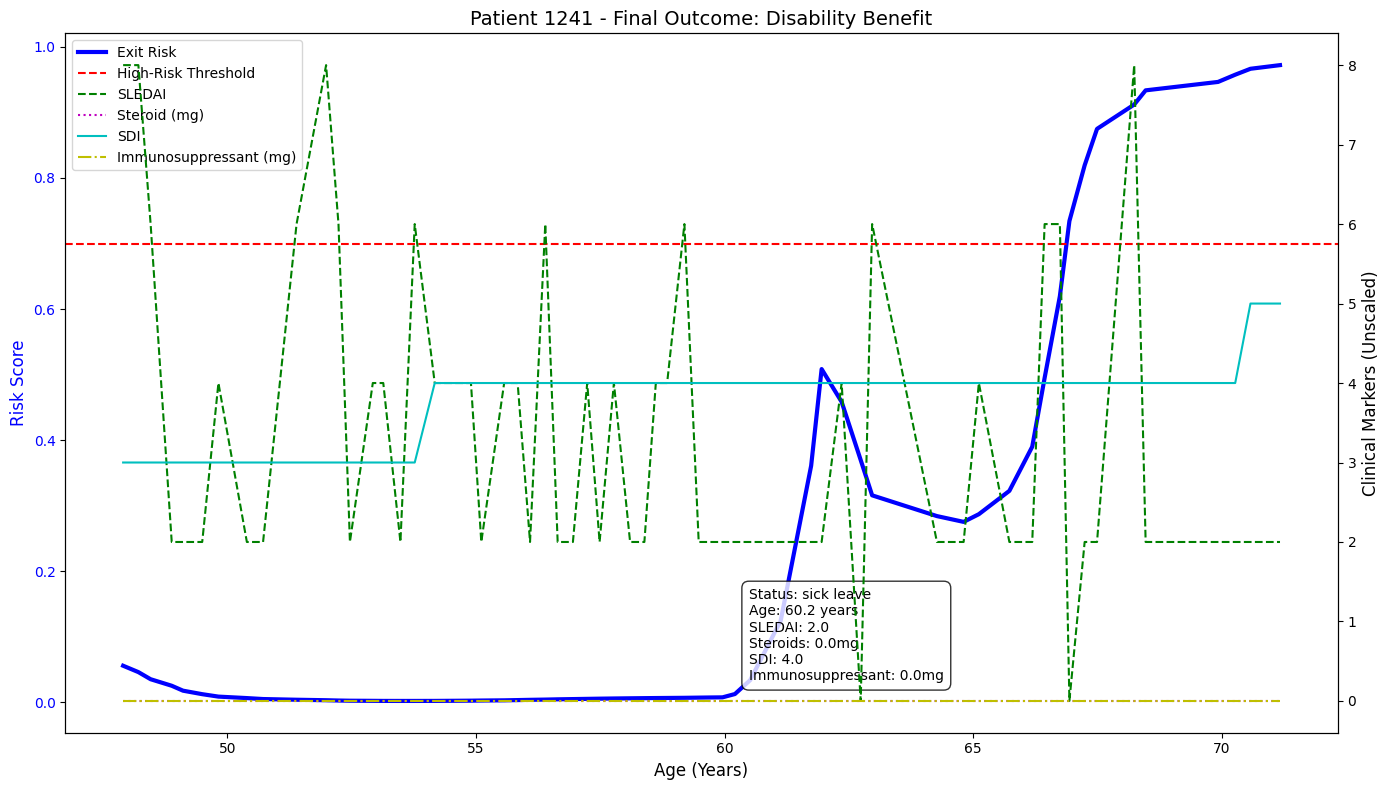

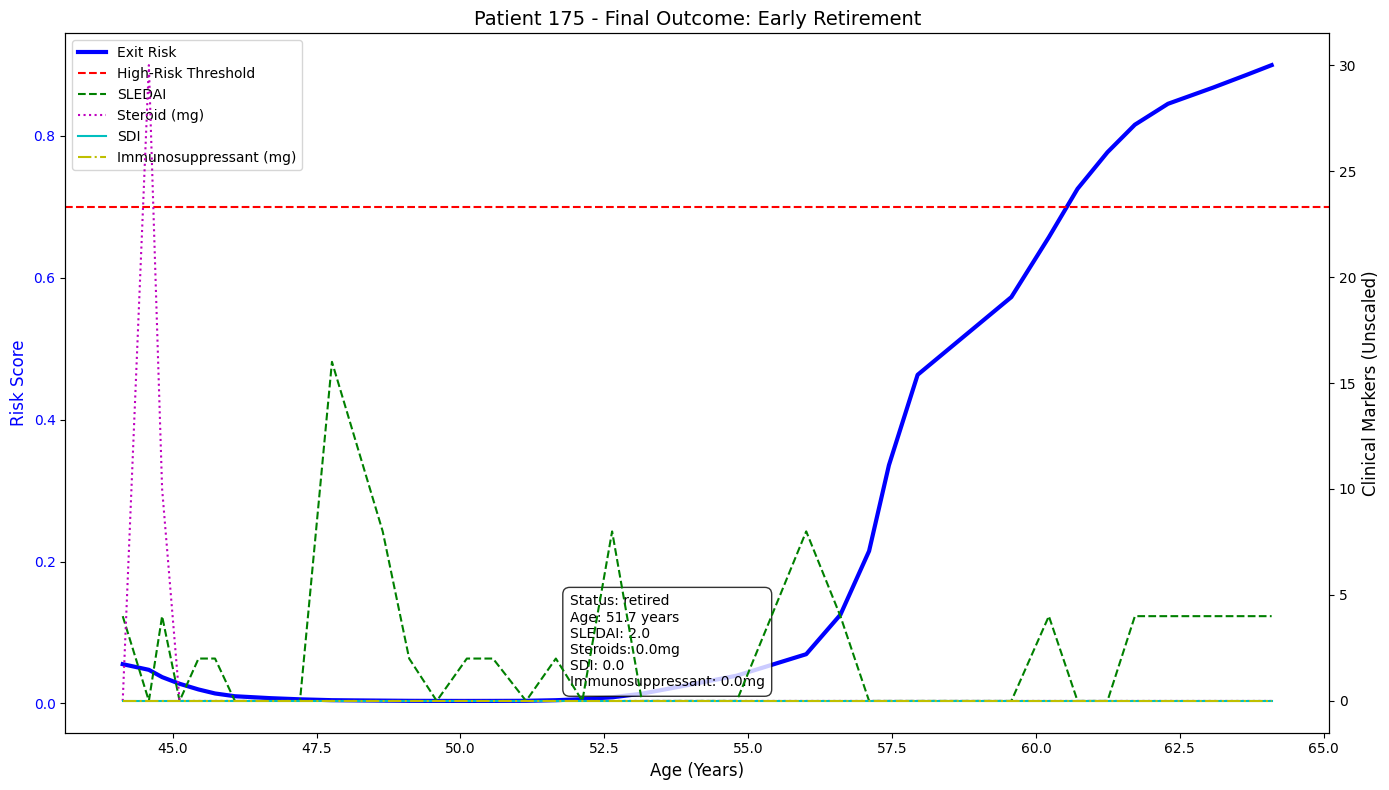

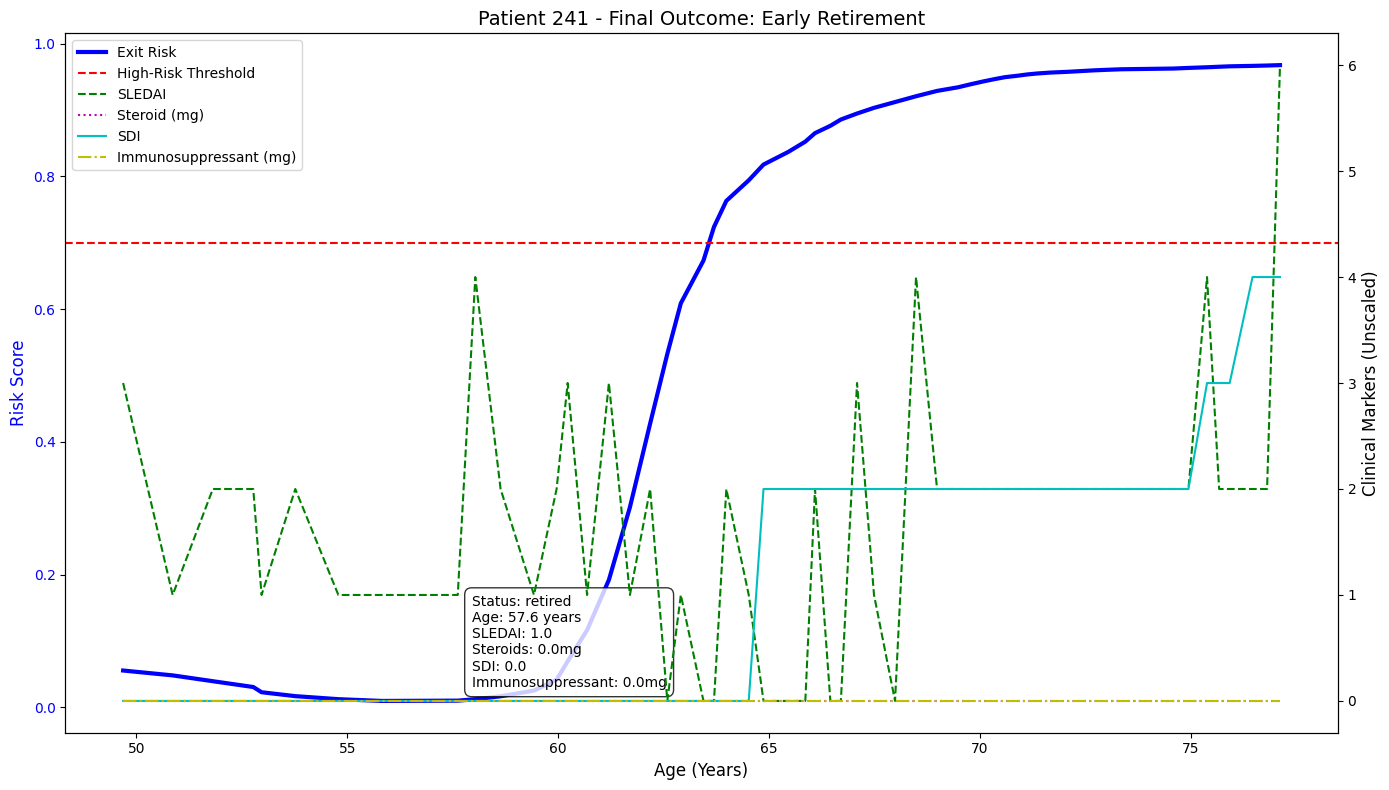

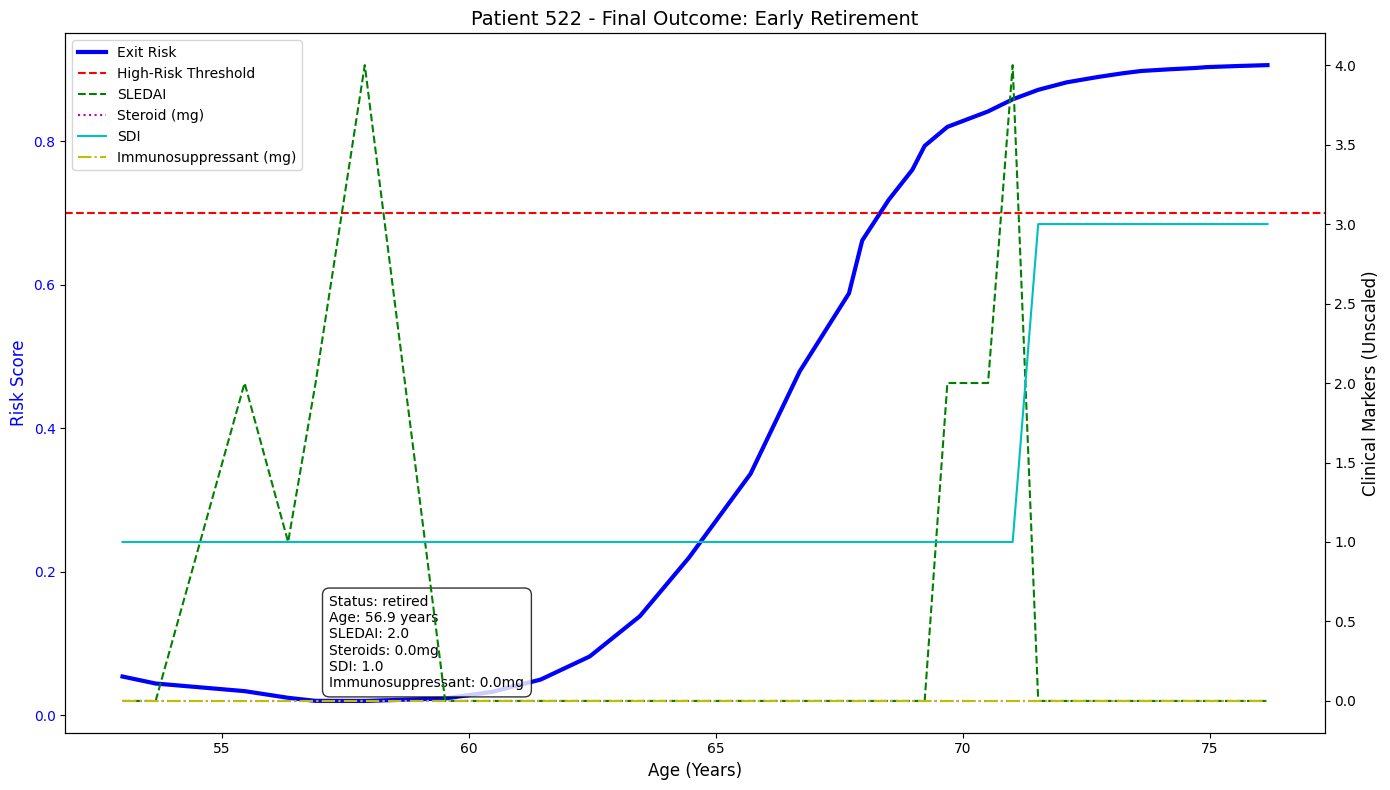

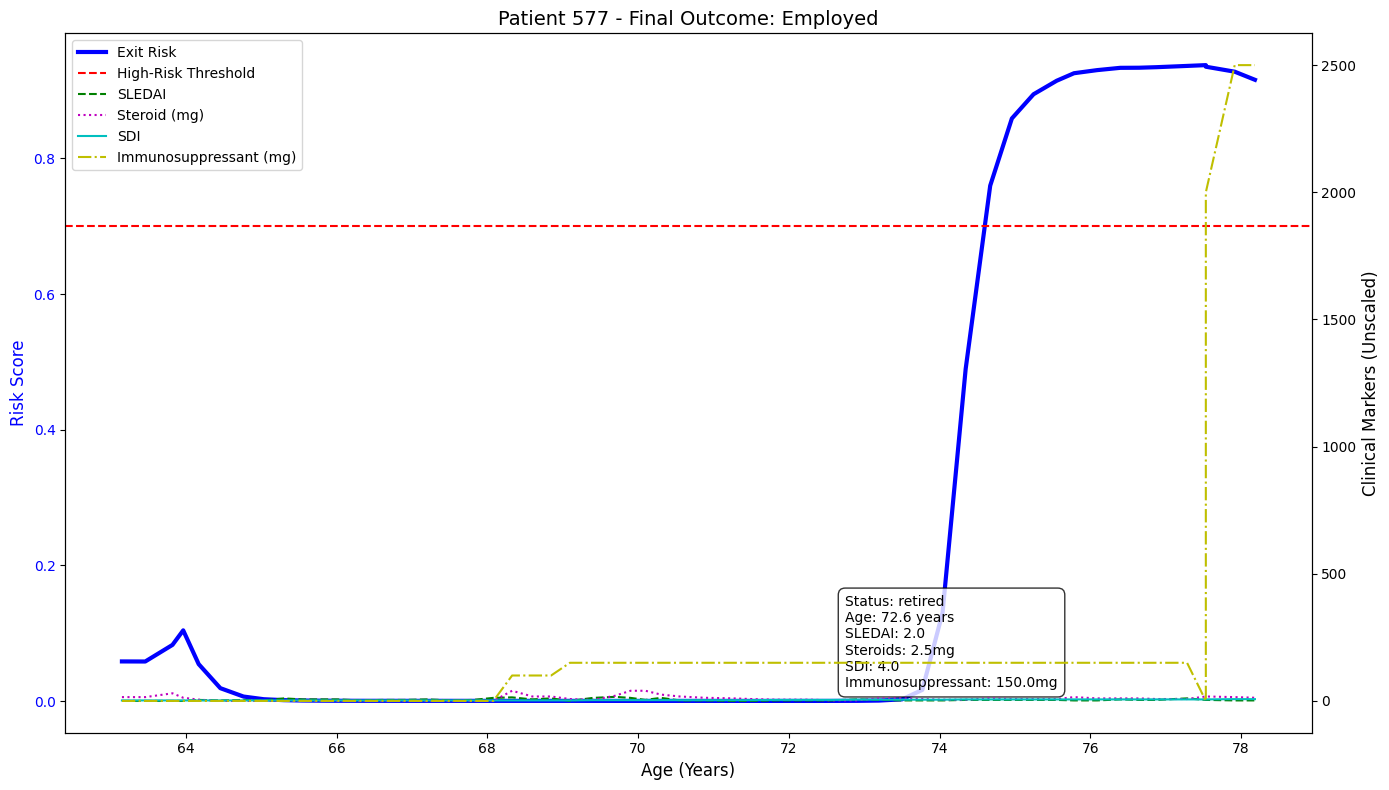

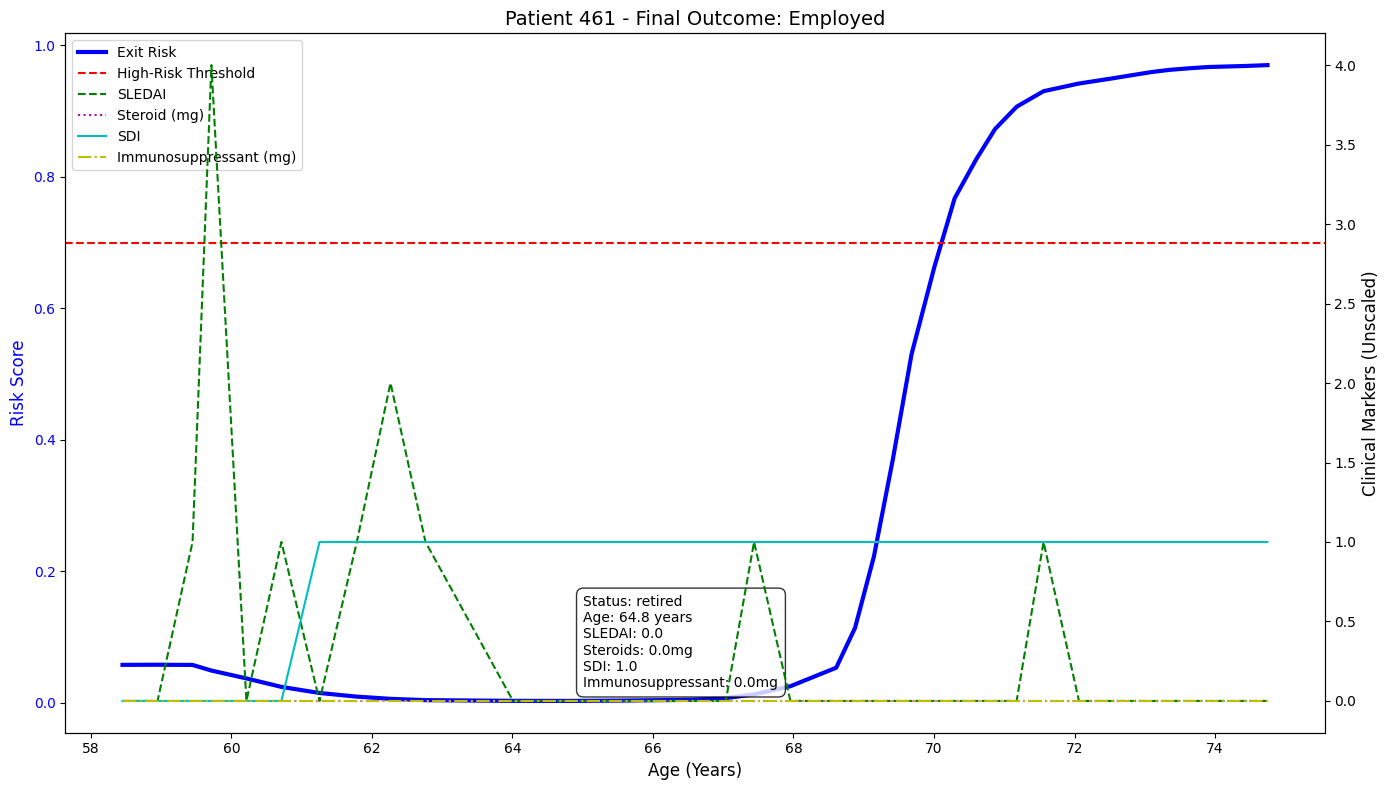

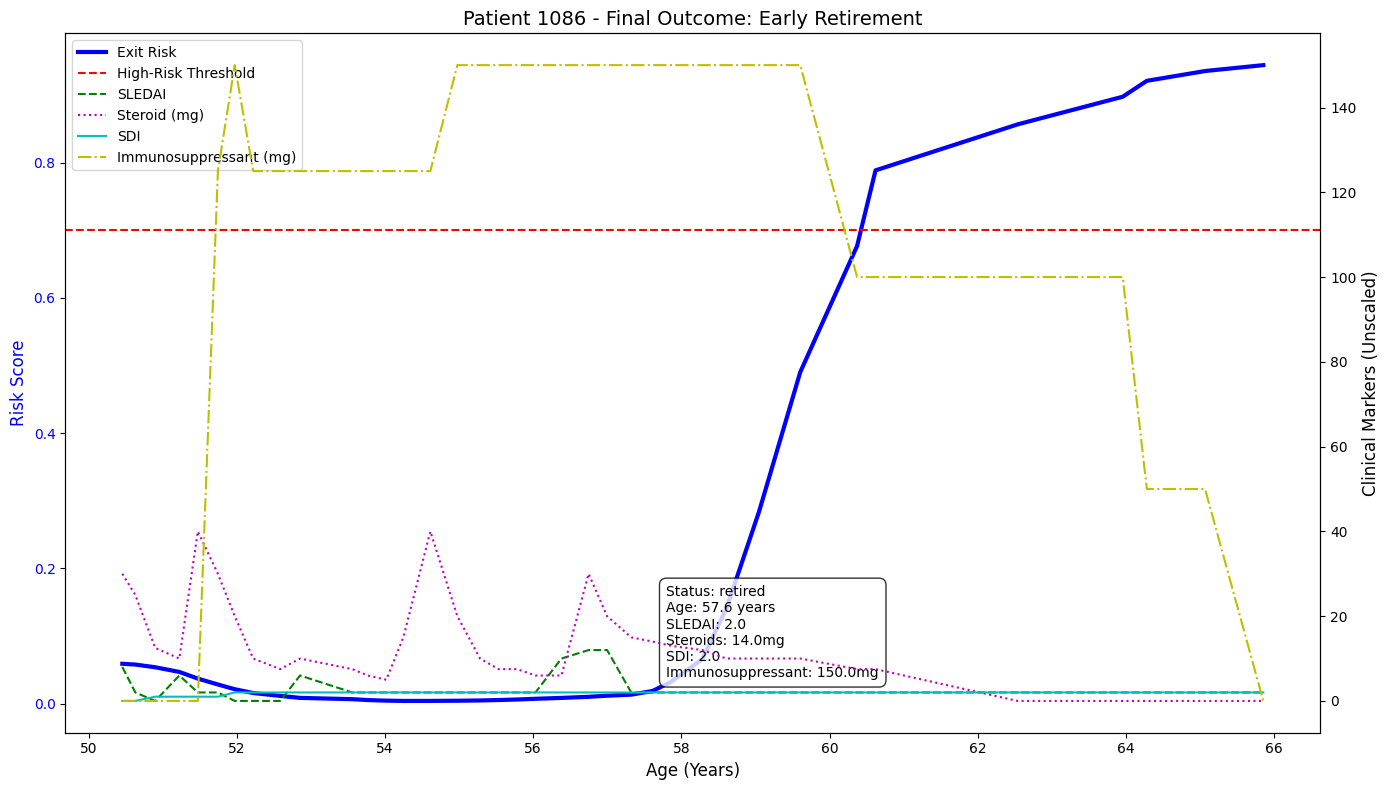

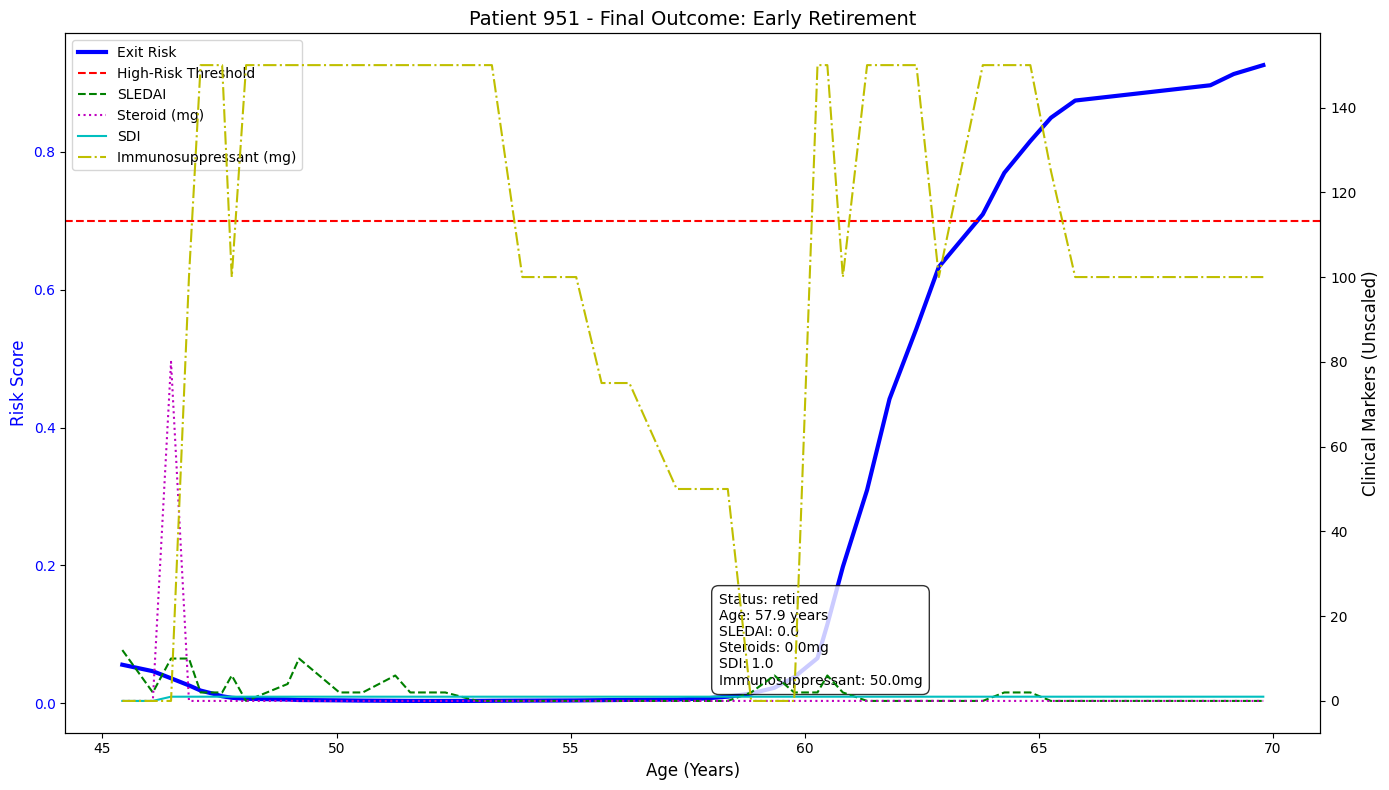

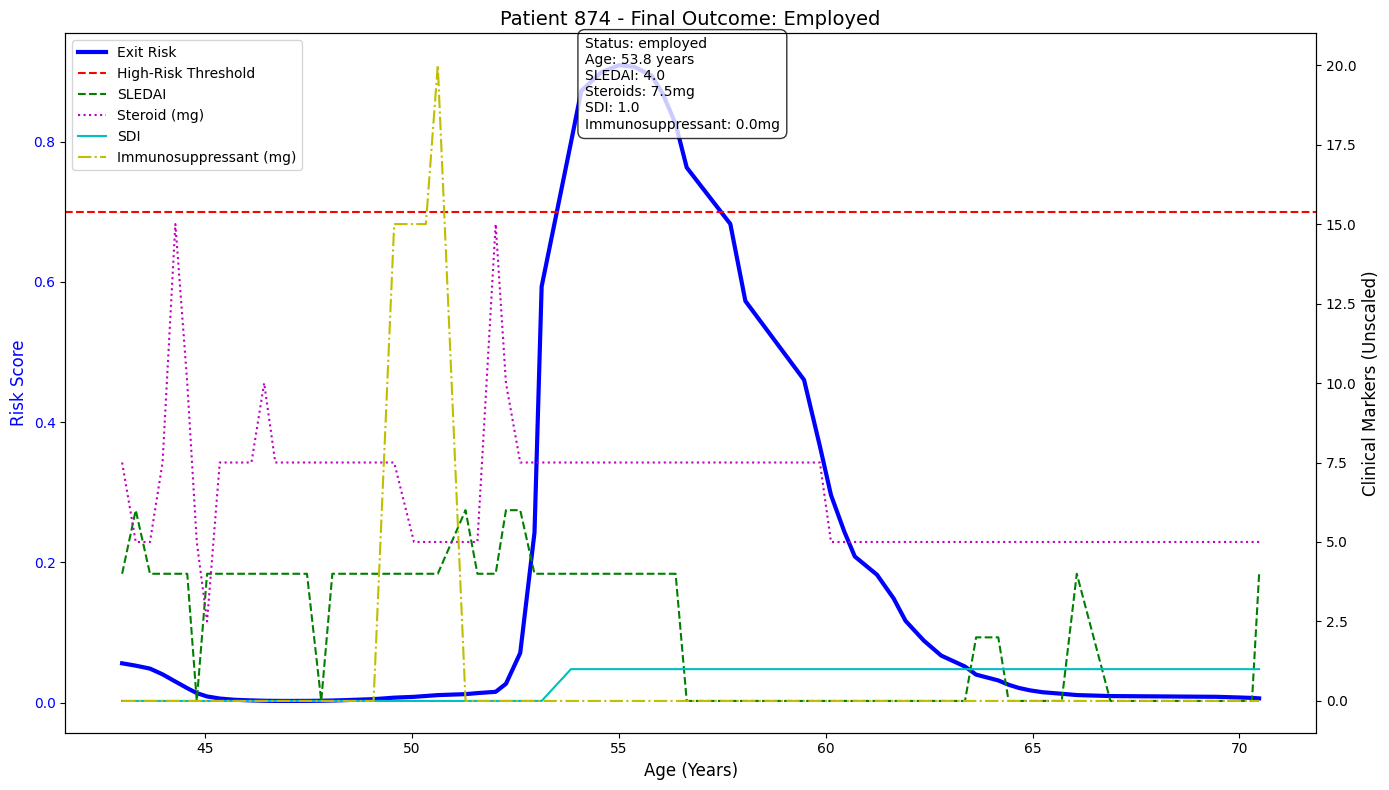

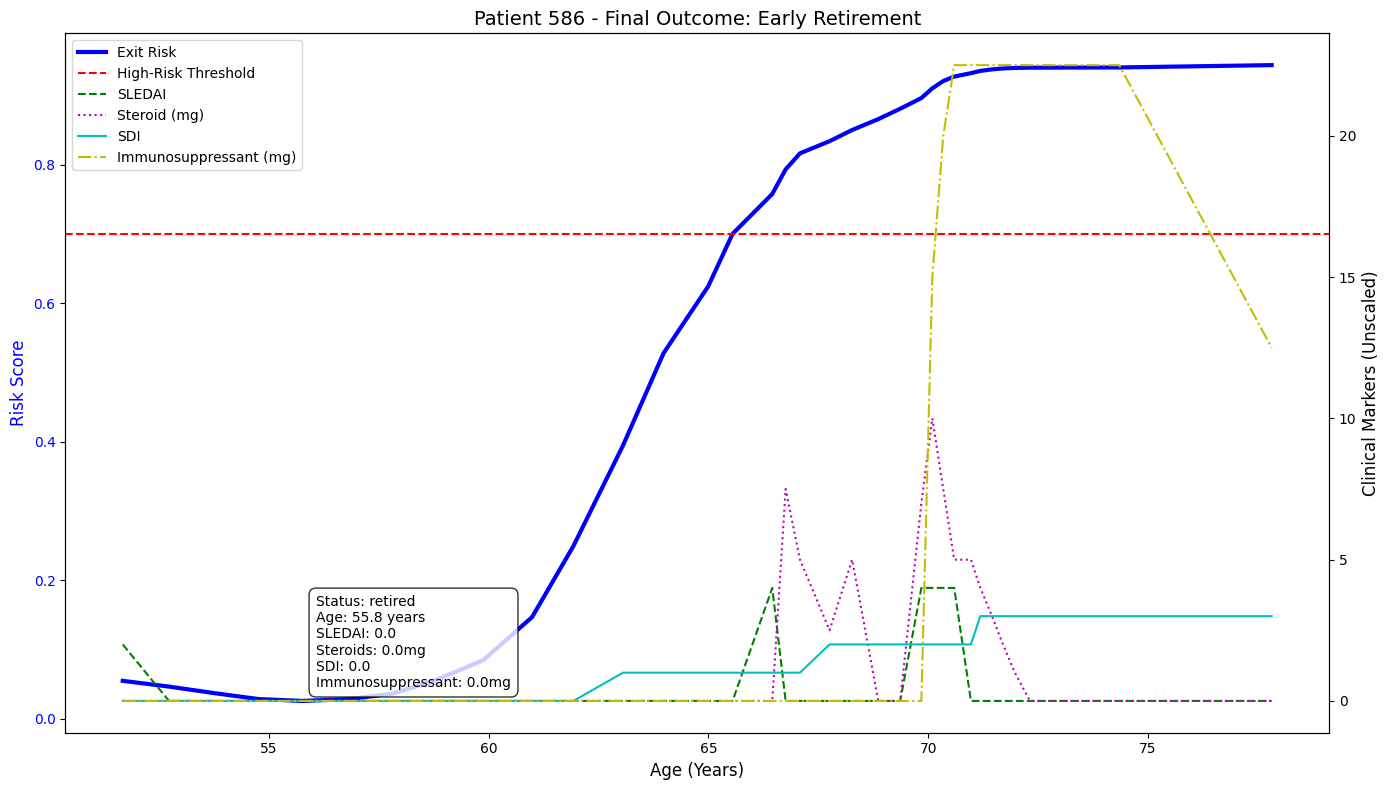

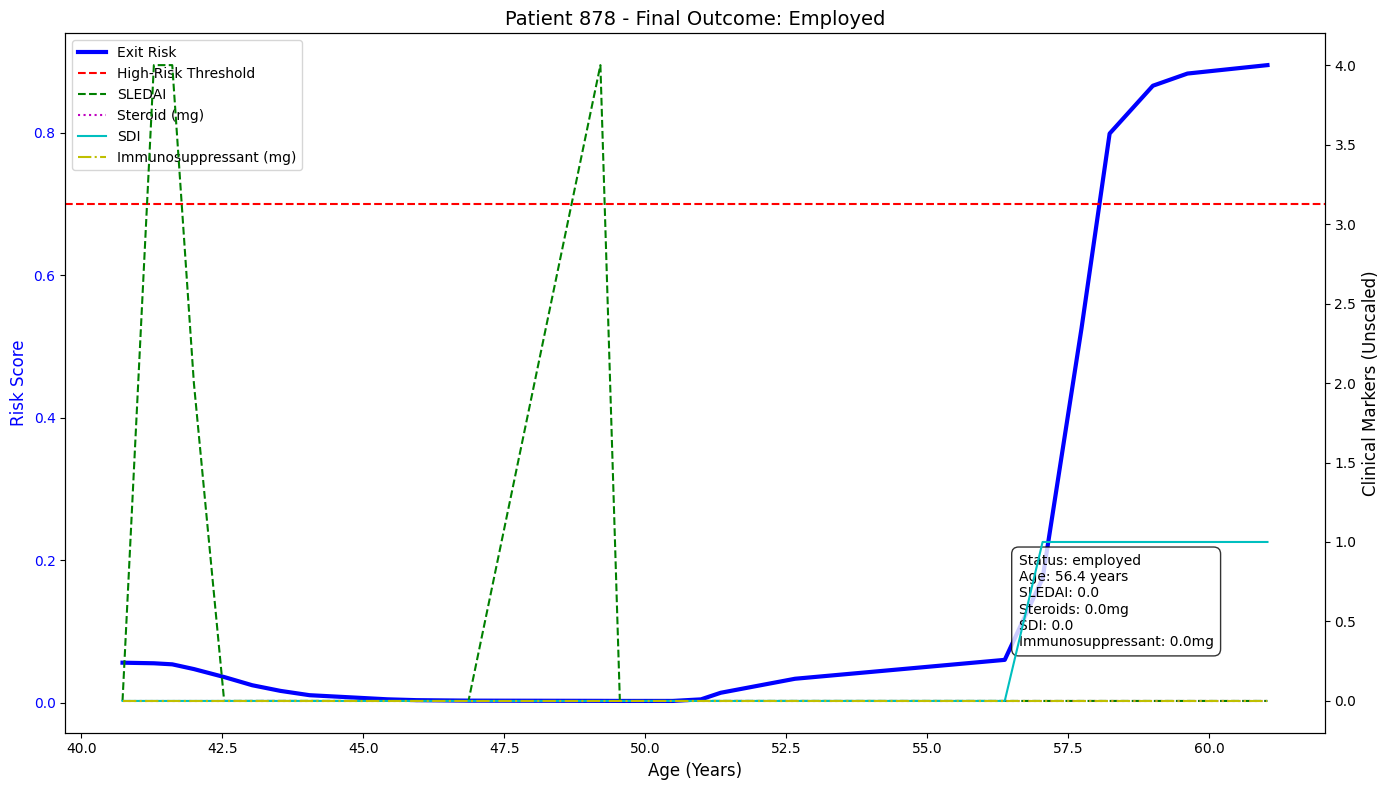

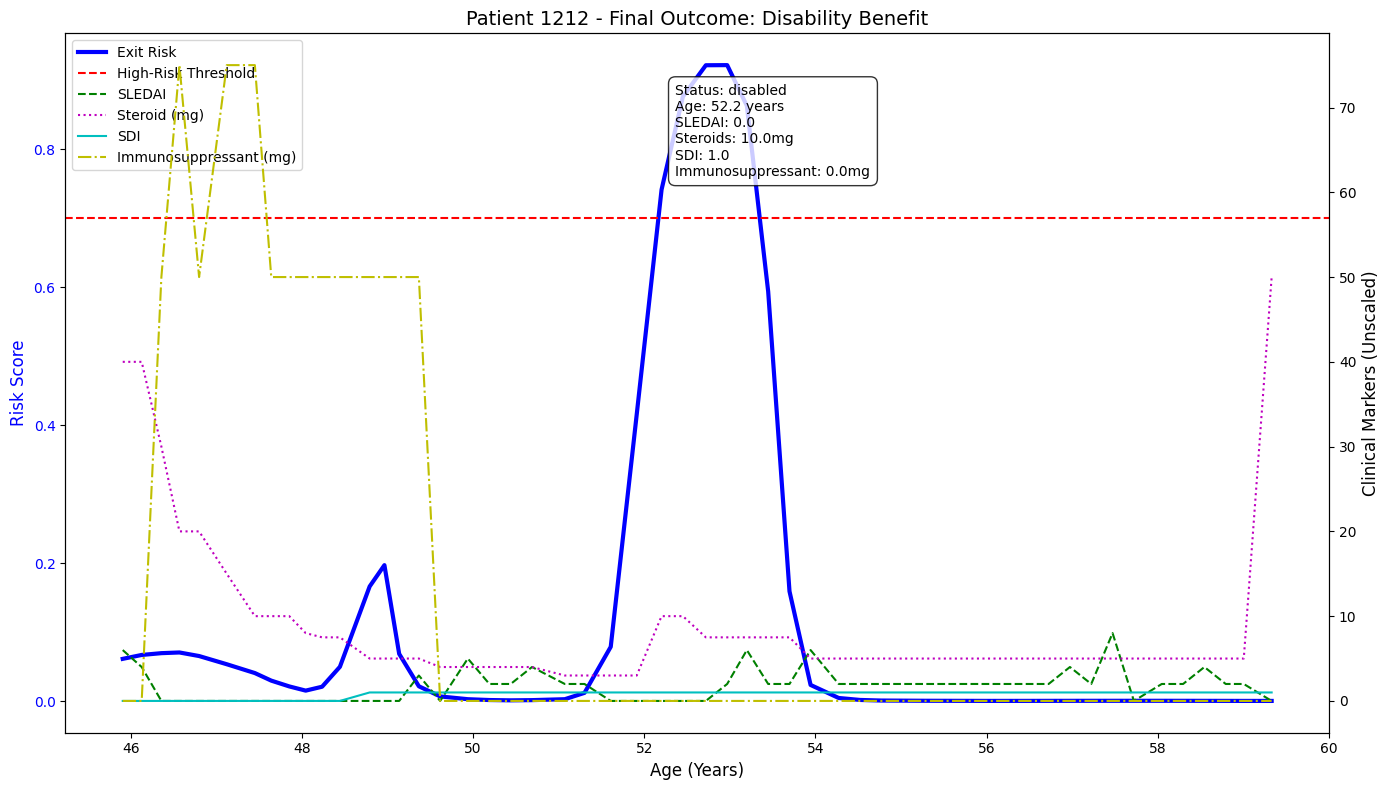

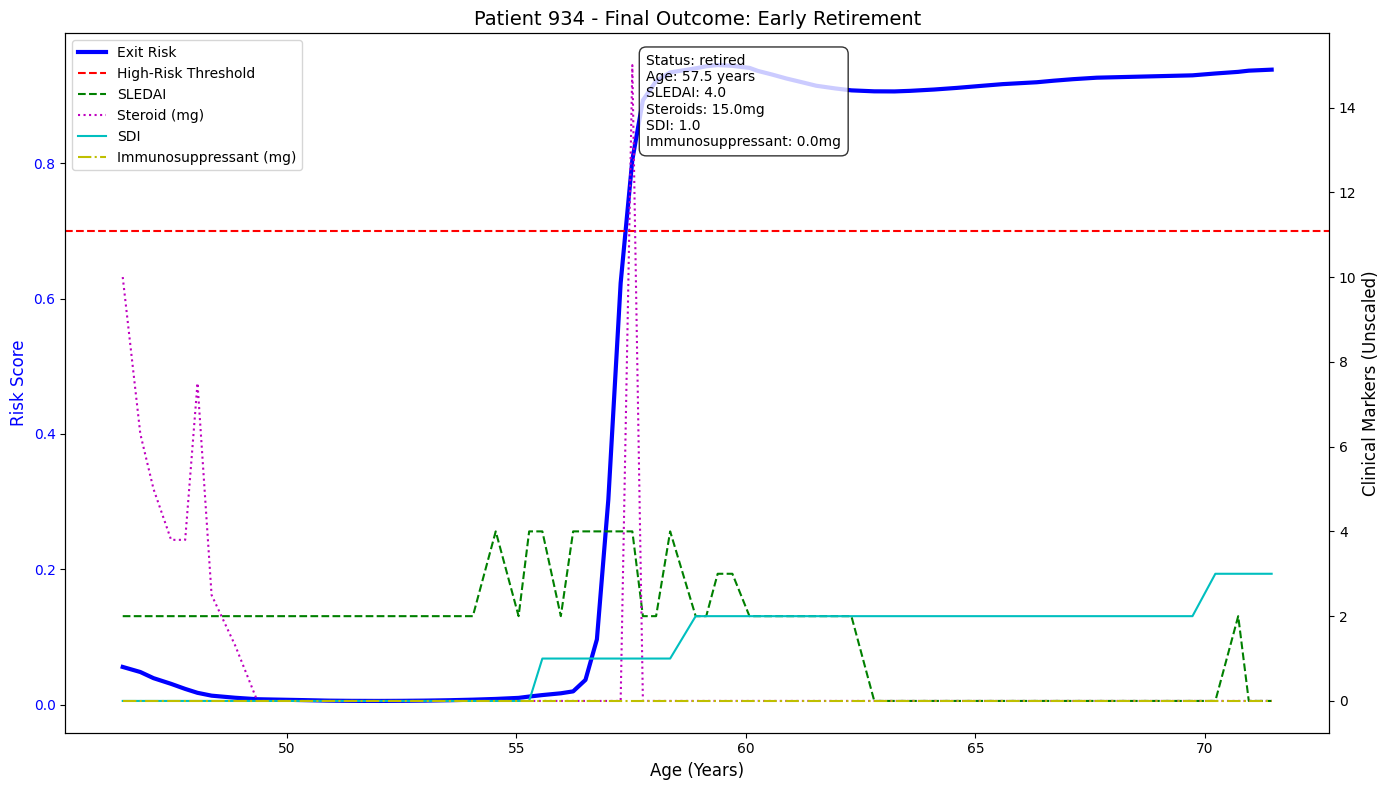

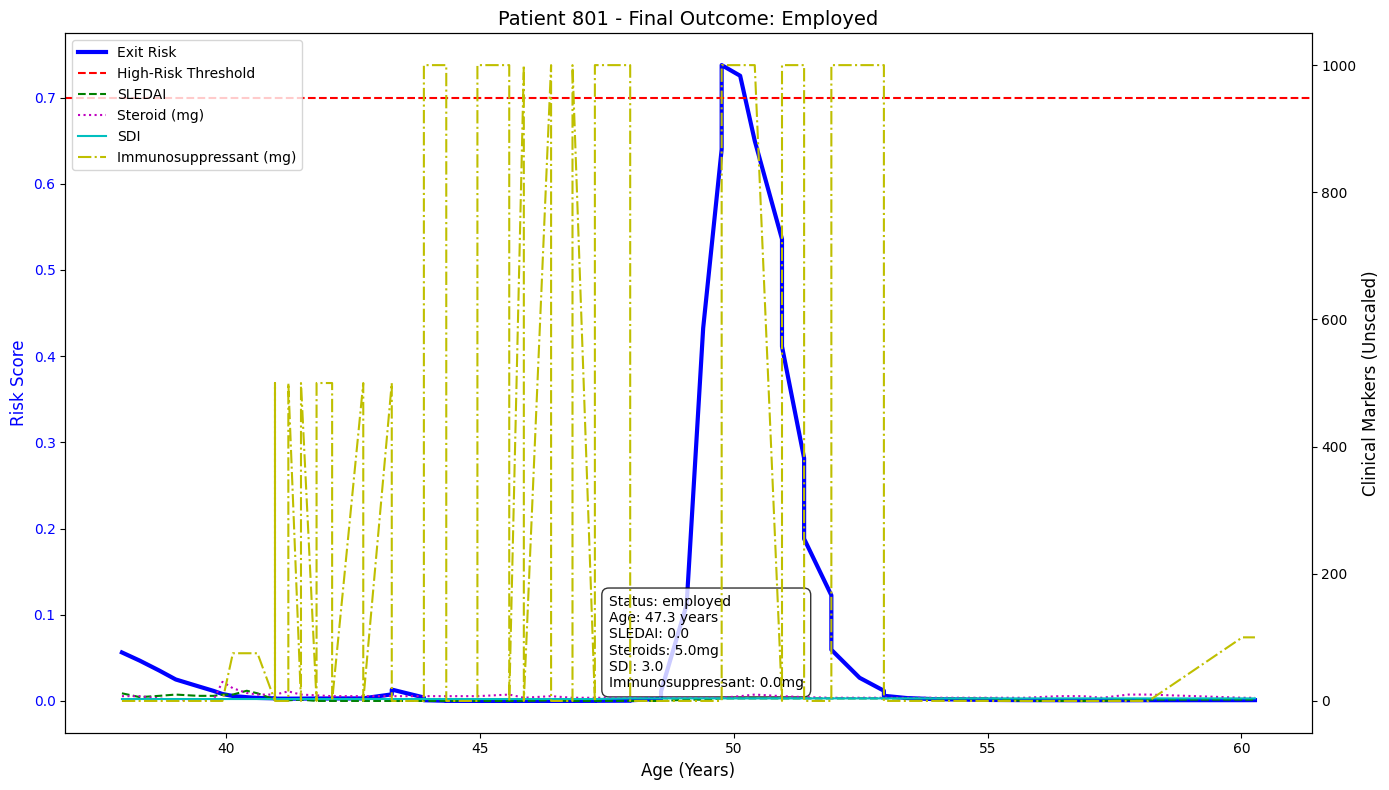

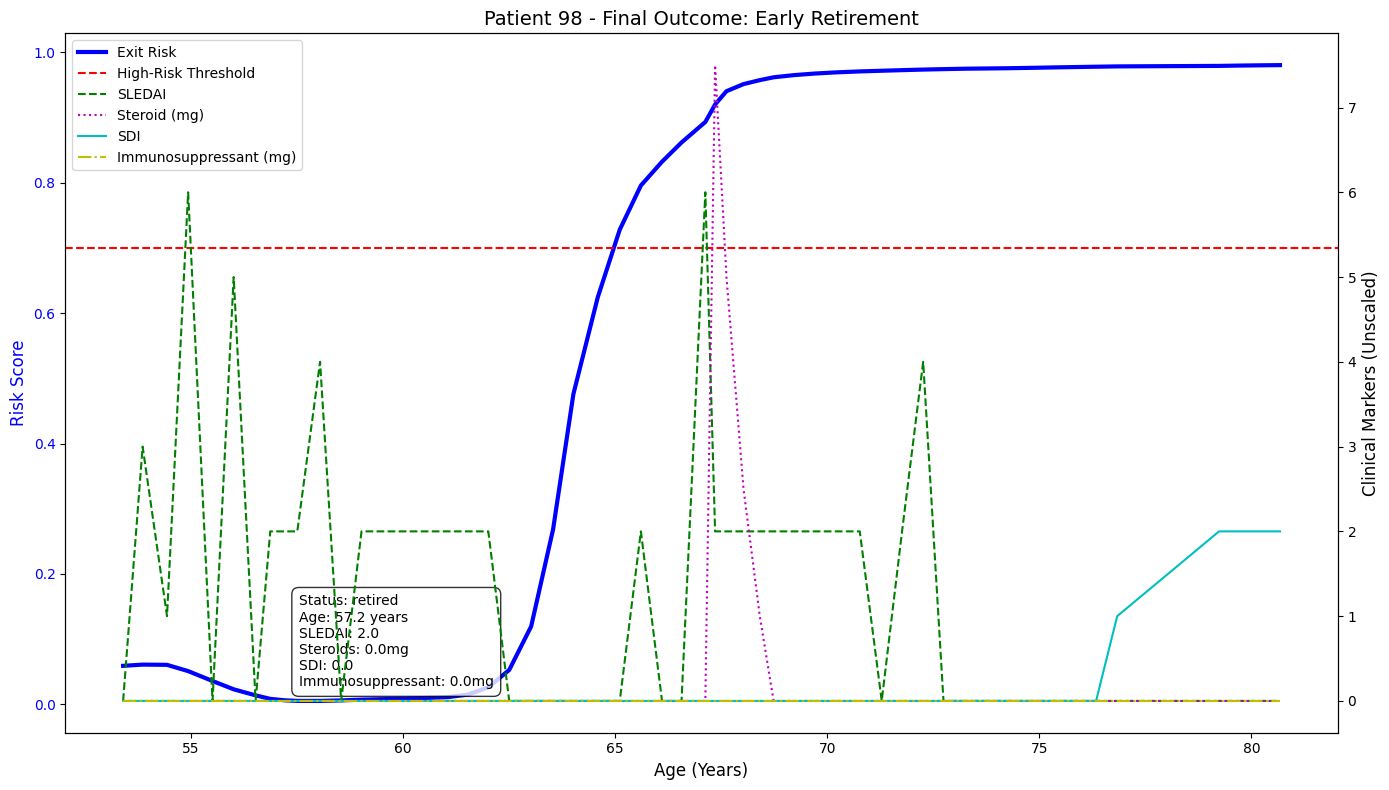

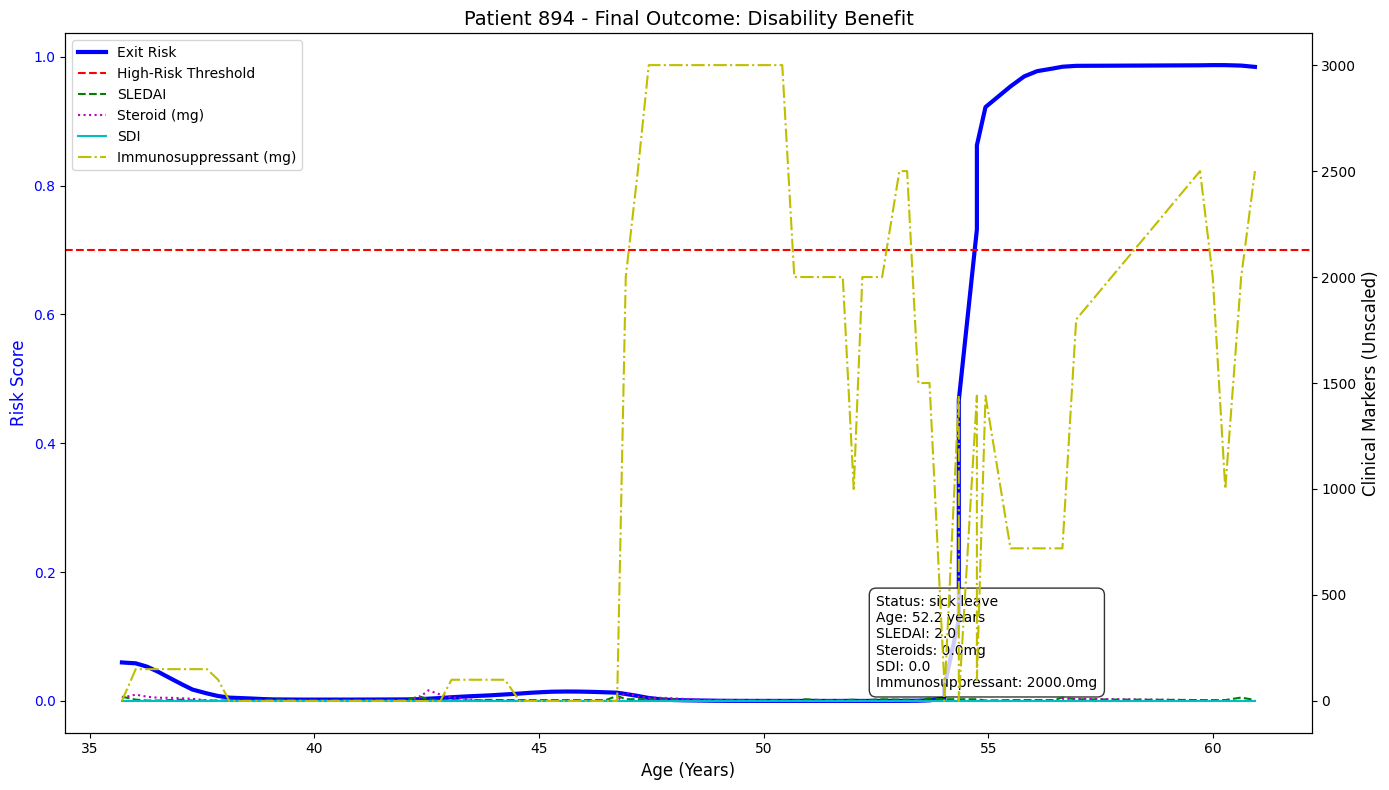

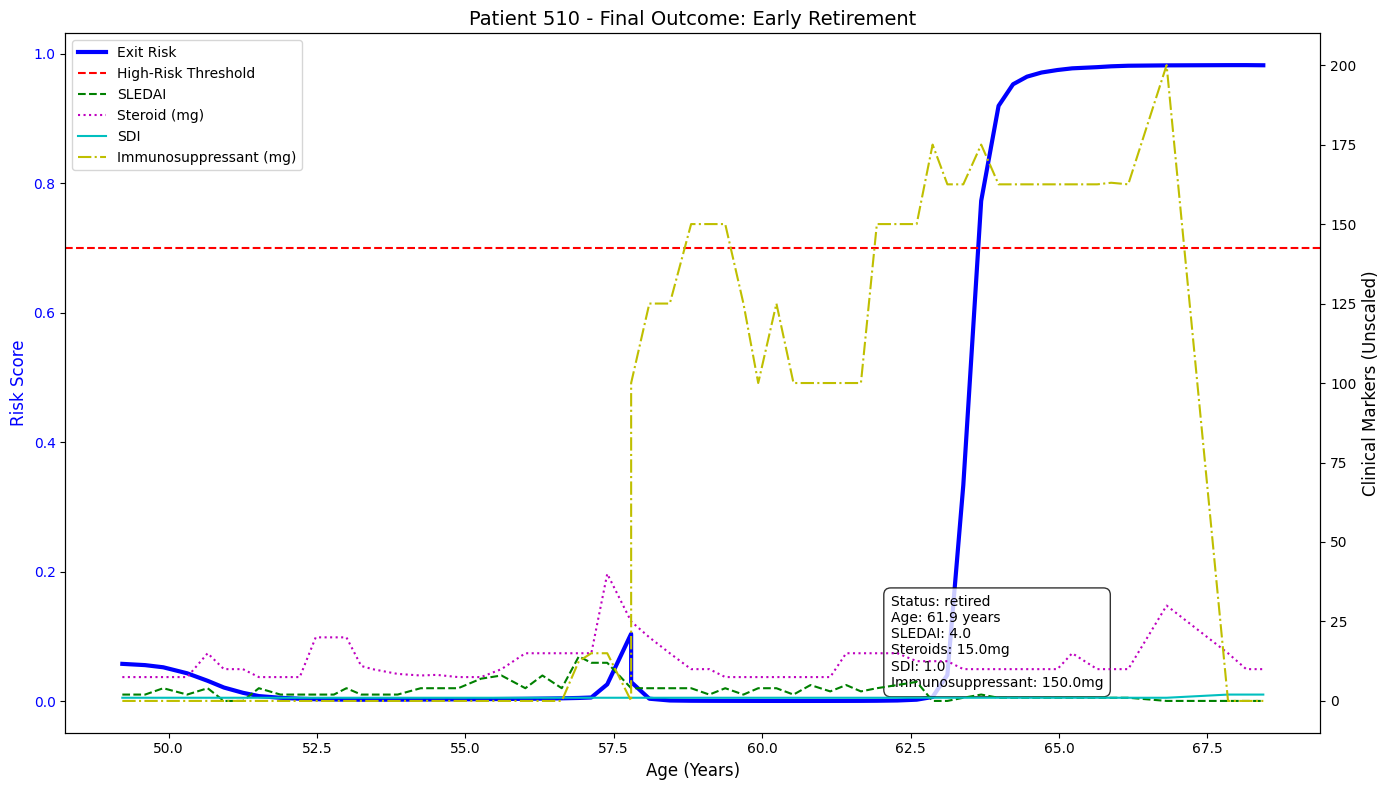

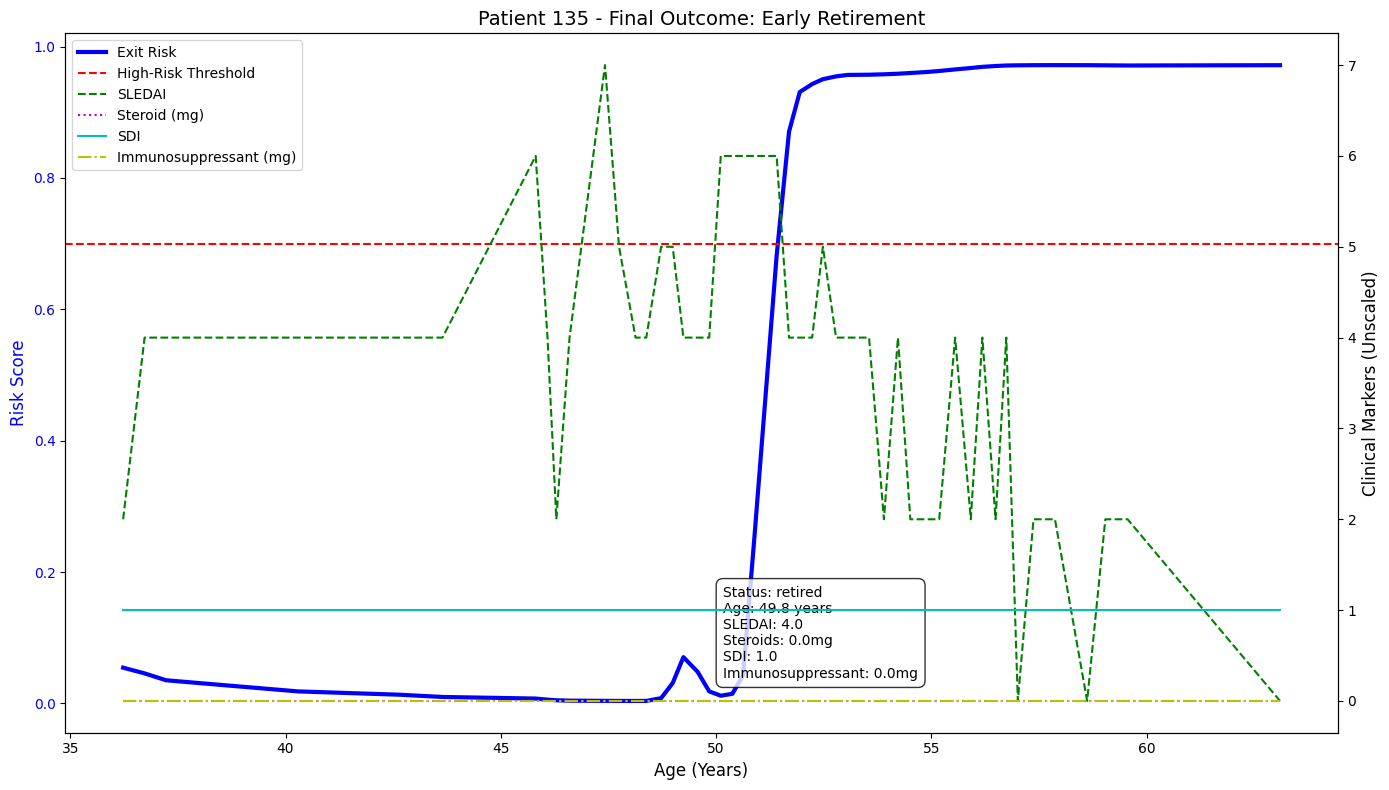

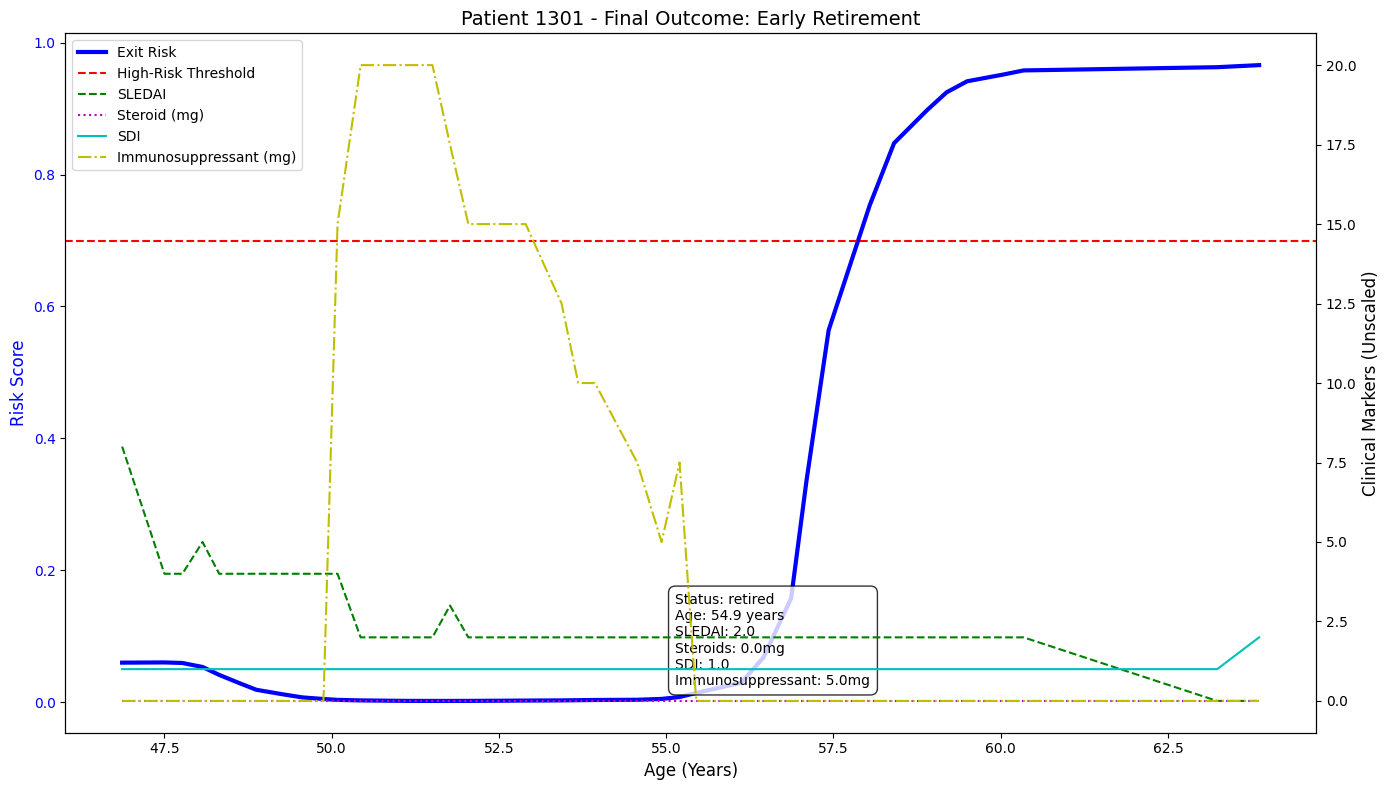

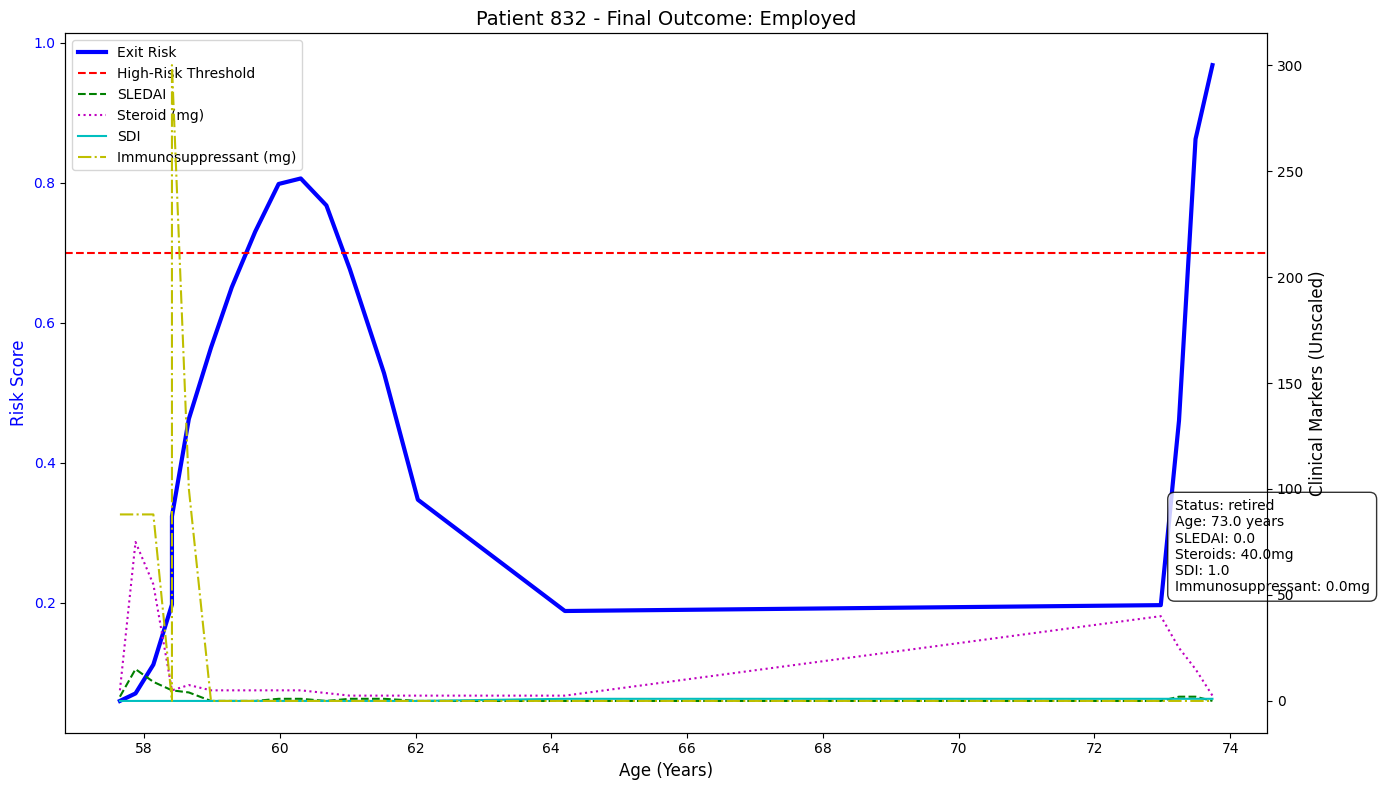

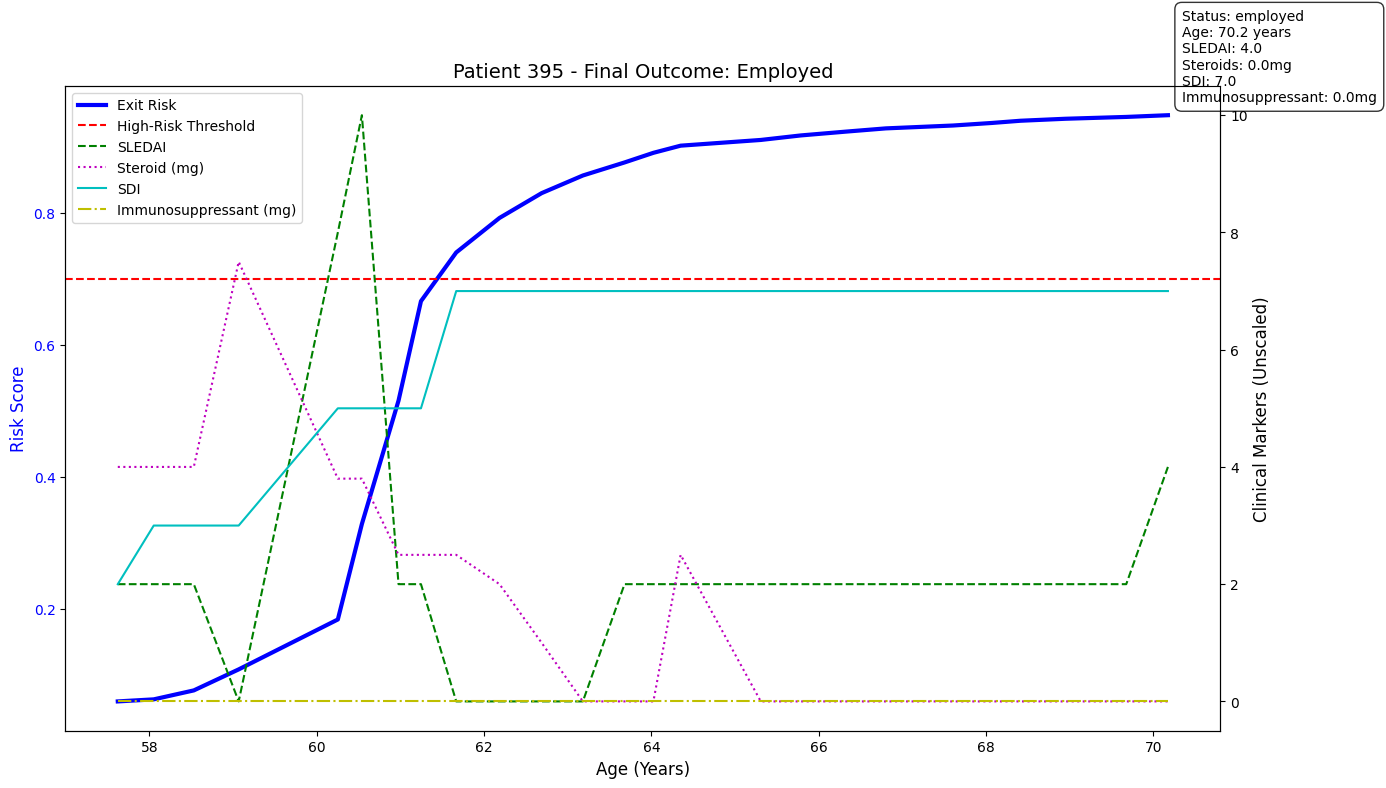

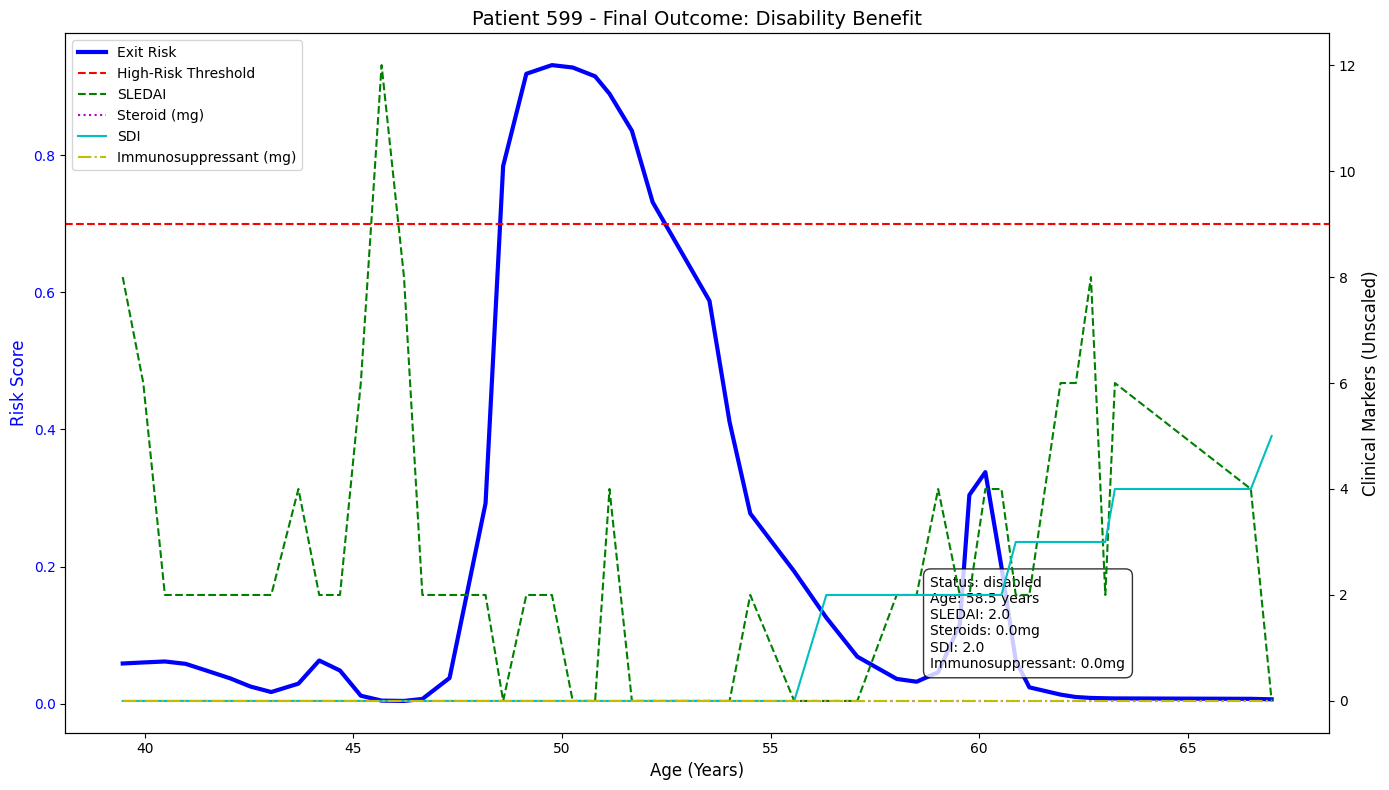

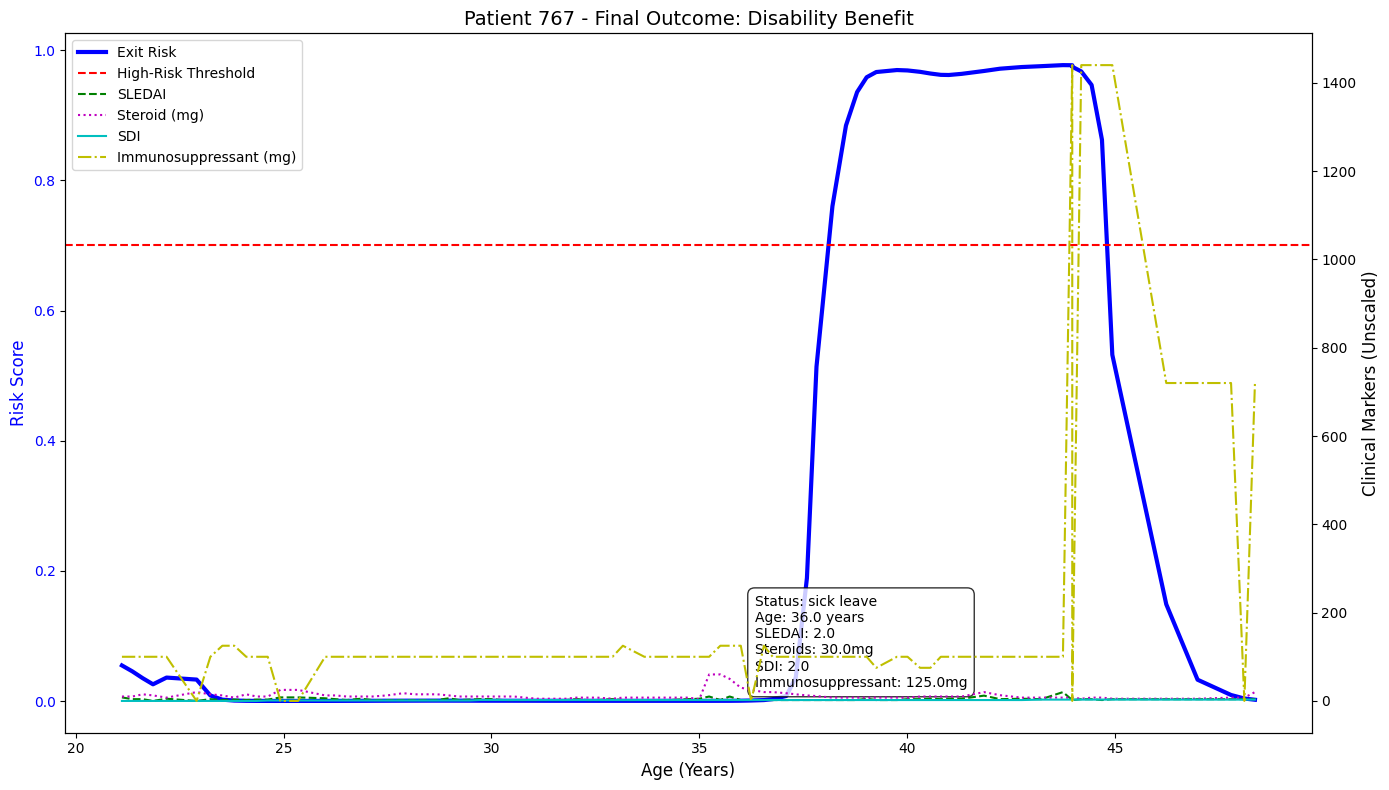

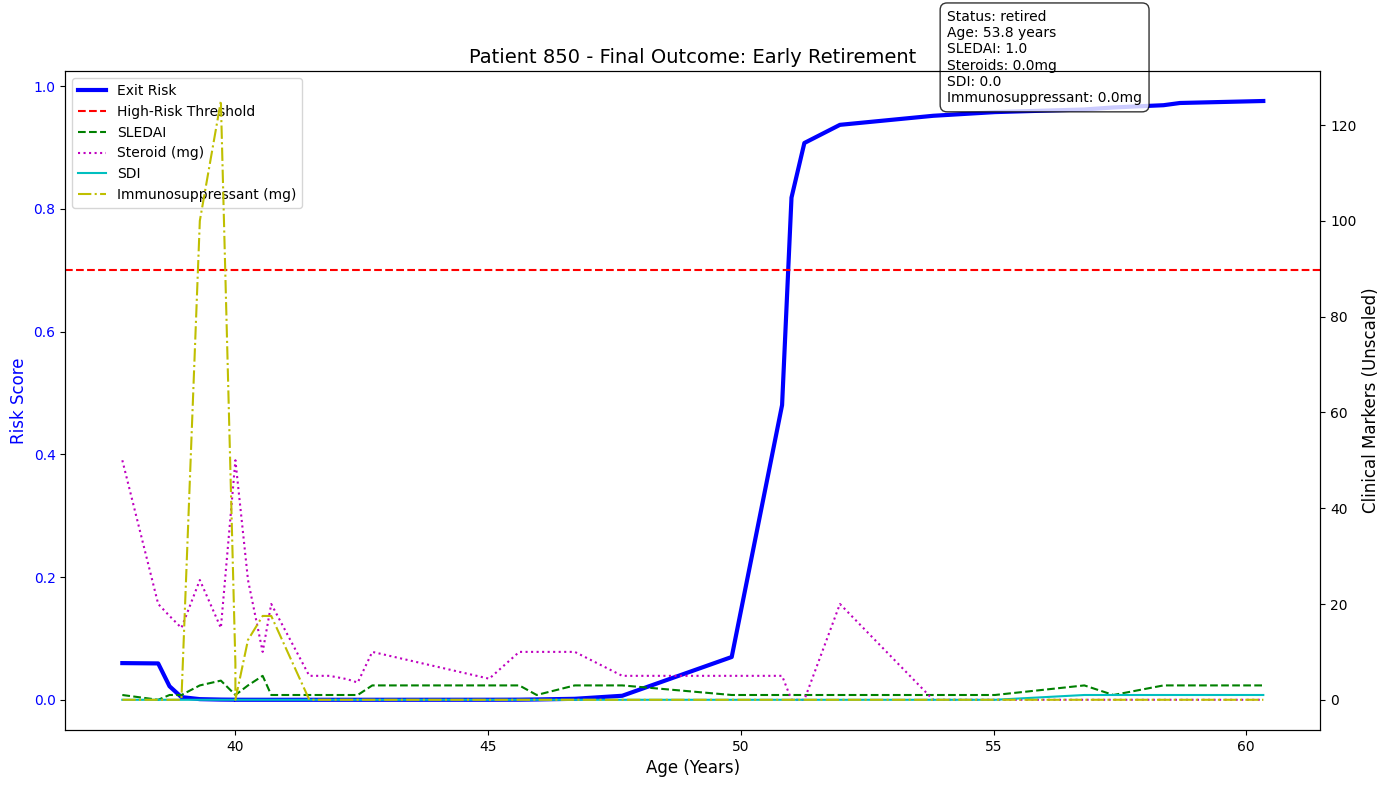

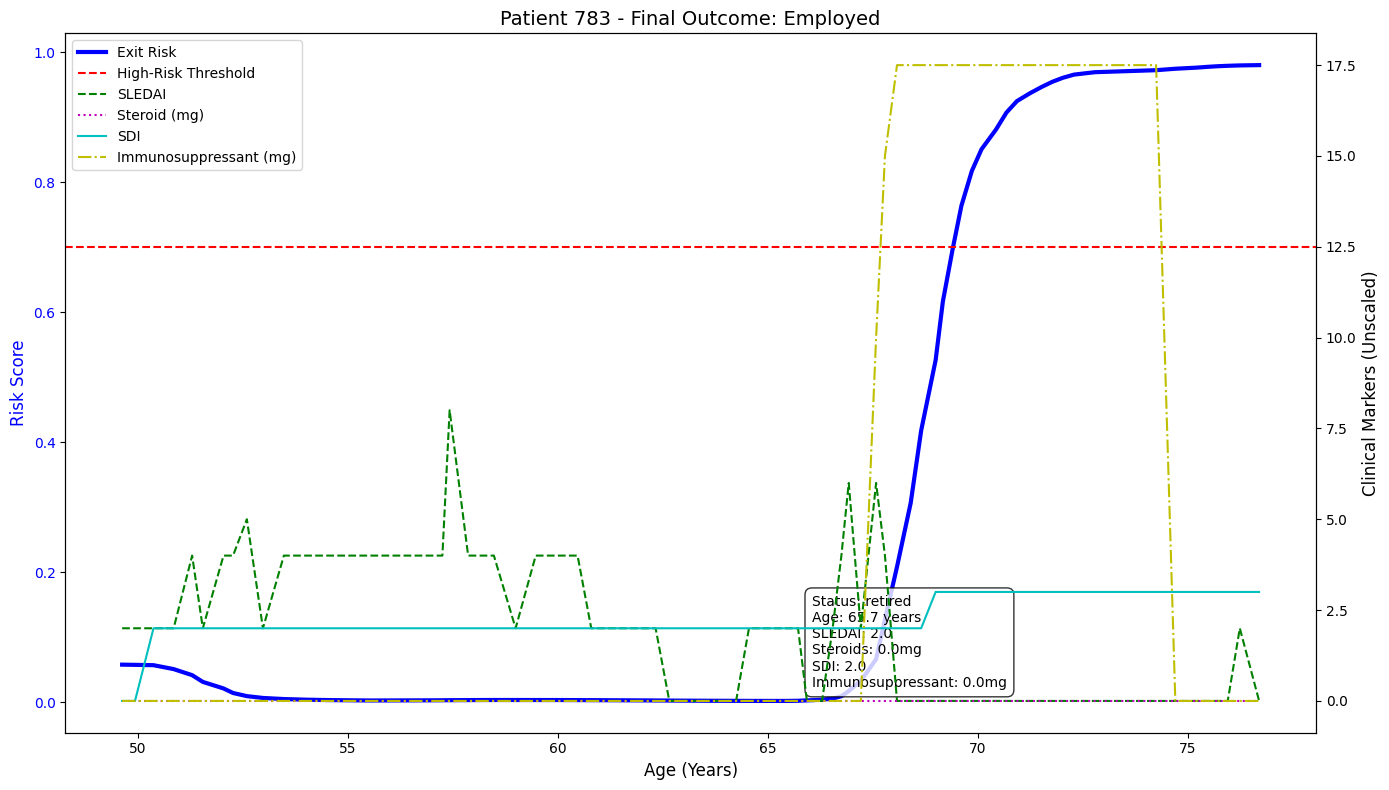

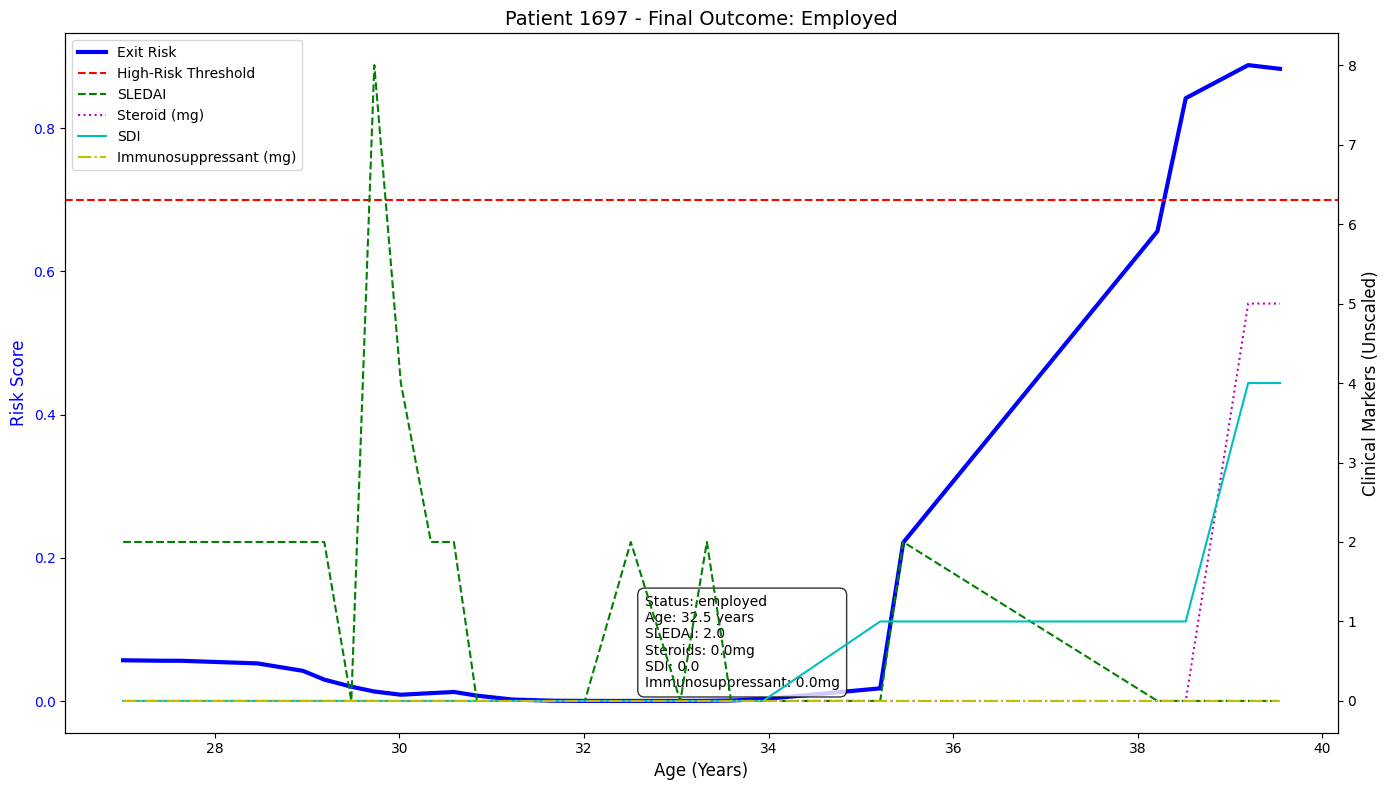

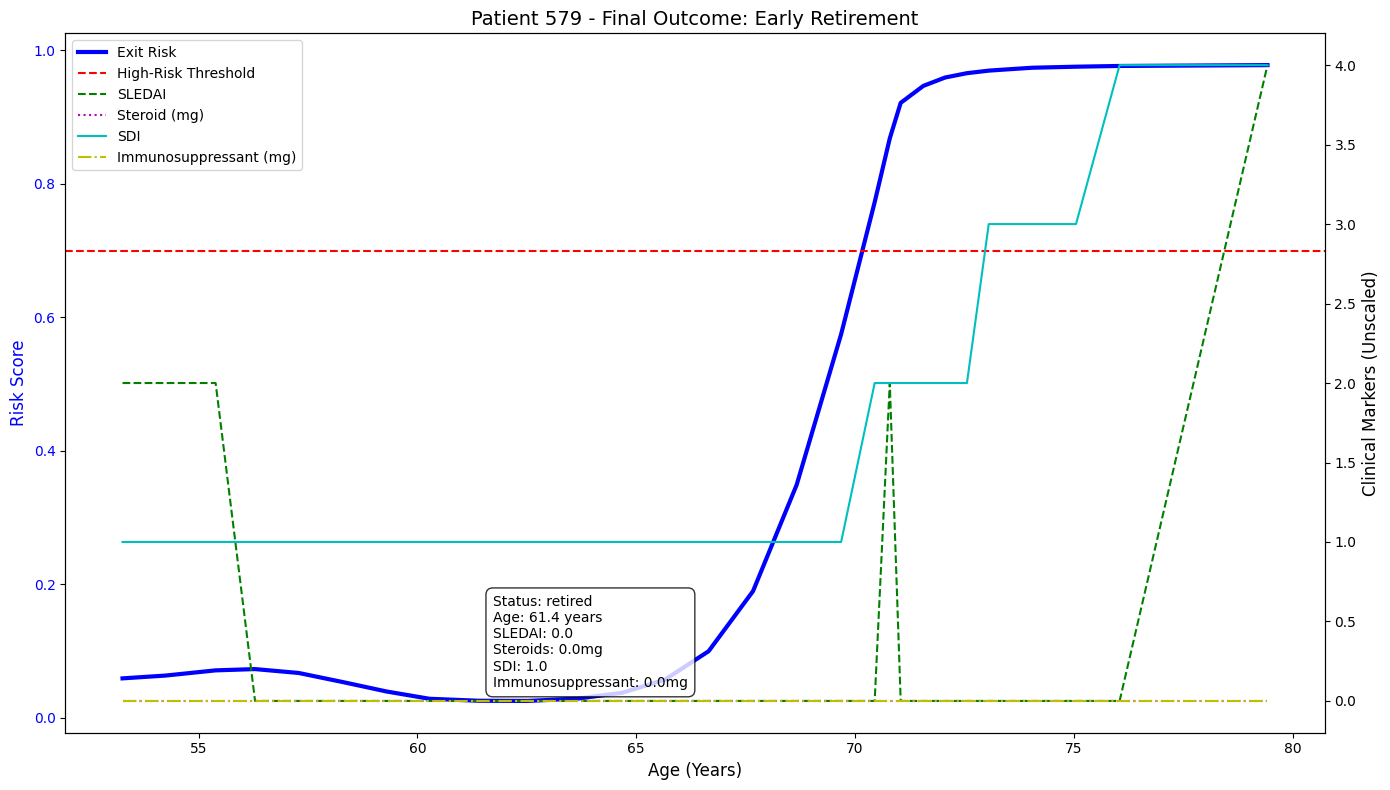

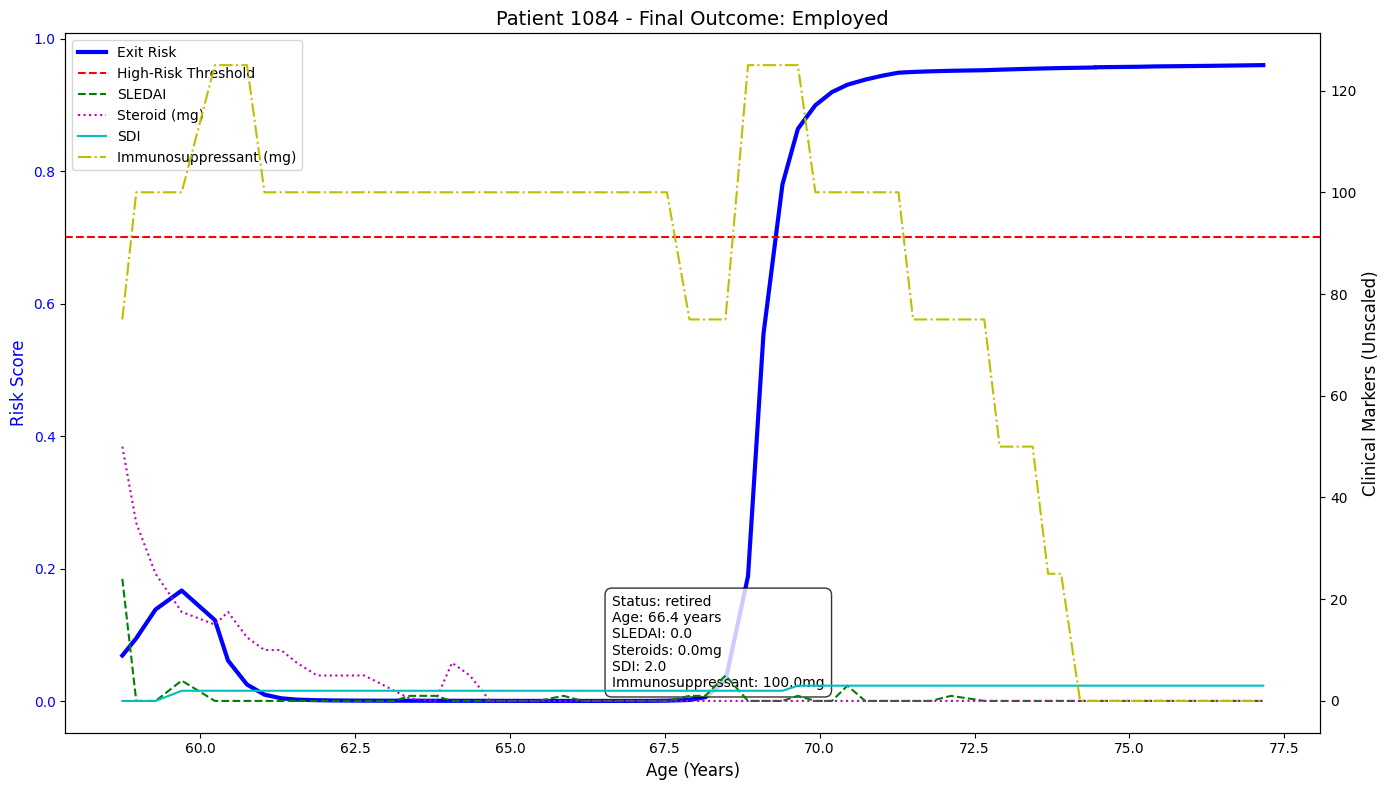

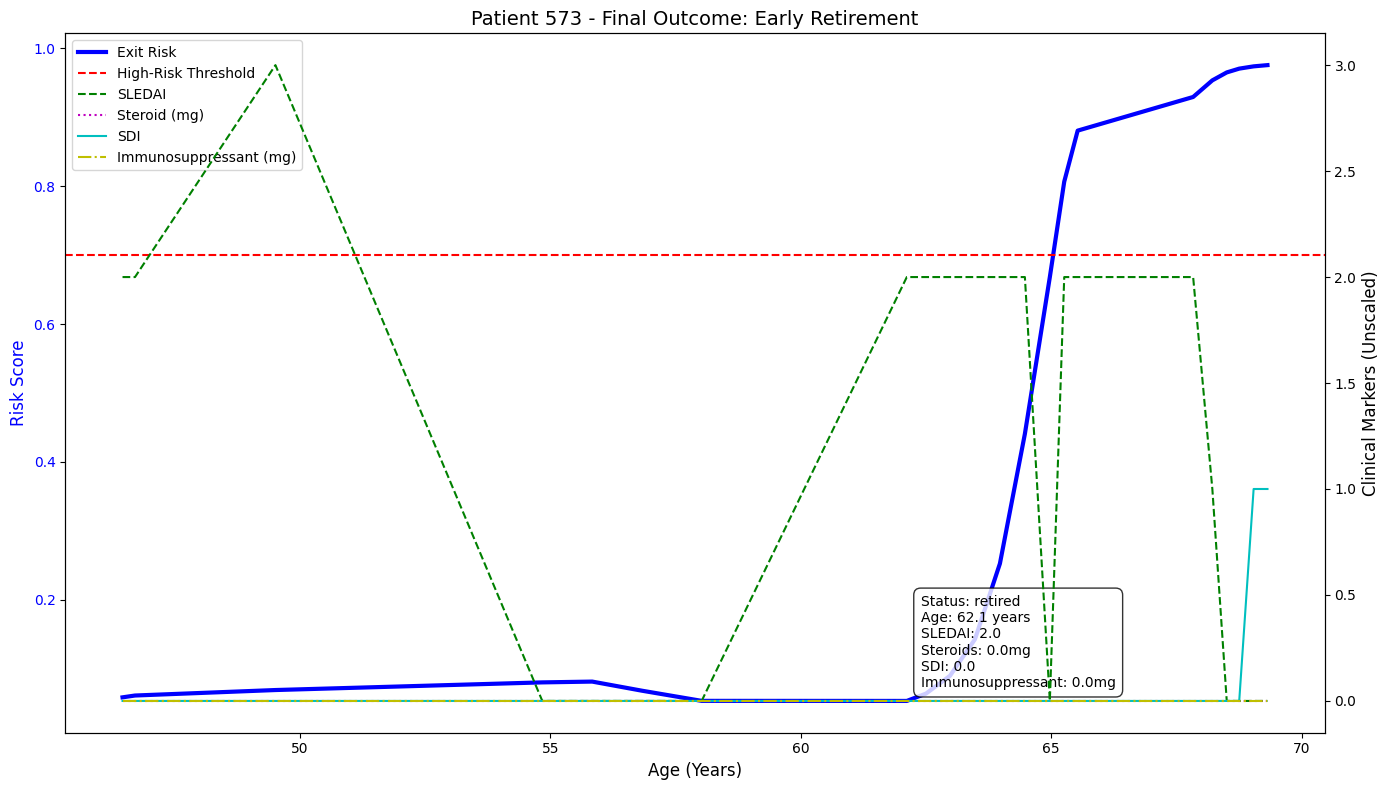

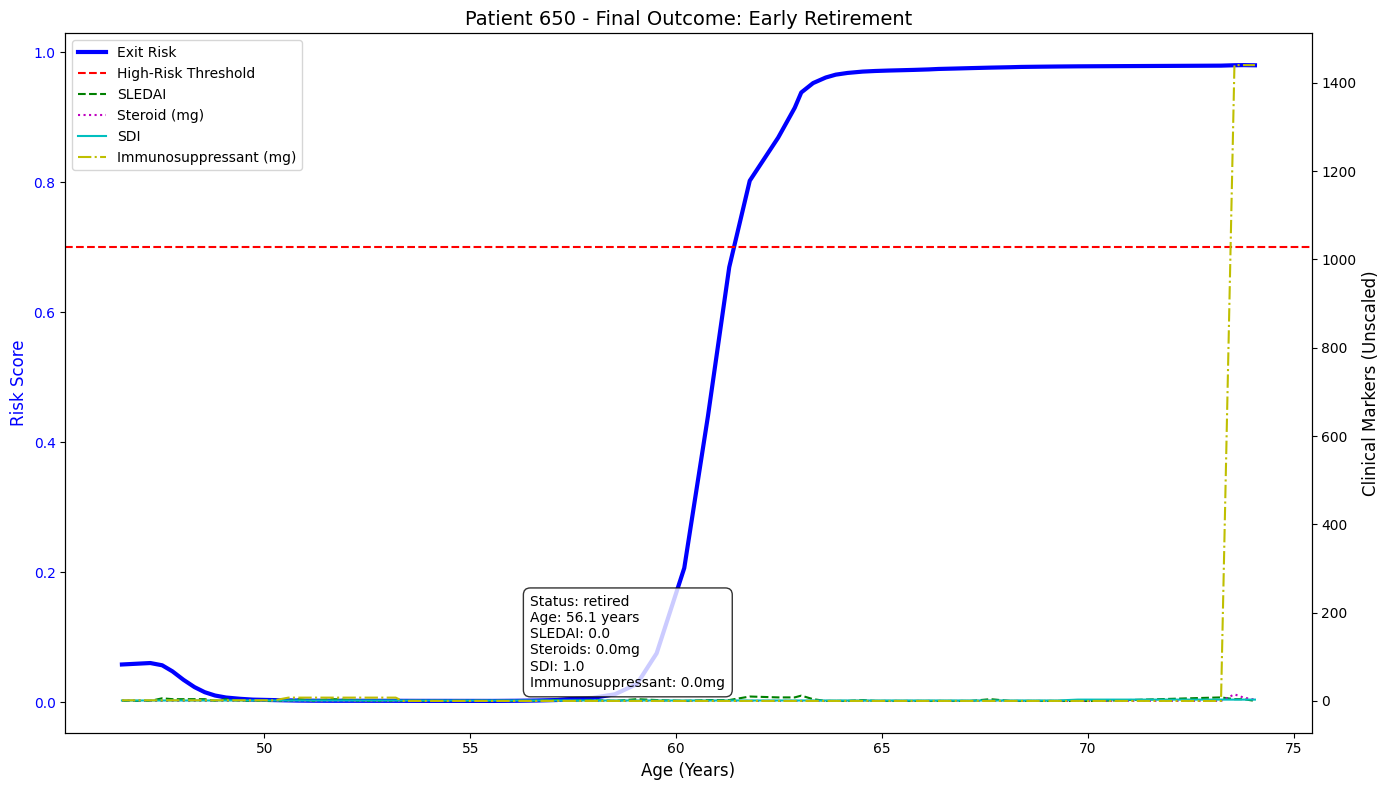

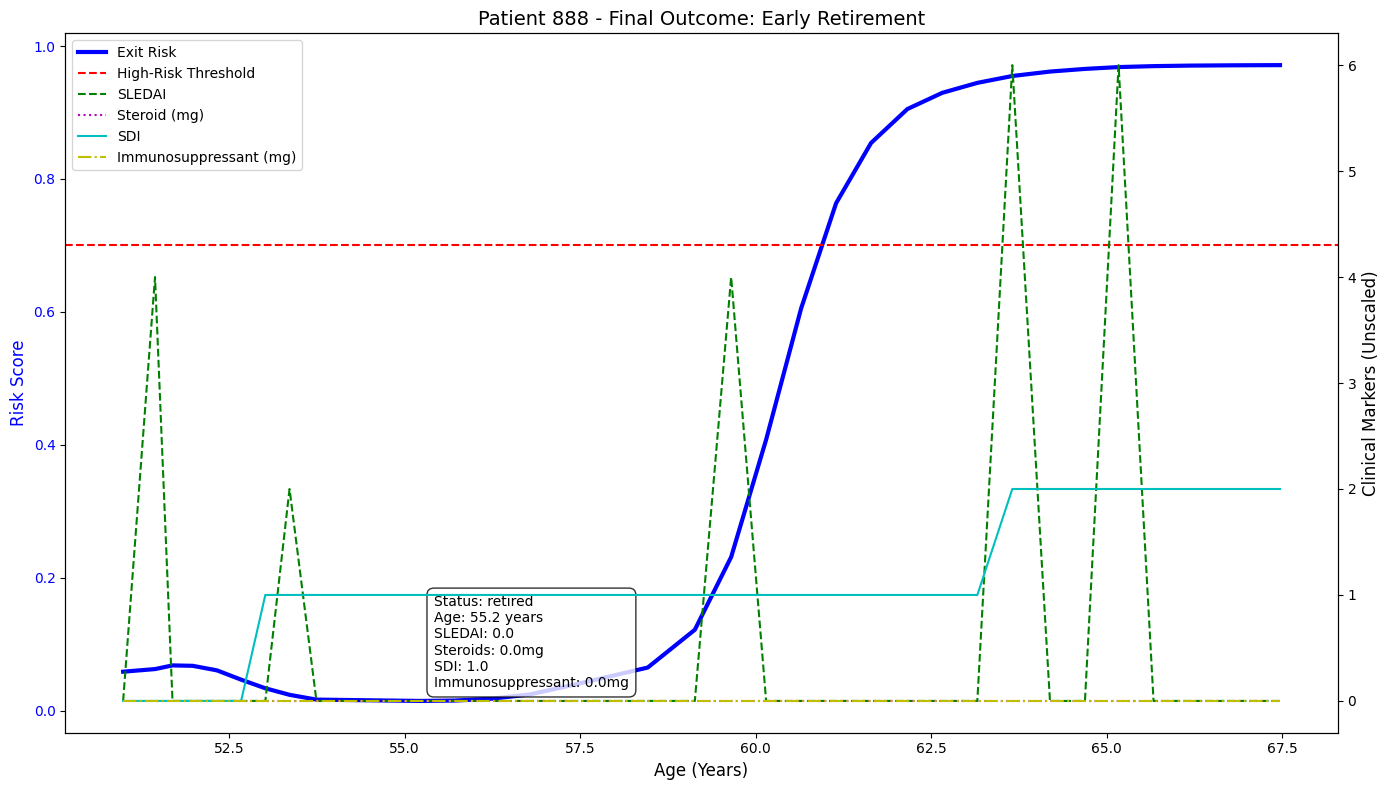

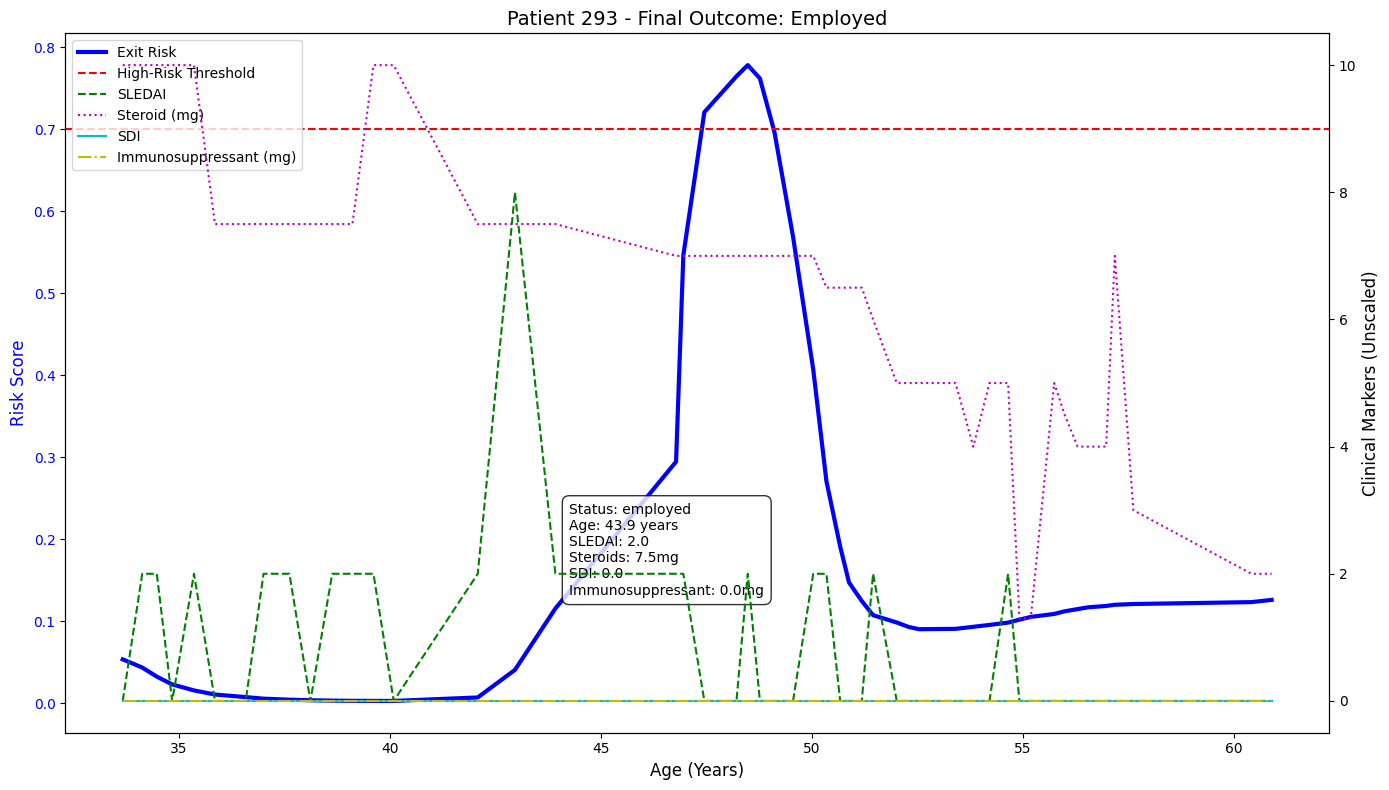

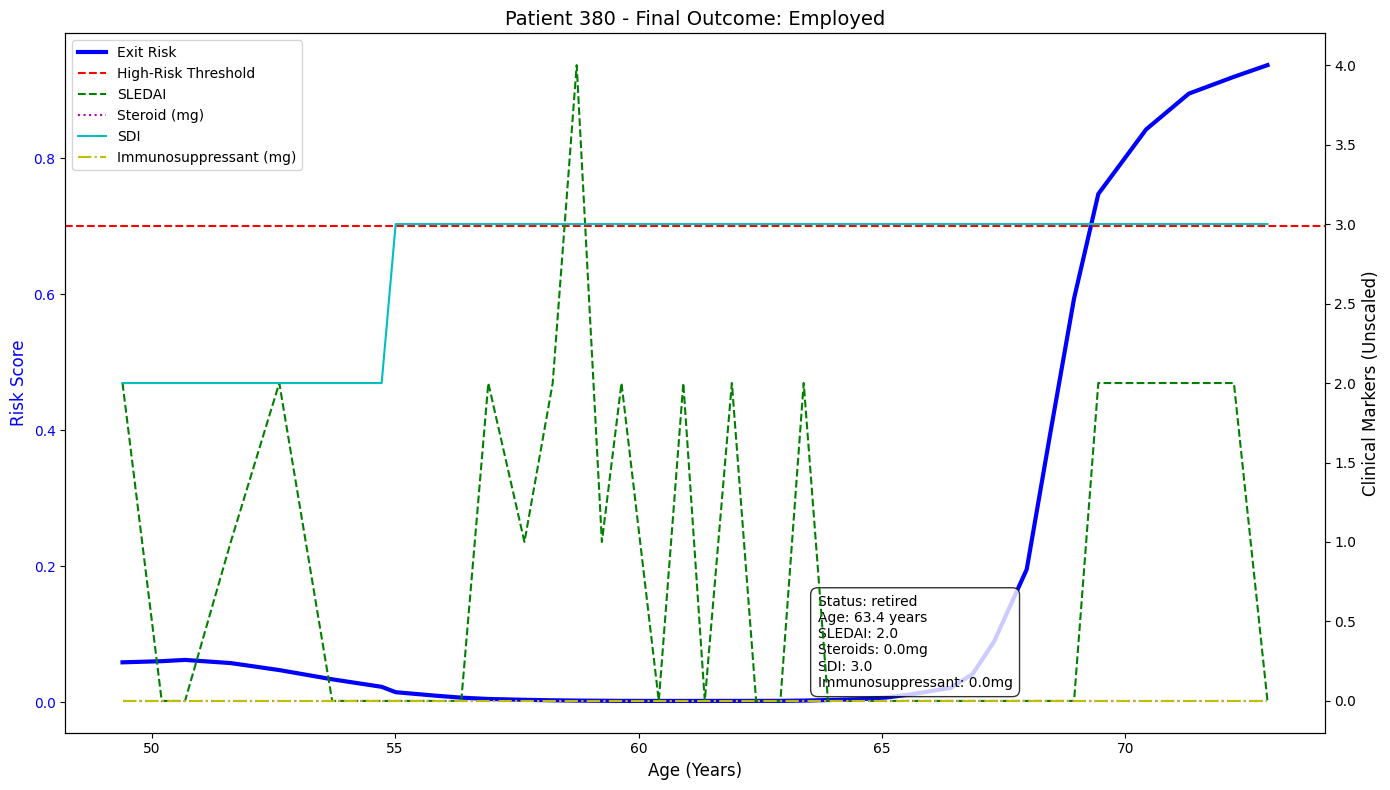

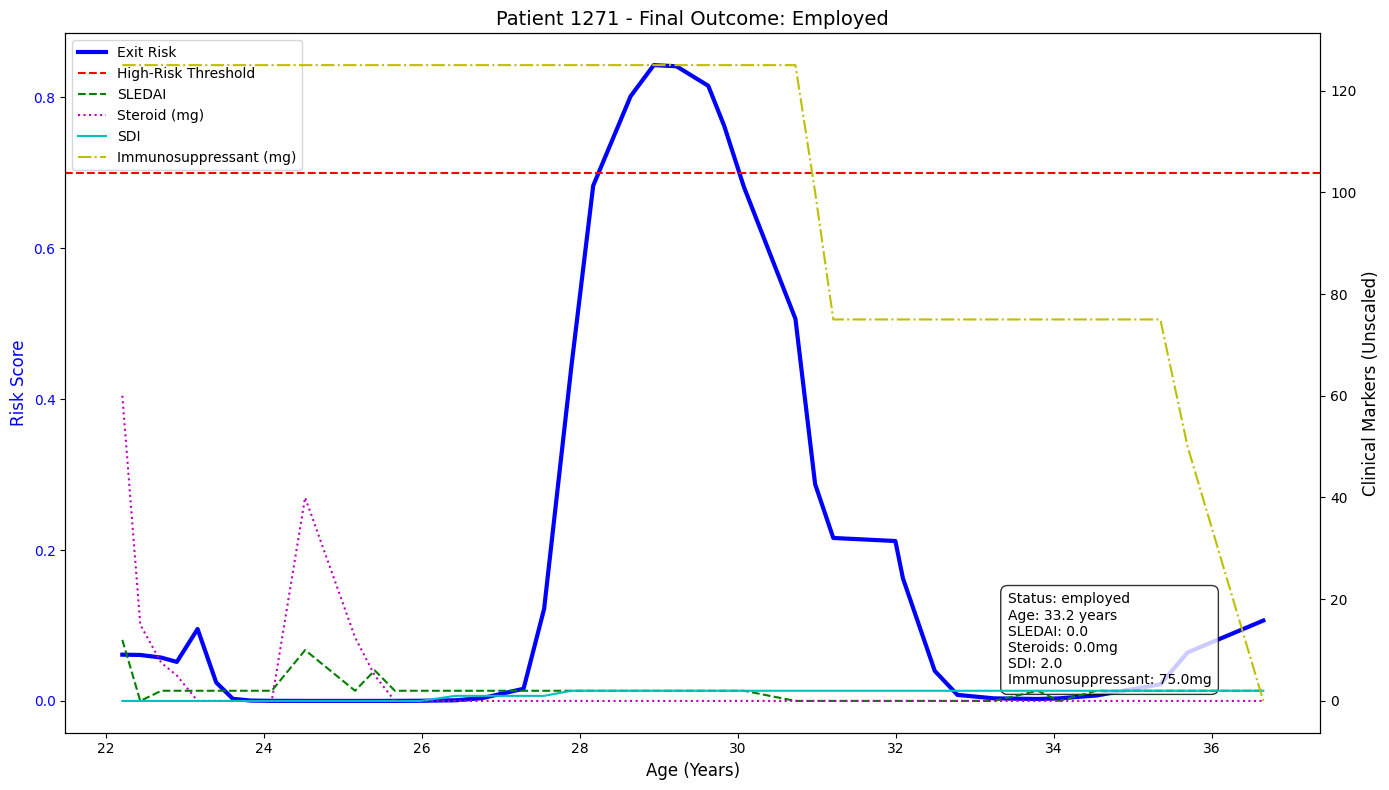

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Generate Time-to-Event Predictions (Risk Scores)
# -------------------------------------------------
def predict_risk_over_time(model, patient_data, features, max_seq_length):
    """Generate dynamic risk predictions for a patient across visits"""
    X_patient = np.zeros((1, max_seq_length, len(features)))
    seq_len = len(patient_data)
    X_patient[0, :seq_len, :] = patient_data[features].values
    
    # Get cumulative predictions at each time point
    risks = []
    for t in range(1, seq_len + 1):
        pred = model.predict(X_patient[:, :t, :], verbose=0)
        exit_risk = pred[0][1]  # Assuming class 1 is labor force exit
        risks.append(exit_risk)
    
    return pd.DataFrame({
        'ASSDT': patient_data['ASSDT'].values,
        'Risk_Score': risks,
        'SLEDAI': patient_data['SLEDAI2_I'].values,
        'Steroid_Dose': patient_data['STERDOSE'].values,
        'SDI': patient_data['score_n'].values,  # Added SDI
        'Immunosuppressant': patient_data['ISDOSE'].values,  # Added IMDOSE
        'Employment_Status': patient_data['EMPf'].values
    })

# 2. Identify High-Risk Patients with Actionable Thresholds
# --------------------------------------------------------
def get_high_risk_patients(model, data, features, risk_threshold=0.7, min_visits=3):
    """Find patients who crossed risk threshold with clinical context"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        if any(risk_df['Risk_Score'] >= risk_threshold):
            # Get the first date when risk crossed threshold
            first_high_risk_date = risk_df.loc[risk_df['Risk_Score'] >= risk_threshold, 'ASSDT'].min()
            
            # Get clinical context at that time
            context = patient_data[patient_data['ASSDT'] <= first_high_risk_date].iloc[-1]
            
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': first_high_risk_date,
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'SLEDAI_at_Warning': context['SLEDAI2_I'],
                'Steroid_at_Warning': context['STERDOSE'],
                'SDI_at_Warning': context['score_n'],  # Added SDI
                'Immunosuppressant_at_Warning': context['ISDOSE'],  # Added IMDOSE
                'Employment_at_Warning': context['EMPf'],
                'Months_Prior_to_Exit': (patient_data['ASSDT'].iloc[-1] - first_high_risk_date).days // 30
            })
    
    return pd.DataFrame(high_risk)

# 3. Generate Actionable Insights Report with Unscaled Values
# -------------------------------------
def generate_clinical_report(high_risk_df, scaler, features):
    """Create a clinician-friendly summary with properly unscaled values"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Print verification
    print("\n=== Unscaling Verification ===")
    print("Sample SLEDAI values:")
    print("Scaled:", high_risk_df['SLEDAI_at_Warning'].head(3).values)
    print("Unscaled:", high_risk_df['SLEDAI_unscaled'].head(3).values)
    
    # Initialize report
    report = {
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'High_Immunosuppressants': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 50])/len(high_risk_df):.0%} on high immunosuppressants (≥50mg)",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome
    for outcome in high_risk_df['Final_Outcome'].unique():
        n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
        n_total = len(data[data['end_state'] == outcome])
        report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

# 4. Enhanced Visualization with All Predictors
# Modified Visualization with Age on X-axis
# -----------------------------
def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Plot clinical markers (right axis)
    ax2 = ax1.twinx()
    ax2.plot(risk_df['Age'], risk_df['SLEDAI_unscaled'], 'g--', label='SLEDAI')
    ax2.plot(risk_df['Age'], risk_df['Steroid_unscaled'], 'm:', label='Steroid (mg)')
    ax2.plot(risk_df['Age'], risk_df['SDI_unscaled'], 'c-', label='SDI')
    ax2.plot(risk_df['Age'], risk_df['Immunosuppressant_unscaled'], 'y-.', label='Immunosuppressant (mg)')
    ax2.set_ylabel('Clinical Markers (Unscaled)', color='k', fontsize=12)
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Print patients with final state "Disability Benefit"
# -------------------
disability_patients = data[data['end_state'] == 'Disability Benefit']['PTNO'].unique()


# Execute the analysis with age on x-axis
# -------------------
# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(len(high_risk_df), len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)

## Full data

In [9]:

# Load the data
data = pd.read_csv('sledatafull.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_94097/1538626295.py:2: DtypeWarning: Columns (24,125,127,134,136,143,145,150,162) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatafull.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Train Test Split

In [10]:
random.seed(365)
# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
random.seed(365)
# Corrected model training section
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model with corrected class_weight
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # Use the computed weights
)

# Rest of your code remains the same...

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.2342 - loss: 1.7031 - val_accuracy: 0.5710 - val_loss: 1.5990
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.4821 - loss: 1.6093 - val_accuracy: 0.6120 - val_loss: 1.5110
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.3551 - loss: 1.5464 - val_accuracy: 0.3249 - val_loss: 1.4601
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.3569 - loss: 1.4800 - val_accuracy: 0.3438 - val_loss: 1.3940
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.4160 - loss: 1.1850 - val_accuracy: 0.4511 - val_loss: 1.3265
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.4060 - loss: 1.2016 - val_accuracy: 0.4448 - val_loss: 1.2906
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.4718 - loss: 1.1323 - val_accuracy: 0.5931 - val_loss: 1.2106
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.5130 - loss: 1.0751 - val_accuracy: 0

## Cross-Validation

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Masking
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import random

# Set random seeds for reproducibility
random.seed(365)
np.random.seed(365)

# Create sequences for each patient (your existing function)
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert one-hot encoded y back to integers for stratified k-fold
y_integers = np.argmax(y, axis=1)

# Initialize Stratified K-Fold cross-validator
n_splits = 5  # You can adjust this number
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results from each fold
fold_results = []
conf_matrices = []
classification_reports = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_integers)):
    print(f"\n=== Fold {fold + 1}/{n_splits} ===")
    
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Calculate class weights for this fold
    y_train_integers = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight('balanced', 
                                       classes=np.unique(y_train_integers), 
                                       y=y_train_integers)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Build LSTM model (same architecture for each fold)
    num_classes = y.shape[1]
    model = Sequential([
        Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    
    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=50,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Evaluate the model
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    fold_results.append(test_acc)
    
    # Predictions
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    
    # Store metrics
    conf_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))
    classification_reports.append(classification_report(
        y_true_classes, 
        y_pred_classes, 
        target_names=label_encoder.classes_
    ))
    
    print(f"Fold {fold + 1} Accuracy: {test_acc:.4f}")

# Print overall cross-validation results
print("\n=== Cross-Validation Results ===")
print(f"Average Accuracy: {np.mean(fold_results):.4f} (±{np.std(fold_results):.4f})")
print("\nIndividual Fold Accuracies:")
for i, acc in enumerate(fold_results):
    print(f"Fold {i + 1}: {acc:.4f}")

# You can also analyze the confusion matrices and classification reports
# from each fold if needed


=== Fold 1/5 ===
Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.2305 - loss: 1.6995 - val_accuracy: 0.1222 - val_loss: 1.8099
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.1750 - loss: 1.6070 - val_accuracy: 0.1556 - val_loss: 1.8460
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 343ms/step - accuracy: 0.2060 - loss: 1.6831 - val_accuracy: 0.1833 - val_loss: 1.8623
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.2984 - loss: 1.5504 - val_accuracy: 0.3222 - val_loss: 1.8121
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.4259 - loss: 1.5470 - val_accuracy: 0.4444 - val_loss: 1.5770
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.5543 - loss: 1.4498 - val_accuracy: 0.4722 - val_loss: 1.5791
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.5695 - loss: 1.2987 - val_accuracy: 0.3889 - val_loss: 1.6848
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5705 - loss: 1.3898 - val_accuracy: 0.5111 - val_

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.1994 - loss: 1.7652 - val_accuracy: 0.5722 - val_loss: 1.7397
Epoch 2/50
 3/23 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.5226 - loss: 1.1160

KeyboardInterrupt: 

In [48]:
# Calculate overall metrics
overall_accuracy = np.mean(fold_results)
std_accuracy = np.std(fold_results)

print("\n=== Final Cross-Validation Results ===")
print(f"Overall Accuracy: {overall_accuracy:.4f} (±{std_accuracy:.4f})")
print("\nDetailed Fold Accuracies:")
for i, acc in enumerate(fold_results, 1):
    print(f"Fold {i}: {acc:.4f}")


=== Final Cross-Validation Results ===
Overall Accuracy: 0.7609 (±0.0240)

Detailed Fold Accuracies:
Fold 1: 0.7500
Fold 2: 0.7500
Fold 3: 0.7278
Fold 4: 0.7833
Fold 5: 0.7933
